# Análisis Exploratorio de Datos (EDA) - Company Bankruptcy Prediction (Taiwan)

**Objetivo:** Realizar un análisis exploratorio de datos (EDA) sobre el conjunto de información financiera de empresas taiwanesas con el propósito de comprender su estructura, calidad, distribución y relaciones entre variables, y así preparar una base sólida para el desarrollo de un modelo predictivo de quiebra empresarial.

> Primero se separan los datos en `train` y `test`, y **todo el análisis exploratorio se hace únicamente sobre `train`**. El conjunto `test` se reserva y no se toca hasta la evaluación final del modelo, para evitar *data leakage* (que información del conjunto de prueba influya en decisiones tomadas antes de entrenar el modelo).


## 1. CONTEXTO

Antes de entrar en el análisis, esta sección explica el dataset y los conceptos financieros necesarios para entender el resto del notebook.

### ¿Qué es este dataset?

Los datos provienen del **Taiwan Economic Journal** (1999–2009) y contienen indicadores
financieros anuales de empresas que cotizan en la Bolsa de Taiwán. Una empresa se marca
como **"quebrada" (Bankrupt = 1)** cuando entró en proceso de bancarrota según la
normativa de esa bolsa; el resto (Bankrupt = 0) siguió operando con normalidad.

El objetivo es predecir, a partir de razones financieras (ratios), si una empresa
está en riesgo de quebrar.

### ¿Qué es un "ratio" financiero?

Es una relación entre dos cifras del estado financiero de una empresa (por ejemplo,
utilidad entre activos) que permite comparar empresas de tamaños distintos en una
misma escala. El dataset tiene 95 ratios de este tipo, todos ya calculados.


## 2. ETL (extracción, transformación y carga)

Carguemos los datos y verifiquemos su calidad.


### 2.1 Importación de librerias y configuración visual

In [2]:
# Importar librerías necesarias
import warnings
import textwrap
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import kurtosis
from IPython.display import display, HTML

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
RANDOM_STATE = 42

# -----------------------------------------------------------------------
# CONFIGURACIÓN VISUAL GLOBAL (se define UNA sola vez y se reutiliza en
# todo el notebook, en vez de repetirse en cada celda de gráficos)
# -----------------------------------------------------------------------
sns.set_theme(style='white', font='sans-serif')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Paleta de colores del proyecto
PALETTE = {
    'downriver':  '#032451',   # Azul oscuro -> Clase 0 / No quiebra / títulos
    'stone_blue': '#3D4D65',   # Ejes y texto secundario
    'poinciana':  '#CE2F25',   # Rojo -> Clase 1 / Quiebra / alertas
    'flame':      '#F94C1F',   # Acentuación (líneas KDE, etc.)
    'tangerine':  '#FE8005',   # Acento secundario
    'tagao':      '#FBBA76',   # Tono cálido de apoyo
    'bg_card':    '#FDF9F5',   # Fondo de las tarjetas de interpretación
}
TARGET_COLORS = {0: PALETTE['downriver'], 1: PALETTE['poinciana']}
TARGET_LABELS = {0: 'No quebradas (0)', 1: 'Quebradas (1)'}
CMAP_CORR = mcolors.LinearSegmentedColormap.from_list(
    'custom_diverging', [PALETTE['downriver'], '#F4F8FB', PALETTE['poinciana']]
)

# -----------------------------------------------------------------------
# FUNCIONES REUTILIZABLES (evitan repetir el mismo bloque de HTML/estilo
# de tabla en cada sección del notebook)
# -----------------------------------------------------------------------

def tarjeta_interpretacion(titulo, cuerpo_html, color_borde=None):
    """Tarjeta HTML con el estilo visual del proyecto para interpretaciones."""
    color_borde = color_borde or PALETTE['poinciana']
    display(HTML(f"""
    <div style="background-color:{PALETTE['bg_card']}; border-left:5px solid {color_borde};
                border-radius:6px; padding:14px 18px; margin:10px 0 30px 0;
                box-shadow:0 2px 8px rgba(3,36,81,0.05);
                font-family:'Segoe UI', -apple-system, BlinkMacSystemFont, Roboto, sans-serif;">
      <h4 style="color:{PALETTE['downriver']}; margin:0 0 8px 0; font-size:14px; font-weight:700;
                 text-transform:uppercase; letter-spacing:.5px;">{titulo}</h4>
      <p style="margin:0; color:{PALETTE['stone_blue']}; font-size:13.5px; line-height:1.6;">{cuerpo_html}</p>
    </div>
    """))


def tabla_estilo(df, formatos=None, titulo=None):
    """Tabla con el estilo visual del proyecto (para tablas cortas, sin scroll)."""
    if titulo:
        display(HTML(f"<h4 style='color:{PALETTE['downriver']}; font-family:Segoe UI, sans-serif; "
                      f"margin-bottom:6px;'>{titulo}</h4>"))
    styled = df.style
    if formatos:
        styled = styled.format(formatos)
    styled = styled.set_table_styles([
        {'selector': 'th', 'props': [('background-color', PALETTE['downriver']), ('color', 'white'),
                                      ('font-weight', 'bold'), ('text-align', 'left'),
                                      ('font-family', 'Segoe UI, sans-serif')]},
        {'selector': 'td', 'props': [('text-align', 'left'), ('font-family', 'Segoe UI, sans-serif')]}
    ]).hide(axis='index')
    display(styled)


def tabla_estilo_scroll(df, formatos=None, titulo=None, alto_px=420):
    """Igual que tabla_estilo, pero dentro de un contenedor con scroll vertical.
    Se usa para tablas largas (ej. las 93 variables numéricas) para que no
    'inunden' el notebook con decenas de filas seguidas."""
    if titulo:
        display(HTML(f"<h4 style='color:{PALETTE['downriver']}; font-family:Segoe UI, sans-serif; "
                      f"margin-bottom:6px;'>{titulo}</h4>"))
    styled = df.style
    if formatos:
        styled = styled.format(formatos)
    styled = styled.set_table_styles([
        {'selector': 'th', 'props': [('background-color', PALETTE['downriver']), ('color', 'white'),
                                      ('font-weight', 'bold'), ('text-align', 'left'),
                                      ('font-family', 'Segoe UI, sans-serif'),
                                      ('position', 'sticky'), ('top', '0')]},
        {'selector': 'td', 'props': [('text-align', 'left'), ('font-family', 'Segoe UI, sans-serif')]}
    ]).hide(axis='index')
    display(HTML(f"<div style='max-height:{alto_px}px; overflow-y:auto; "
                 f"border:1px solid #E1E4E9; border-radius:6px;'>{styled.to_html()}</div>"))


def grid_variables(variables, tipo, target=None, df=None, ncols=8, dpi=85):
    """Genera un panorama compacto (small multiples) de TODAS las variables
    numéricas en una sola figura, para poder revisarlas de un vistazo sin
    generar un gráfico independiente por cada una.
    tipo: 'hist' (histograma) o 'box' (boxplot vs. target)."""
    df = df if df is not None else train_df
    n = len(variables)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.3, nrows * (1.7 if tipo == 'hist' else 1.9)), dpi=dpi)
    axes = axes.flatten()

    for i, var in enumerate(variables):
        ax = axes[i]
        if tipo == 'hist':
            sns.histplot(df[var], bins=20, color=PALETTE['downriver'], edgecolor=None, ax=ax, kde=False)
        else:
            sns.boxplot(data=df, x=target, y=var, hue=target,
                        palette=[PALETTE['downriver'], PALETTE['poinciana']],
                        ax=ax, width=0.5, fliersize=1, legend=False)
        ax.set_title(textwrap.shorten(var, width=24, placeholder='…'), fontsize=6.6, color=PALETTE['downriver'])
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.tick_params(labelsize=5.3)

    for j in range(n, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
    plt.close(fig)


### 2.2 Carga del dataset

In [3]:
#df = pd.read_csv(r'data.csv')
df = pd.read_csv(r'C:\Users\laure\Documents\Company_Bankruptcy_Prediction\data\data.csv')

### 2.3 Calidad de datos 

Verifiquemos que leímos bien los datos viendo el encabezado y la cola de los datos

In [4]:
df.head()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


In [5]:
df.tail()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
6814,0,0.493687,0.539468,0.543230,0.604455,0.604462,0.998992,0.797409,0.809331,0.303510,...,0.799927,0.000466,0.623620,0.604455,0.840359,0.279606,0.027064,0.566193,1,0.029890
6815,0,0.475162,0.538269,0.524172,0.598308,0.598308,0.998992,0.797414,0.809327,0.303520,...,0.799748,0.001959,0.623931,0.598306,0.840306,0.278132,0.027009,0.566018,1,0.038284
6816,0,0.472725,0.533744,0.520638,0.610444,0.610213,0.998984,0.797401,0.809317,0.303512,...,0.797778,0.002840,0.624156,0.610441,0.840138,0.275789,0.026791,0.565158,1,0.097649
6817,0,0.506264,0.559911,0.554045,0.607850,0.607850,0.999074,0.797500,0.809399,0.303498,...,0.811808,0.002837,0.623957,0.607846,0.841084,0.277547,0.026822,0.565302,1,0.044009
6818,0,0.493053,0.570105,0.549548,0.627409,0.627409,0.998080,0.801987,0.813800,0.313415,...,0.815956,0.000707,0.626680,0.627408,0.841019,0.275114,0.026793,0.565167,1,0.233902


Veamos dimensiones, nombres de las columnas y estructura de los datos.

In [6]:
#dimensiones del dataset completo
print(f"\nDimensiones del dataset completo: {df.shape[0]} filas x {df.shape[1]} columnas")

#columnas del dataset
print("\nColumnas del dataset:")
print(df.columns.tolist())

#estructura del dataset
print("\nEstructura del dataset:")
df.info()



Dimensiones del dataset completo: 6819 filas x 96 columnas

Columnas del dataset:
['Bankrupt?', ' ROA(C) before interest and depreciation before interest', ' ROA(A) before interest and % after tax', ' ROA(B) before interest and depreciation after tax', ' Operating Gross Margin', ' Realized Sales Gross Margin', ' Operating Profit Rate', ' Pre-tax net Interest Rate', ' After-tax net Interest Rate', ' Non-industry income and expenditure/revenue', ' Continuous interest rate (after tax)', ' Operating Expense Rate', ' Research and development expense rate', ' Cash flow rate', ' Interest-bearing debt interest rate', ' Tax rate (A)', ' Net Value Per Share (B)', ' Net Value Per Share (A)', ' Net Value Per Share (C)', ' Persistent EPS in the Last Four Seasons', ' Cash Flow Per Share', ' Revenue Per Share (Yuan ¥)', ' Operating Profit Per Share (Yuan ¥)', ' Per Share Net profit before tax (Yuan ¥)', ' Realized Sales Gross Profit Growth Rate', ' Operating Profit Growth Rate', ' After-tax Net Prof

Ver valores faltantes.

In [7]:
print(df.isnull().sum())


Bankrupt?                                                   0
 ROA(C) before interest and depreciation before interest    0
 ROA(A) before interest and % after tax                     0
 ROA(B) before interest and depreciation after tax          0
 Operating Gross Margin                                     0
                                                           ..
 Liability to Equity                                        0
 Degree of Financial Leverage (DFL)                         0
 Interest Coverage Ratio (Interest expense to EBIT)         0
 Net Income Flag                                            0
 Equity to Liability                                        0
Length: 96, dtype: int64


Limpiar nombres de variables (eliminar espacios).

In [8]:
df.columns = df.columns.str.strip()

> El dataset tiene 6.819 empresas y 96 columnas (95 ratios financieros + la variable objetivo). Casi todas las columnas son numéricas (`float64`), salvo `Bankrupt?`, `Liability-Assets Flag` y `Net Income Flag`, que están guardadas como enteros pero en realidad son variables categóricas binarias (0/1), no cantidades. Las columnas no presentan valores faltantes.


* Resumen

In [9]:
# Verificar la variable objetivo
TARGET = 'Bankrupt?'
if TARGET not in df.columns:
    posibles_target = [col for col in df.columns if 'bankrupt' in col.lower()]
    if posibles_target:
        TARGET = posibles_target[0]
        print(f"Variable objetivo detectada automáticamente: '{TARGET}'")

# Tipo de problema, target y features
print(f"Variable objetivo: '{TARGET}'")
print(f"Valores únicos del target: {sorted(df[TARGET].unique())}")


# Variables categóricas: por diccionario de datos son flags binarios, aunque estén como int64
cat_vars = ['Liability-Assets Flag', 'Net Income Flag']
num_vars = [c for c in df.columns if c not in cat_vars + [TARGET]]

print(f"\nVariables predictoras numéricas: {len(num_vars)}")
print(f"Variables predictoras categóricas (flags 0/1): {len(cat_vars)} -> {cat_vars}")

# Variables clave para el "deep dive": con 93 variables numéricas no es práctico
# mostrar un gráfico + interpretación completa para cada una (se vuelve un
# "desastre" de decenas de gráficos idénticos, uno detrás de otro). Por eso,
# en las secciones 4.2 y 5.1 se muestra primero un panorama compacto de las
# 93 variables (grid_variables) y luego un análisis detallado solo de estas
# 6, elegidas por representar 6 dimensiones financieras distintas y no
# redundantes entre sí: rentabilidad, valor por acción, liquidez,
# endeudamiento, eficiencia operativa y dependencia de financiamiento.
variables_key = [
    'ROA(C) before interest and depreciation before interest',  # Rentabilidad
    'Net Value Per Share (B)',                                   # Valor por acción
    'Current Ratio',                                              # Liquidez
    'Debt ratio %',                                               # Endeudamiento
    'Total Asset Turnover',                                       # Eficiencia operativa
    'Borrowing dependency',                                       # Dependencia de financiamiento
]


Variable objetivo: 'Bankrupt?'
Valores únicos del target: [0, 1]

Variables predictoras numéricas: 93
Variables predictoras categóricas (flags 0/1): 2 -> ['Liability-Assets Flag', 'Net Income Flag']


La salida de esta celda indica claramente que se trata de un problema de clasificación, donde `Bankrupt?` es la variable objetivo, con 93 variables numéricas y 2 categóricas.


## 3. DIVISIÓN TRAIN / TEST

Antes de explorar los datos a fondo, separamos un conjunto de prueba (`test`) que se
reserva para la evaluación final del modelo. **A partir de aquí, todo el EDA se hace
usando exclusivamente `train`.** El conjunto `test` no se grafica, no se describe y no
influye en ninguna decisión de este análisis.

Como el target está muy desbalanceado (pocas empresas quebradas), usamos partición
**estratificada** (`stratify=y`) para que la proporción de empresas quebradas sea la
misma en `train` y en `test`.


In [10]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Observaciones en train: {len(X_train)} ({len(X_train)/len(df)*100:.1f}%)")
print(f"Observaciones en test:  {len(X_test)} ({len(X_test)/len(df)*100:.1f}%)")

print("\nProporción de la clase 'Quiebra' en cada conjunto (debe ser similar por la estratificación):")
print(f"  Train: {y_train.mean()*100:.2f}%")
print(f"  Test:  {y_test.mean()*100:.2f}%")

# DataFrame de trabajo para el EDA: SOLO train (predictoras + target)
train_df = X_train.copy()
train_df[TARGET] = y_train


Observaciones en train: 5455 (80.0%)
Observaciones en test:  1364 (20.0%)

Proporción de la clase 'Quiebra' en cada conjunto (debe ser similar por la estratificación):
  Train: 3.23%
  Test:  3.23%


> De aquí en adelante trabajamos solo con las 5.455 empresas de `train`. Las 1.364 de `test` quedan guardadas y no se vuelven a mirar hasta que haya un modelo entrenado. La estratificación aseguró que el porcentaje de empresas quebradas sea prácticamente igual en ambos conjuntos.


### 3.1. Revisión de `train`

#### Valores nulos

In [11]:
nulos = train_df.isnull().sum()
nulos = nulos[nulos > 0]

if len(nulos) == 0:
    print("No se encontraron valores nulos en train.")
else:
    print(f"Se encontraron {len(nulos)} columnas con valores nulos:")
    print(nulos)


No se encontraron valores nulos en train.


Ninguna empresa de `train` tiene información faltante en sus estados financieros. 

#### Filas duplicadas

In [12]:
duplicados = train_df.duplicated().sum()
print(f"Filas duplicadas en train: {duplicados}")


Filas duplicadas en train: 0


No hay filas repetidas en `train`, así que no es necesario eliminar duplicados.


#### Variables categóricas y cardinalidad

In [13]:
for c in cat_vars:
    print(train_df[c].value_counts())
    print(f"Cardinalidad: {train_df[c].nunique()} valores únicos \n")


Liability-Assets Flag
0    5450
1       5
Name: count, dtype: int64
Cardinalidad: 2 valores únicos 

Net Income Flag
1    5455
Name: count, dtype: int64
Cardinalidad: 1 valores únicos 



> `Net Income Flag` vale 1 para el 100% de las empresas en `train`, es decir, no importa si una empresa quebró o no siempre tiene el mismo valor (1). Por lo tanto, es una variable constante y sería una candidata clara para eliminar antes del modelado. `Liability-Assets Flag` sí varía, aunque muy poco. Vale la pena revisarla más adelante junto al target, en la sección de análisis bivariado.


## 4. ANÁLISIS UNIVARIADO

### 4.1 Variable objetivo 

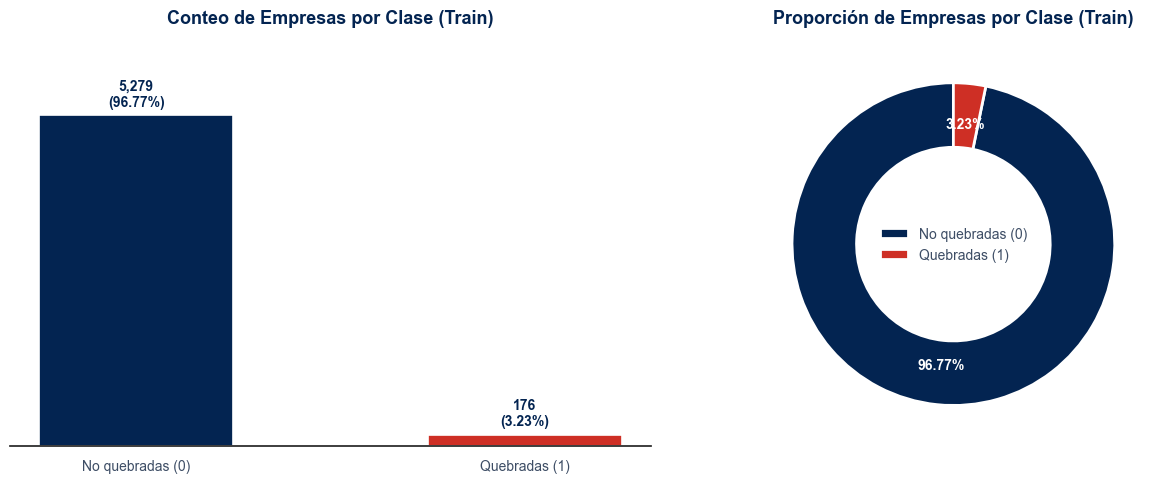

In [14]:
# 1. Cálculos de distribución
conteo = train_df[TARGET].value_counts()
porcentaje = train_df[TARGET].value_counts(normalize=True) * 100

# 2. Configuración del lienzo (2 subplots: Barras + Dona)
fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=100)
fig.patch.set_facecolor('#FFFFFF')

# --- Gráfico 1: Barras ---
bars = axes[0].bar(
    [TARGET_LABELS[0], TARGET_LABELS[1]],
    [conteo[0], conteo[1]],
    color=[TARGET_COLORS[0], TARGET_COLORS[1]],
    edgecolor='#FFFFFF',
    linewidth=1.2,
    width=0.5
)
axes[0].set_title('Conteo de Empresas por Clase (Train)', fontsize=13, fontweight='bold', color=PALETTE['downriver'], pad=14)
axes[0].set_ylim(0, max(conteo) * 1.22)
axes[0].tick_params(colors=PALETTE['stone_blue'], labelsize=10)

for bar, idx in zip(bars, conteo.index):
    altura = bar.get_height()
    axes[0].text(
        bar.get_x() + bar.get_width() / 2, altura + max(conteo) * 0.02,
        f"{conteo[idx]:,}\n({porcentaje[idx]:.2f}%)",
        ha='center', va='bottom', fontsize=10, fontweight='bold', color=PALETTE['downriver']
    )

sns.despine(ax=axes[0], top=True, right=True, left=True, bottom=False)
axes[0].tick_params(left=False, labelleft=False)

# --- Gráfico 2: Dona ---
wedges, _, autotexts = axes[1].pie(
    conteo,
    labels=None,
    autopct='%1.2f%%',
    colors=[TARGET_COLORS[i] for i in conteo.index],
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(width=0.40, edgecolor='#FFFFFF', linewidth=2),
    textprops=dict(fontsize=10, fontweight='bold', color='#FFFFFF')
)
axes[1].set_title('Proporción de Empresas por Clase (Train)', fontsize=13, fontweight='bold', color=PALETTE['downriver'], pad=14)
axes[1].legend(
    wedges, [TARGET_LABELS[i] for i in conteo.index],
    loc='center', frameon=False, fontsize=10,
    labelcolor=PALETTE['stone_blue']
)

plt.tight_layout()
plt.show()
plt.close(fig)

# 3. Ratio de desbalance, referenciado en la interpretación de la siguiente celda
ratio_desbalance = conteo[0] / conteo[1]


> **Interpretación:** La variable objetivo presenta un fuerte desbalance de clases, ya que hay **5.279** empresas que **no quiebran**, equivalentes al **96,77 %** del conjunto de entrenamiento, mientras que las que **sí quiebran** son **176** y representan el **3,23 %**. Este desbalance deberá tenerse en cuenta durante el entrenamiento y la evaluación del modelo.


### 4.2 Variables numéricas

#### Estadísticas descriptivas

In [15]:
# 1. Definición de la función para calcular las estadísticas descriptivas
def generar_estadisticas_univariadas(df, variables):
    resumen = []

    for var in variables:
        serie = df[var].dropna()
        resumen.append({
            'Variable': var,
            'N': len(serie),
            'Media': serie.mean(),
            'DS': serie.std(),
            'Curtosis': kurtosis(serie, fisher=True),  # Curtosis de Fisher (0 = normal)
            'Mediana': serie.median(),
            'Mínimo': serie.min(),
            'Máximo': serie.max(),
            'Q1': serie.quantile(0.25),
            'Q3': serie.quantile(0.75),
            'IQR': serie.quantile(0.75) - serie.quantile(0.25),
        })

    return pd.DataFrame(resumen)

# 2. Generar el resumen de las 93 variables numéricas sobre train_df
df_stats_num = generar_estadisticas_univariadas(train_df, num_vars)

# 3. Mostrar la tabla dentro de un contenedor con scroll: con 93 filas, mostrarlas
# todas "una detrás de otra" en la página no es legible. El contenedor con scroll
# mantiene las 93 disponibles para consulta sin romper el flujo del notebook.
tabla_estilo_scroll(df_stats_num, formatos={
    'N': '{:,.0f}',
    'Media': '{:.2f}',
    'DS': '{:.2f}',
    'Curtosis': '{:.2f}',
    'Mediana': '{:.2f}',
    'Mínimo': '{:.2f}',
    'Máximo': '{:.2f}',
    'Q1': '{:.2f}',
    'Q3': '{:.2f}',
    'IQR': '{:.2f}',
}, alto_px=420)


Variable,N,Media,DS,Curtosis,Mediana,Mínimo,Máximo,Q1,Q3,IQR
ROA(C) before interest and depreciation before interest,"5,455",0.50,0.06,6.28,0.50,0.02,1.00,0.48,0.53,0.06
ROA(A) before interest and % after tax,"5,455",0.56,0.07,8.79,0.56,0.00,1.00,0.54,0.59,0.05
ROA(B) before interest and depreciation after tax,"5,455",0.55,0.06,7.58,0.55,0.03,1.00,0.53,0.58,0.06
Operating Gross Margin,"5,455",0.61,0.02,392.94,0.61,0.00,0.67,0.60,0.61,0.01
Realized Sales Gross Margin,"5,455",0.61,0.02,394.67,0.61,0.00,0.67,0.60,0.61,0.01
Operating Profit Rate,"5,455",1.00,0.01,5400.60,1.00,0.00,1.00,1.00,1.00,0.00
Pre-tax net Interest Rate,"5,455",0.80,0.01,4310.72,0.80,0.00,1.00,0.80,0.80,0.00
After-tax net Interest Rate,"5,455",0.81,0.01,4229.35,0.81,0.08,1.00,0.81,0.81,0.00
Non-industry income and expenditure/revenue,"5,455",0.30,0.01,2741.03,0.30,0.06,1.00,0.30,0.30,0.00
Continuous interest rate (after tax),"5,455",0.78,0.01,4541.37,0.78,0.00,1.00,0.78,0.78,0.00


El análisis estadístico de las variables numéricas revela características clave sobre la estructura financiera y operativa de las empresas analizadas en el conjunto de entrenamiento (train_df, $N = 5{,}455$).

En primer lugar, la tasa de rentabilidad sobre activos **ROA(C) before interest and depreciation before interest** presenta un valor promedio de $0.5044$ ($\text{DS} = 0.0604$), con un rango entre $0.0243$ y $1.0000$. El $50\%$ de las empresas registra un ROA intermedio cercano a la mediana de $0.5021$ (rango intercuartílico $\text{IQR} = 0.0585$, de $Q_1 = 0.4761$ a $Q_3 = 0.5346$). No obstante, una curtosis elevada ($\text{Curtosis} = 6.28$) evidencia la presencia de colas pesadas y valores atípicos en empresas con rentabilidades extremadamente reducidas o inusualmente altas.

Por otro lado, la variable de apalancamiento **Debt ratio %** exhibe una media de $0.1132$ ($\text{DS} = 0.0542$), situando al $50\%$ de las firmas por debajo de $0.1114$ ($\text{IQR} = 0.0761$, entre $Q_1 = 0.0729$ y $Q_3 = 0.1489$). Esta variable muestra una variabilidad pronunciada con un valor máximo de $1.0000$, lo que refleja la coexistencia de entidades con muy bajo nivel de endeudamiento junto a empresas altamente apalancadas con mayor riesgo financiero implícito.

En cuanto a la liquidez, el indicador **Current Ratio** presenta una media de $0.0151$ ($\text{DS} = 0.0232$) y una mediana de $0.0106$ ($\text{IQR} = 0.0089$, de $Q_1 = 0.0075$ a $Q_3 = 0.0164$). Su valor máximo alcanza $1.0000$, generando una curtosis excepcionalmente alta ($\text{Curtosis} \approx 814$), lo cual indica que la gran mayoría de las observaciones se concentra en niveles muy bajos de liquidez relativa, con contadas excepciones extremas en la cola superior.

Finalmente, indicadores de rotación y flujo operativo como **CFO to Assets** (flujo de caja operativo sobre activos totales) registran una media de $0.5932$ ($\text{DS} = 0.0577$), con el $50\%$ de los registros situado por debajo de $0.5933$ (rango de $Q_1 = 0.5659$ a $Q_3 = 0.6241$) y extremos que van de $0.0000$ a $1.0000$.

En conjunto, las 93 variables numéricas muestran distribuciones marcadamente asimétricas, con leptocurtosis acentuada en múltiples indicadores. Esto pone de manifiesto una marcada heterogeneidad operativa y la existencia de subgrupos o patrones financieros claramente diferenciados entre las firmas de la muestra. Las escalas son muy distintas entre variables (algunas van de 0 a 1, otras tienen valores en miles). Esto ya nos dice que, para cualquier modelo sensible a la escala (como regresión logística, SVM o PCA), va a hacer falta estandarizar las variables en el pipeline de preprocesamiento.


#### Gráficas

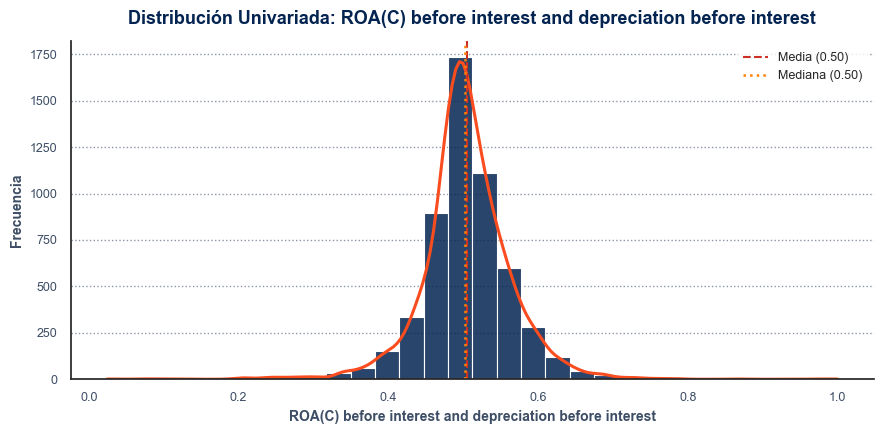

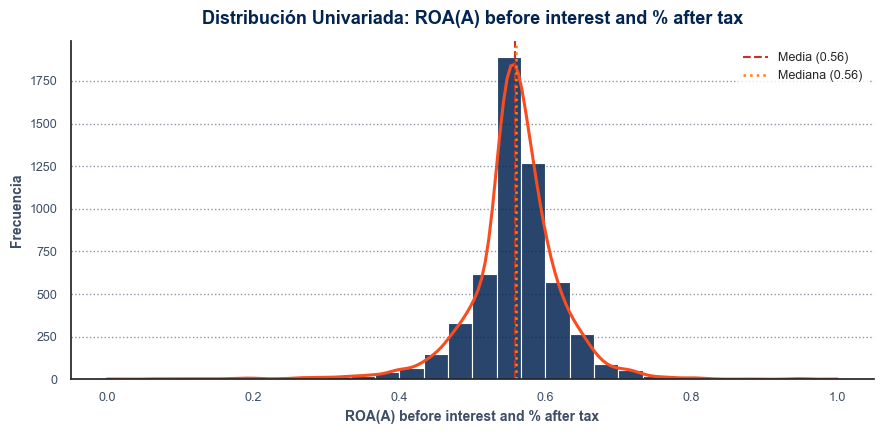

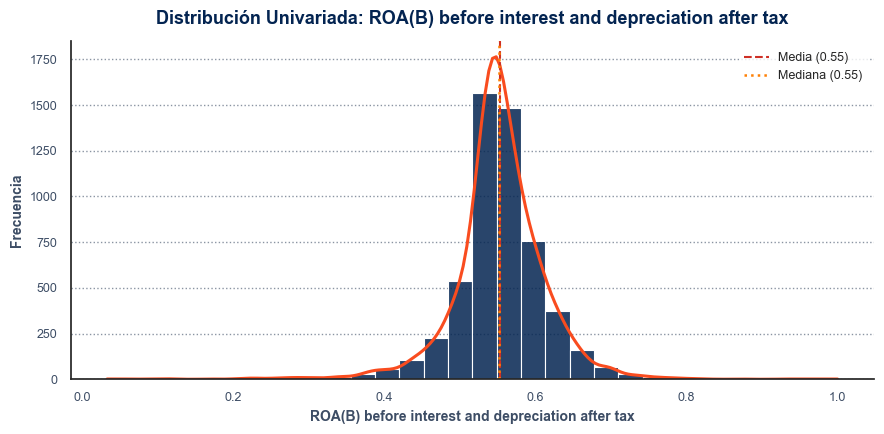

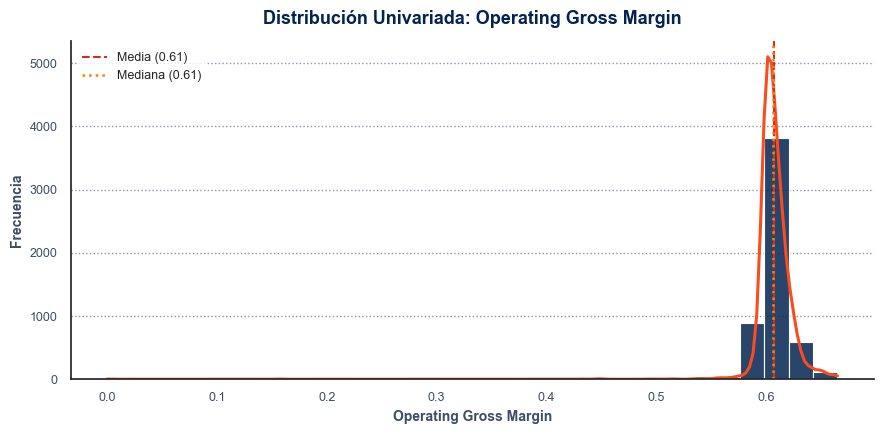

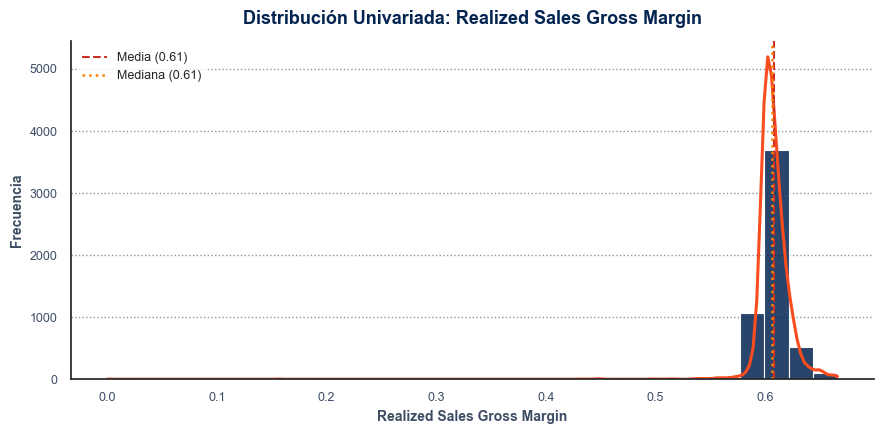

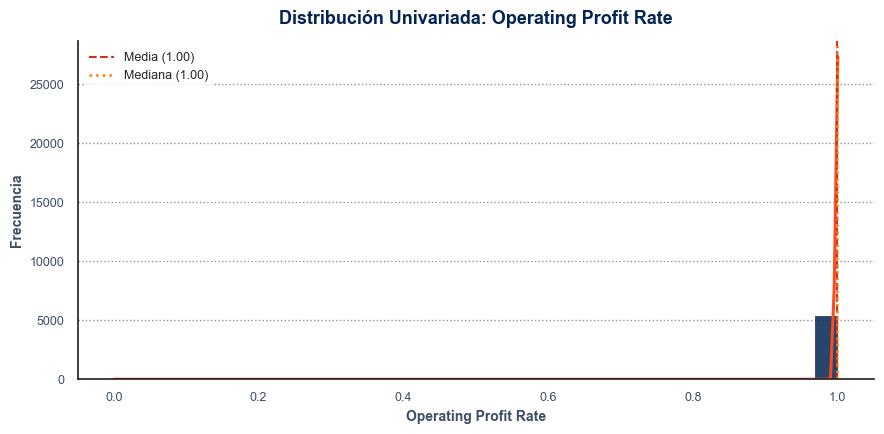

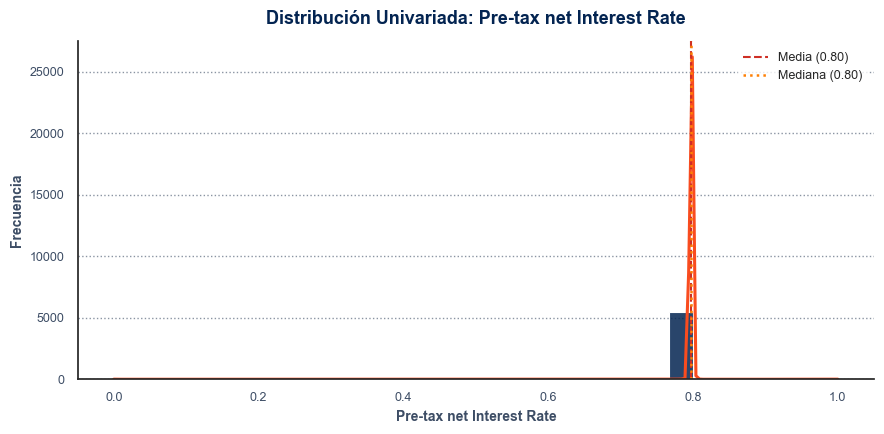

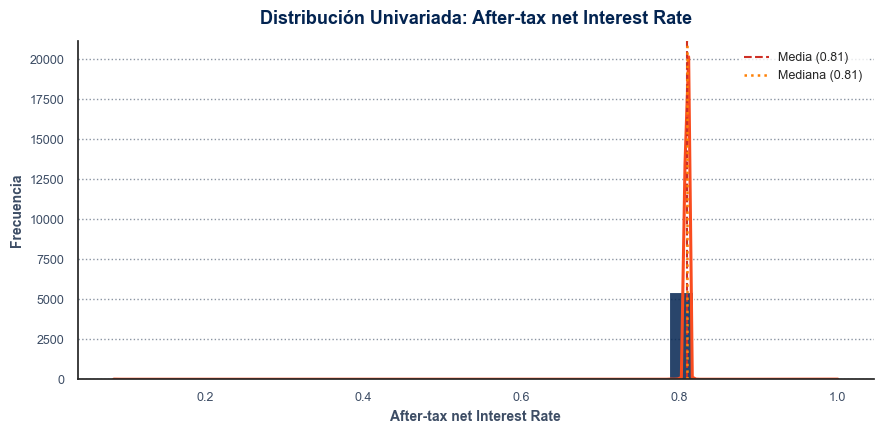

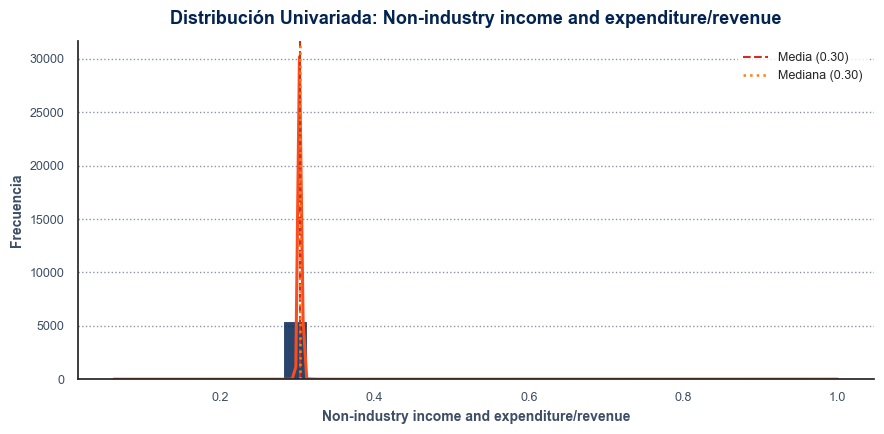

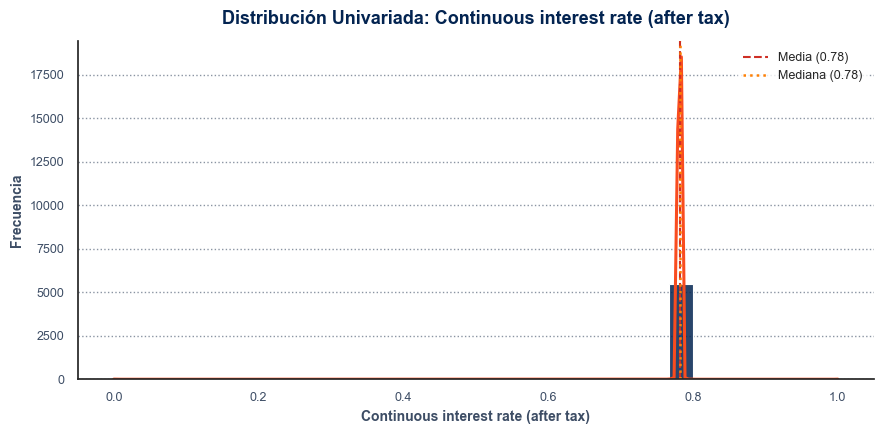

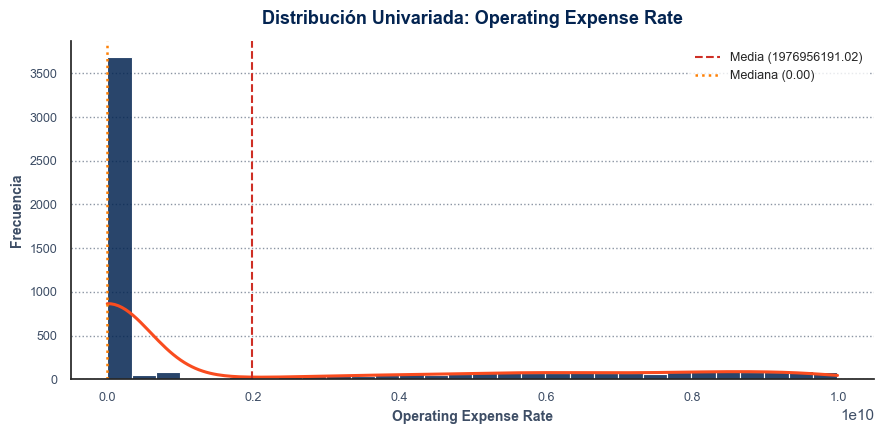

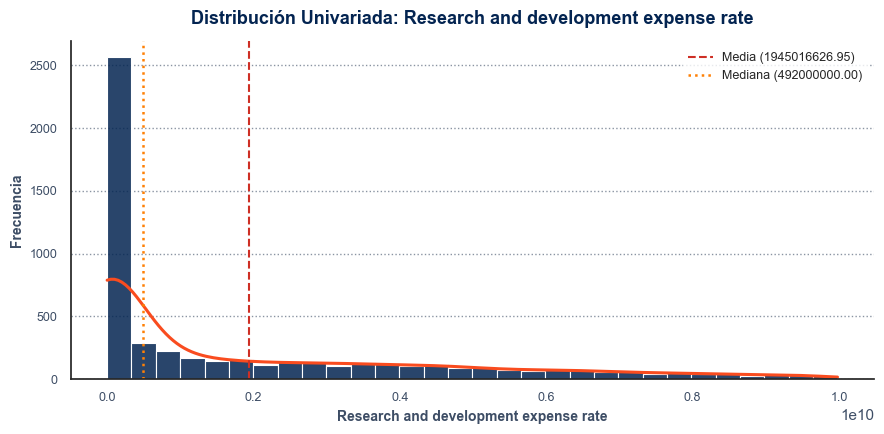

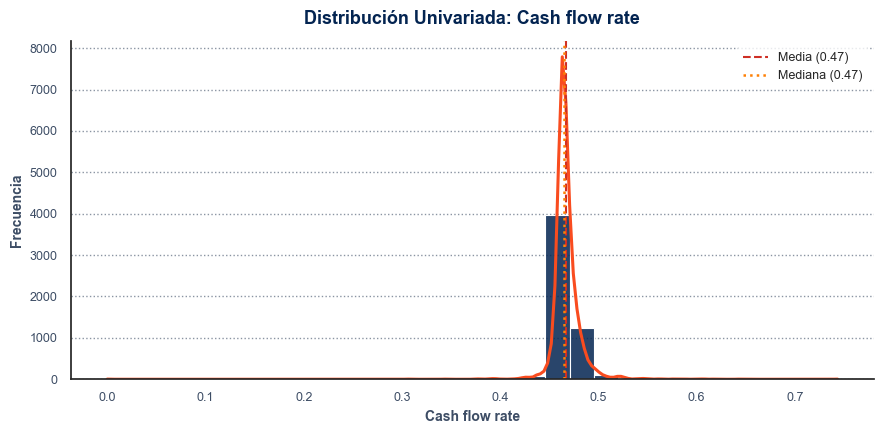

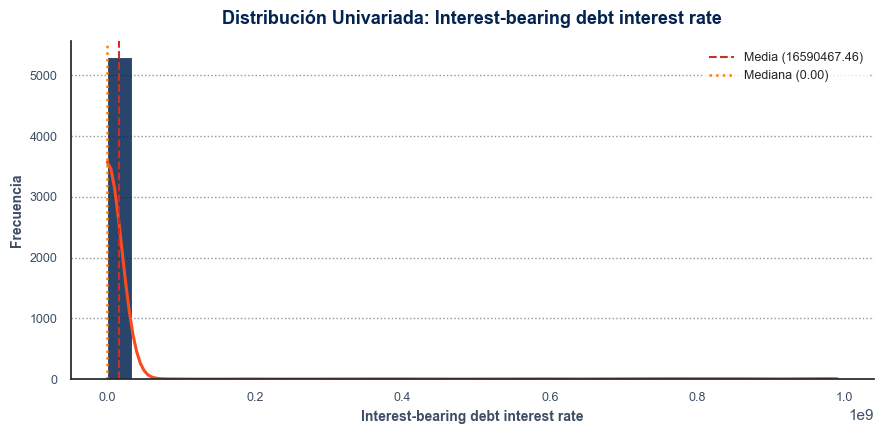

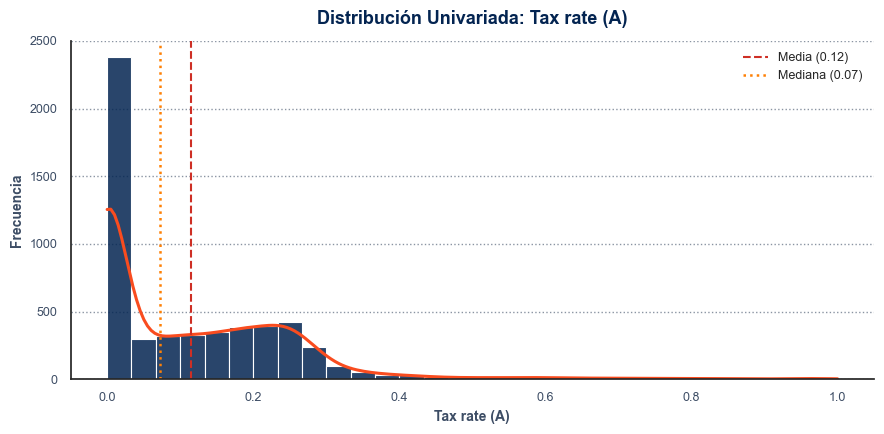

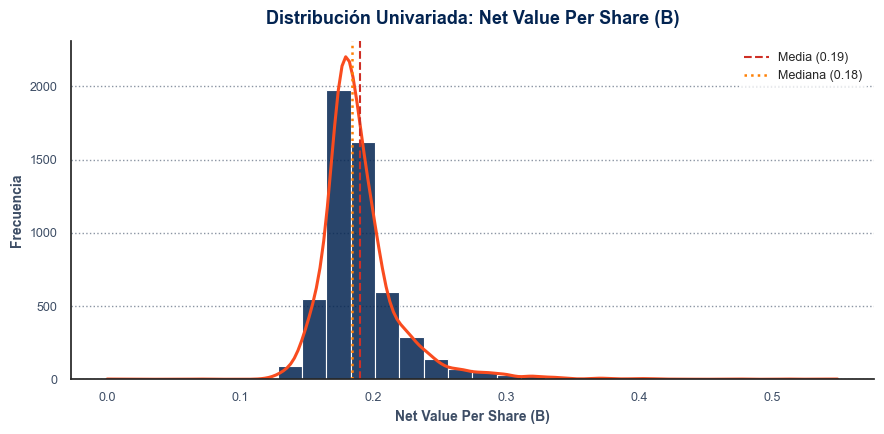

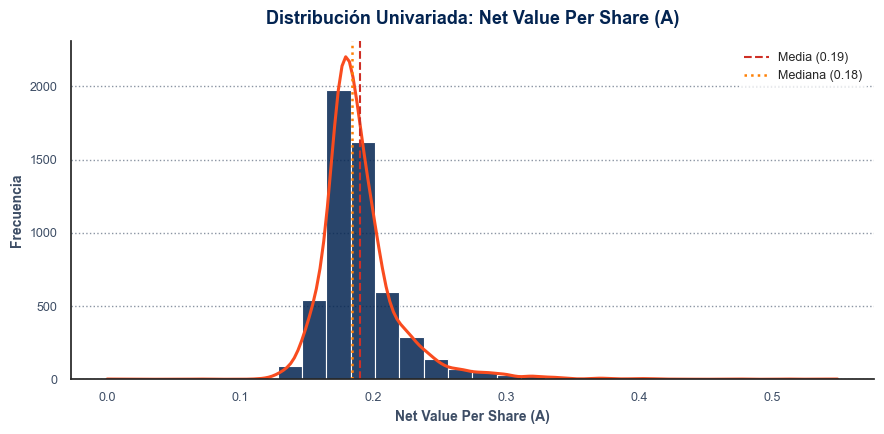

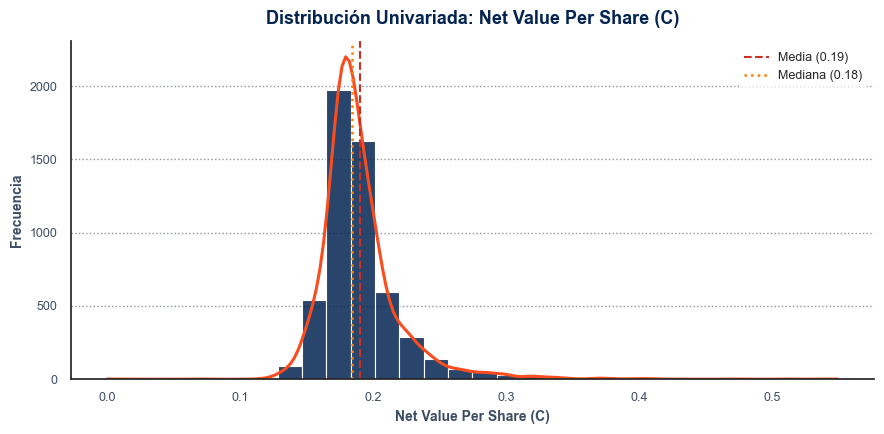

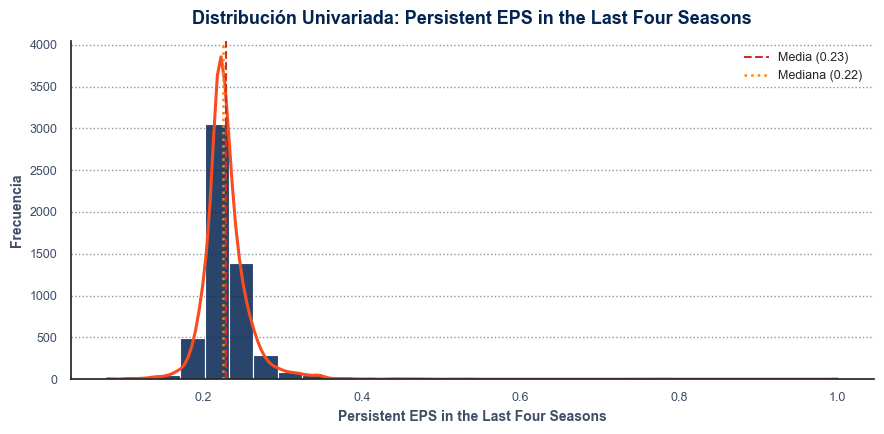

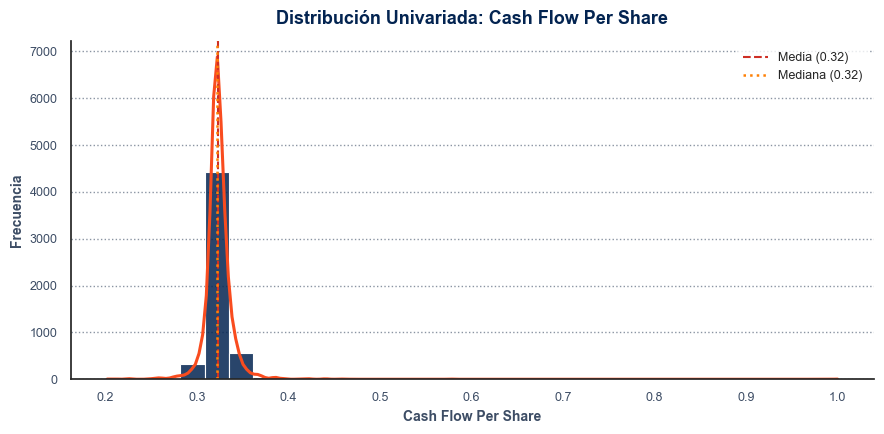

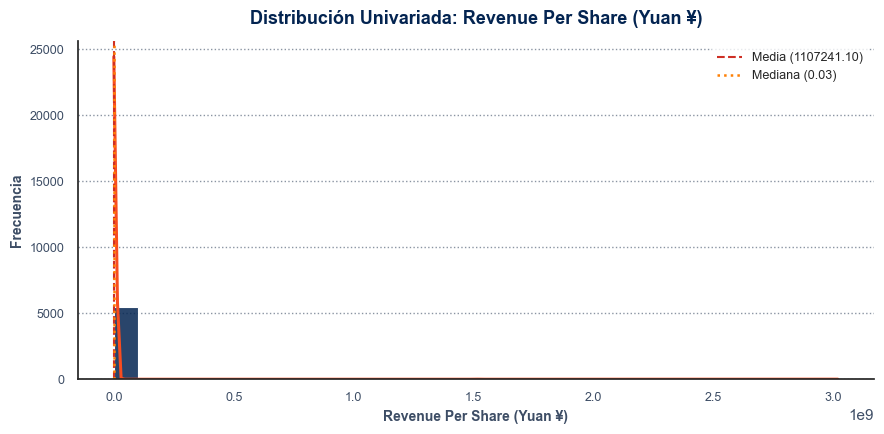

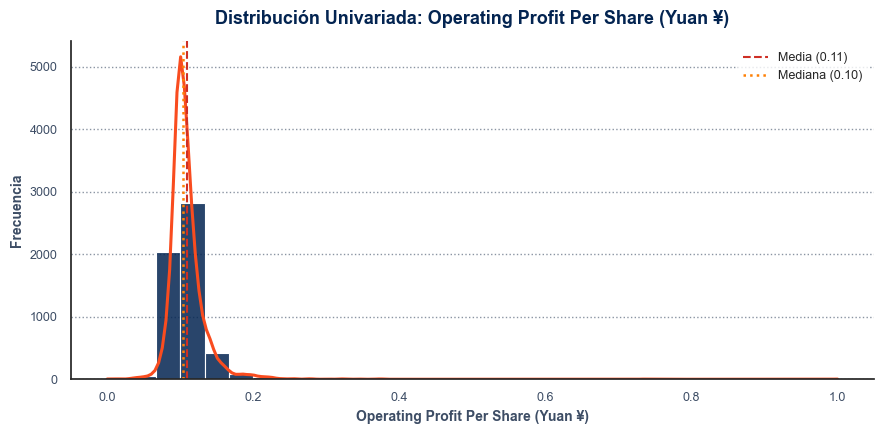

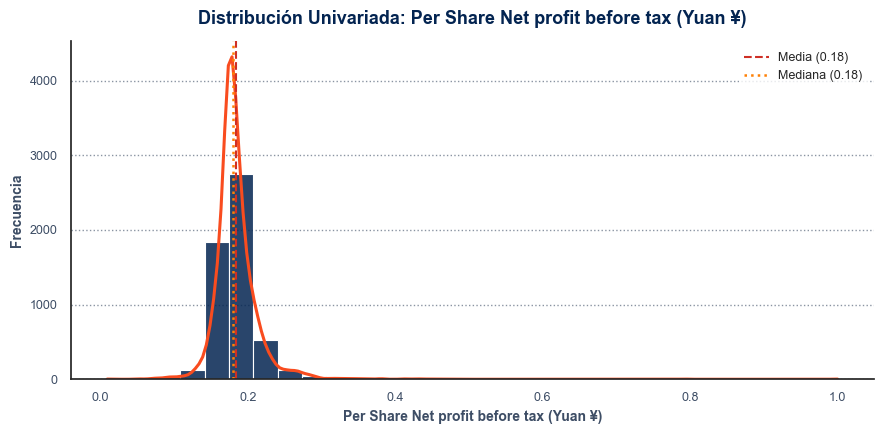

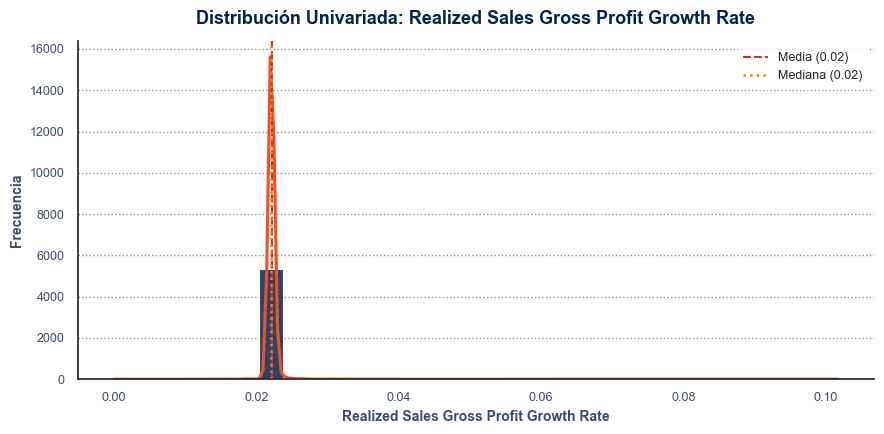

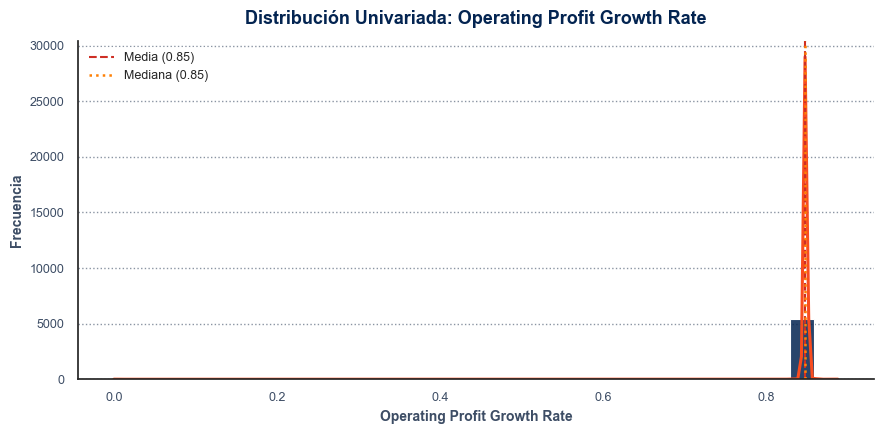

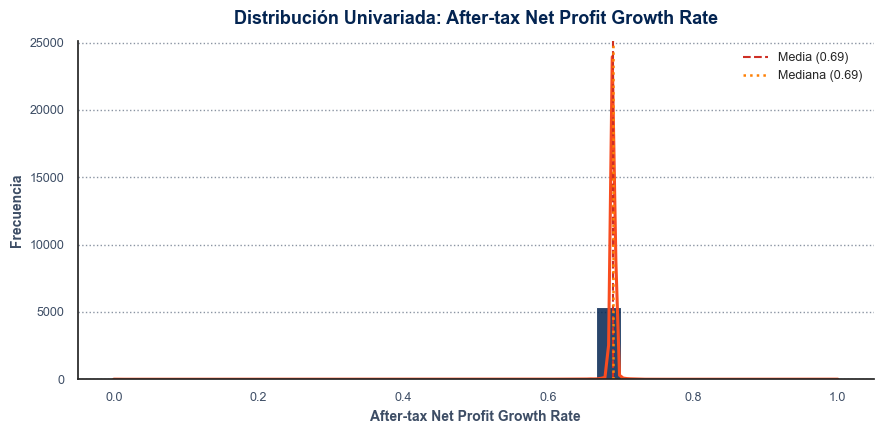

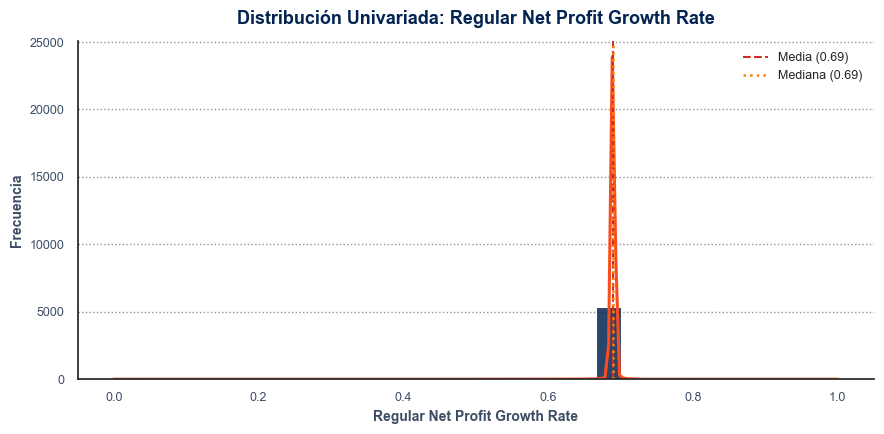

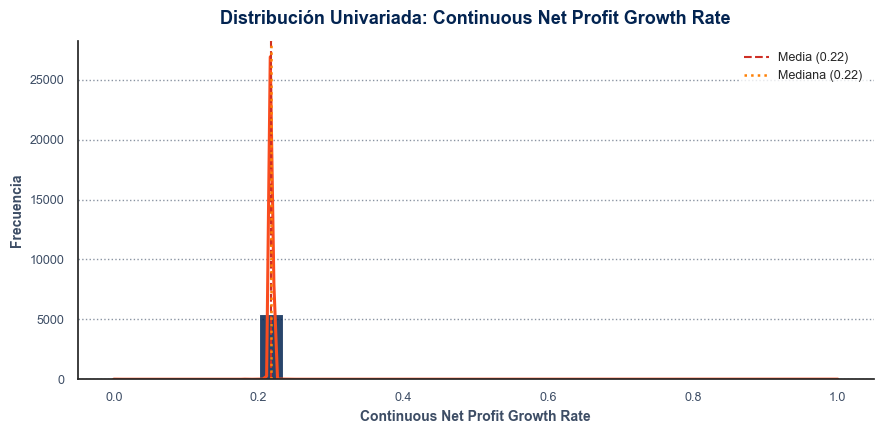

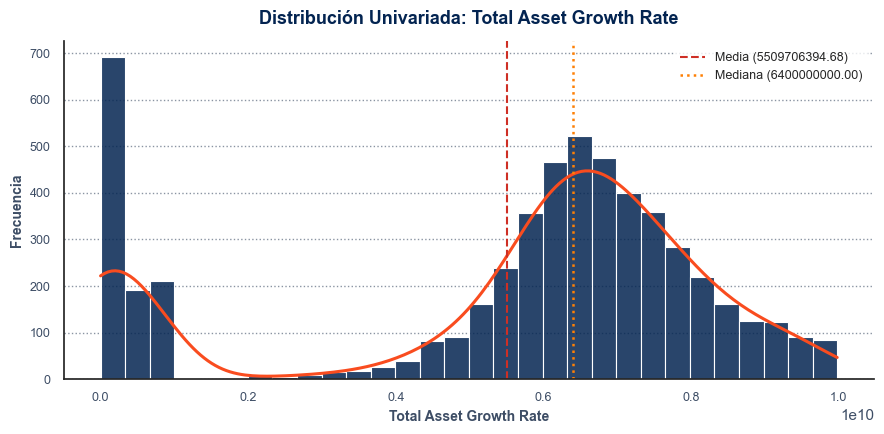

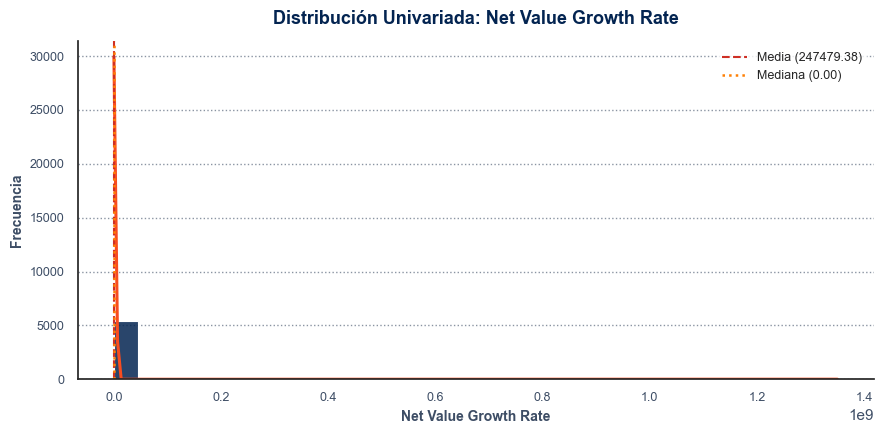

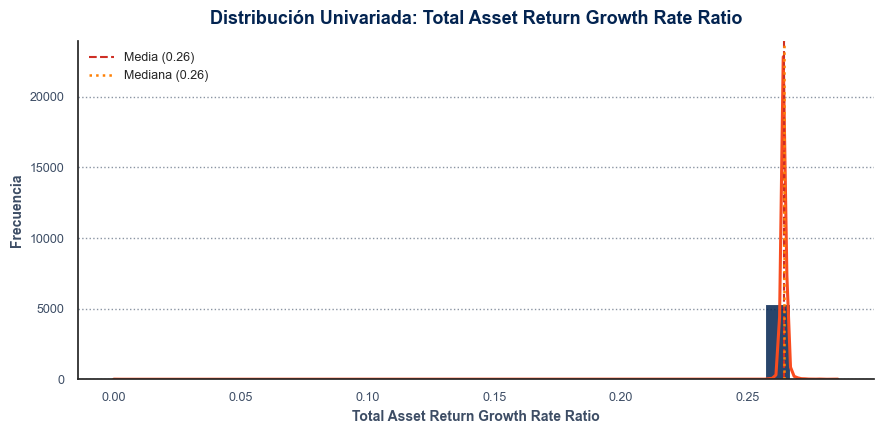

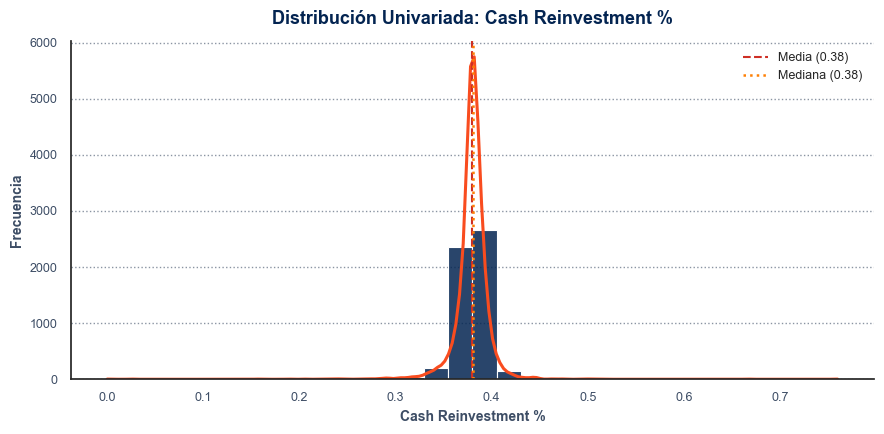

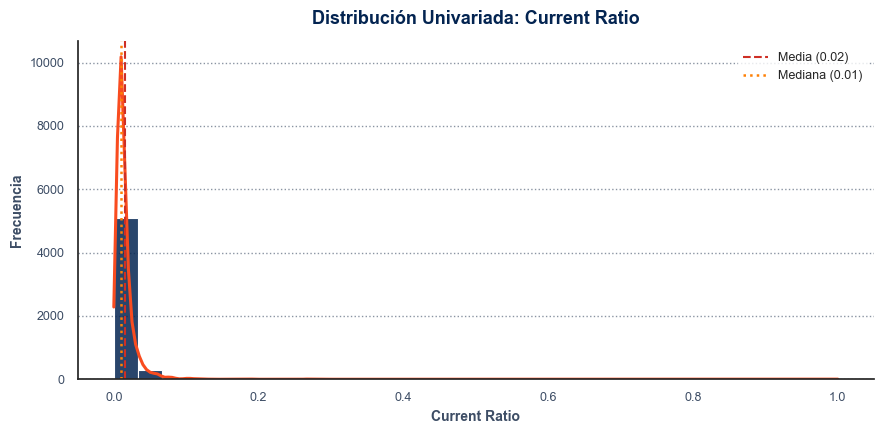

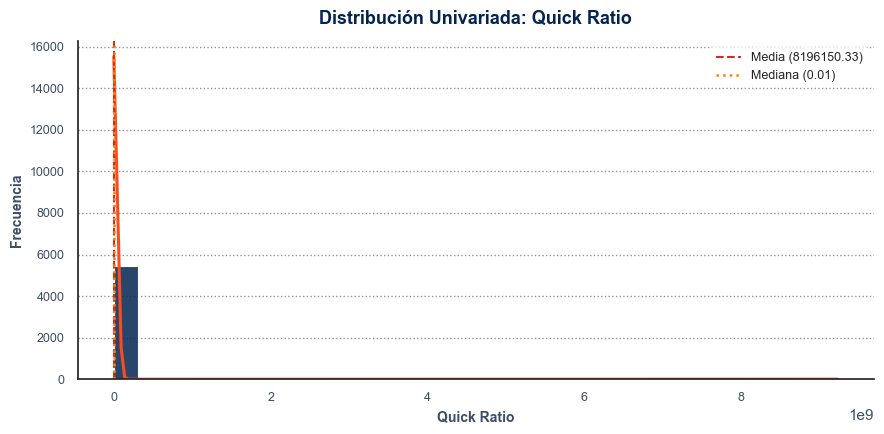

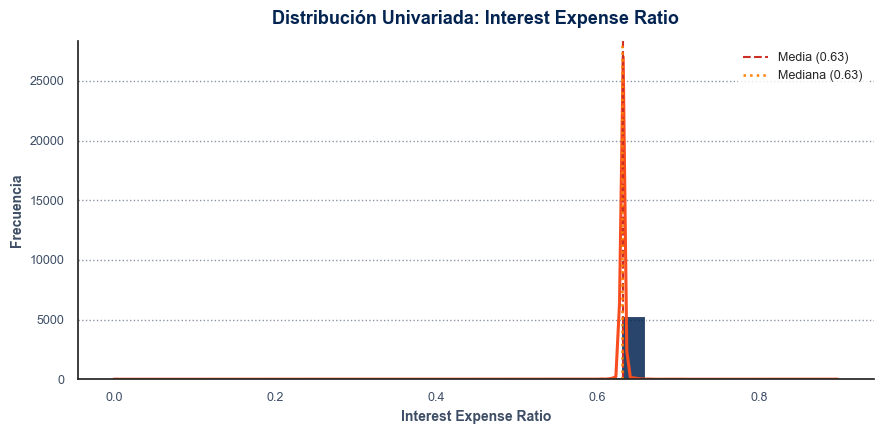

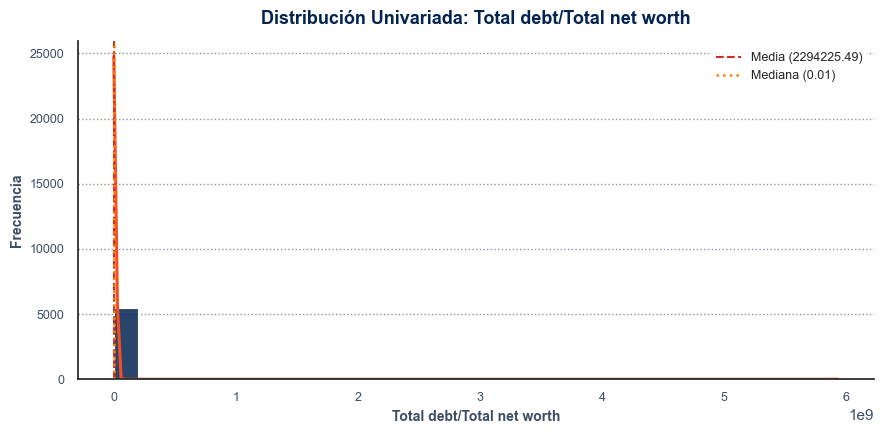

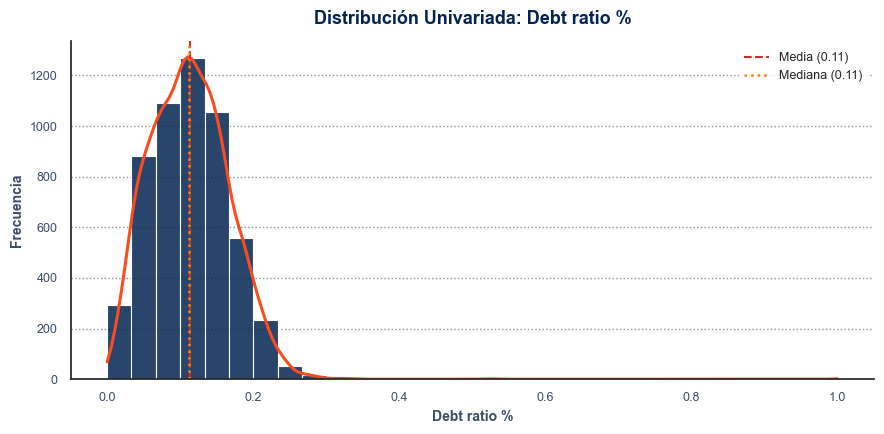

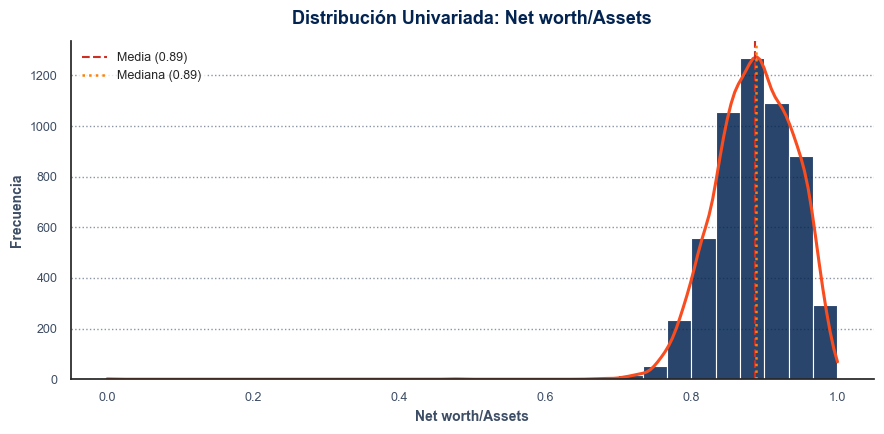

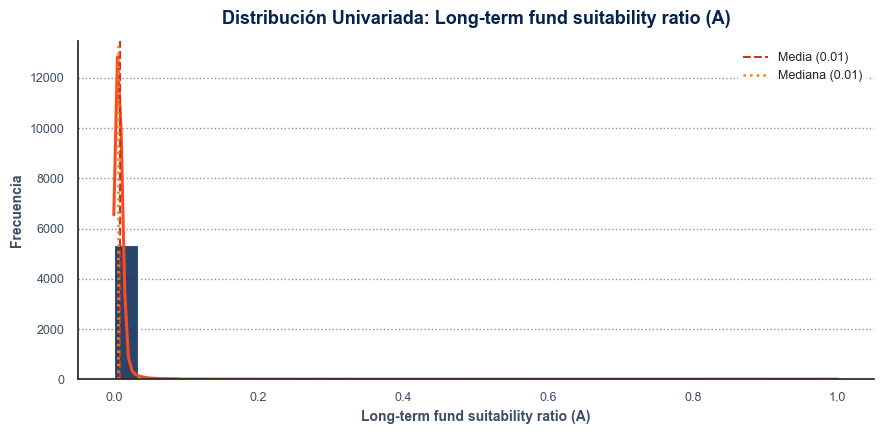

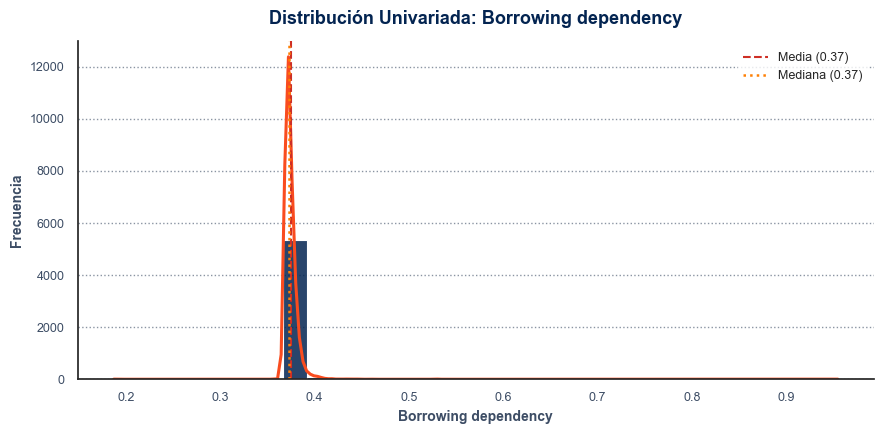

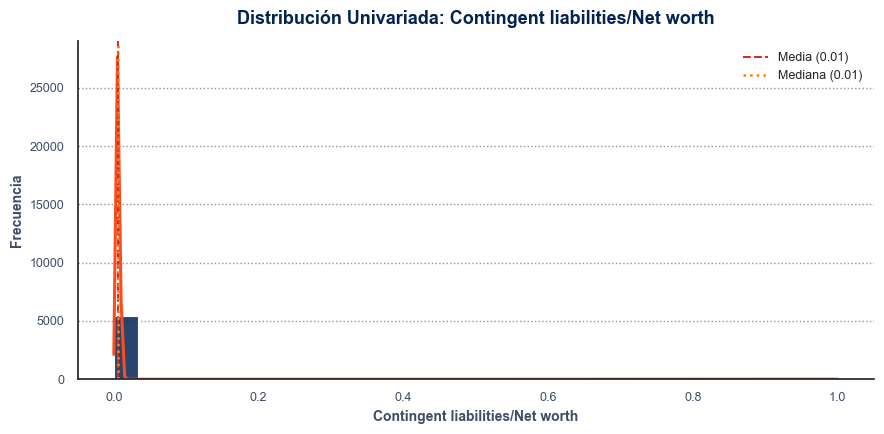

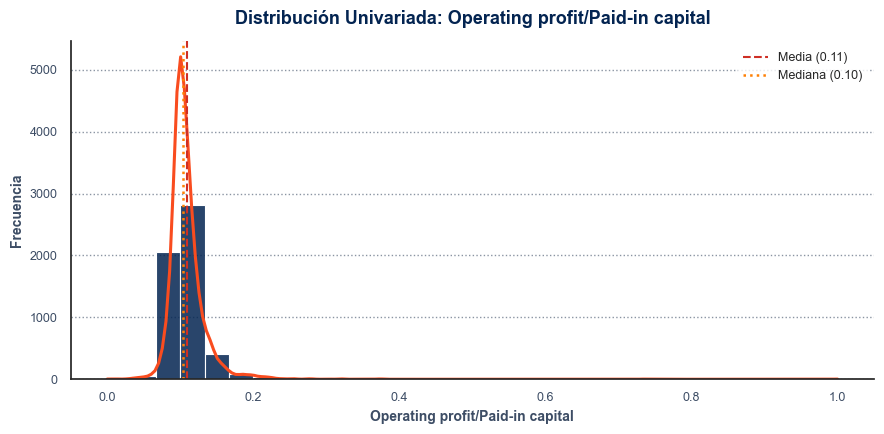

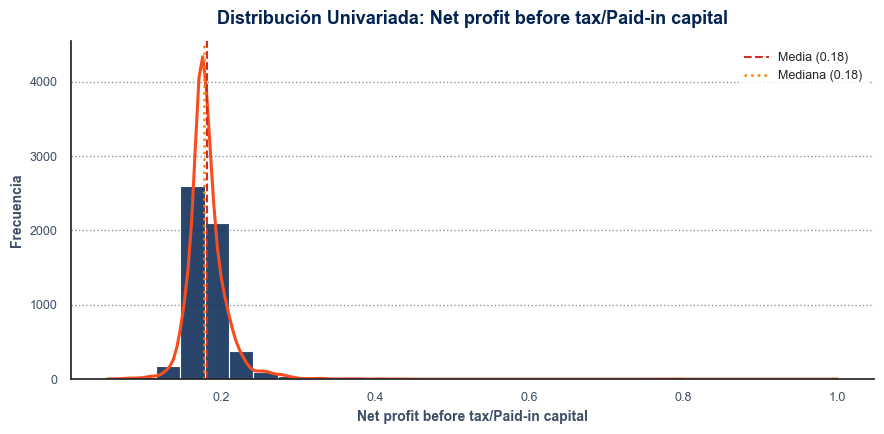

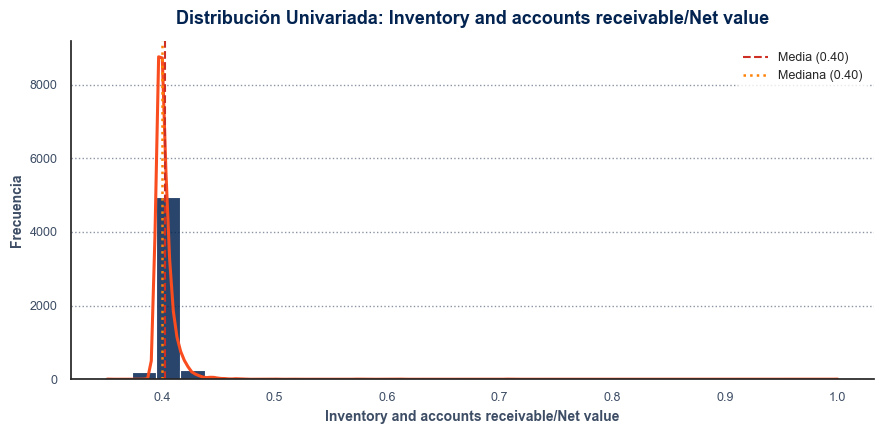

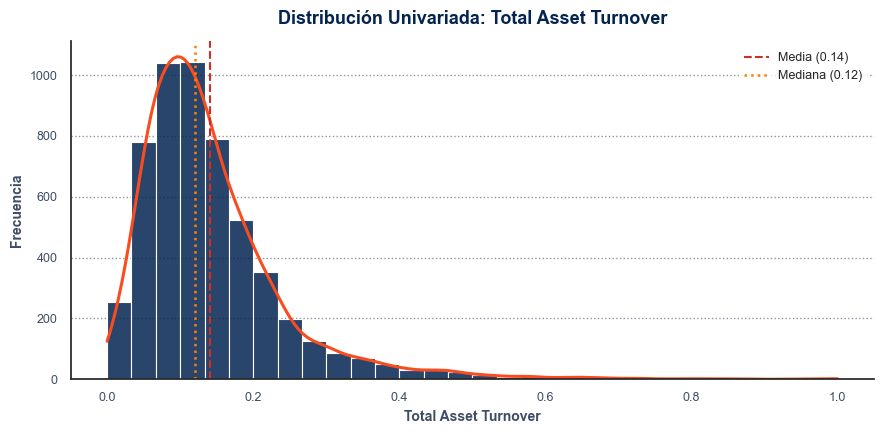

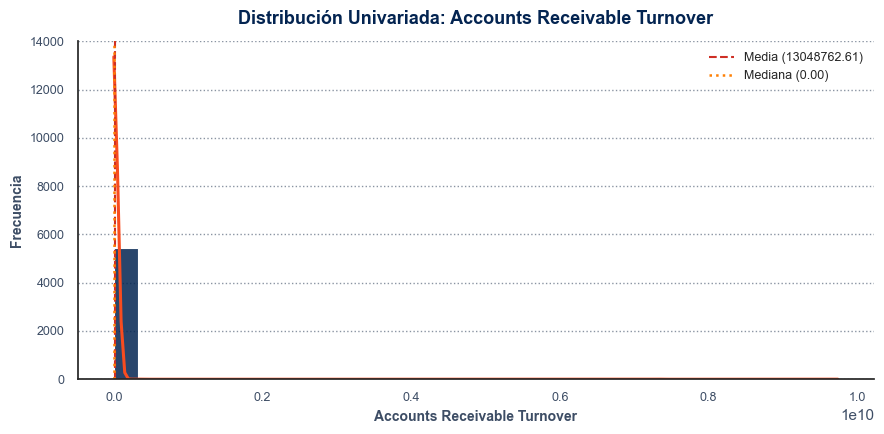

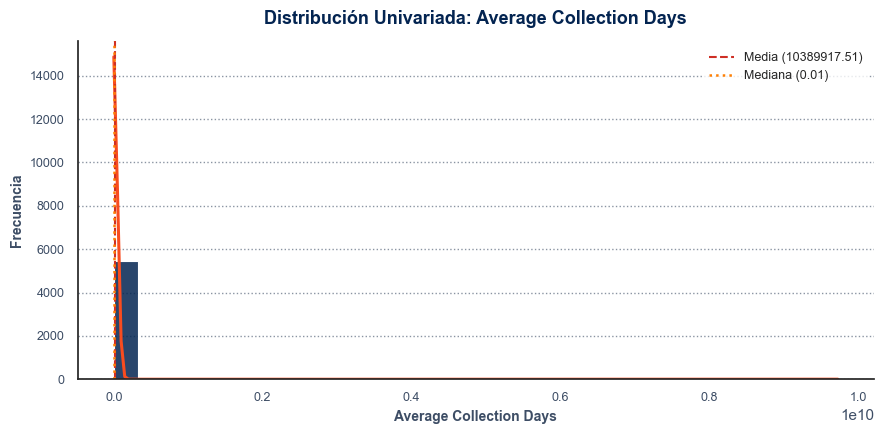

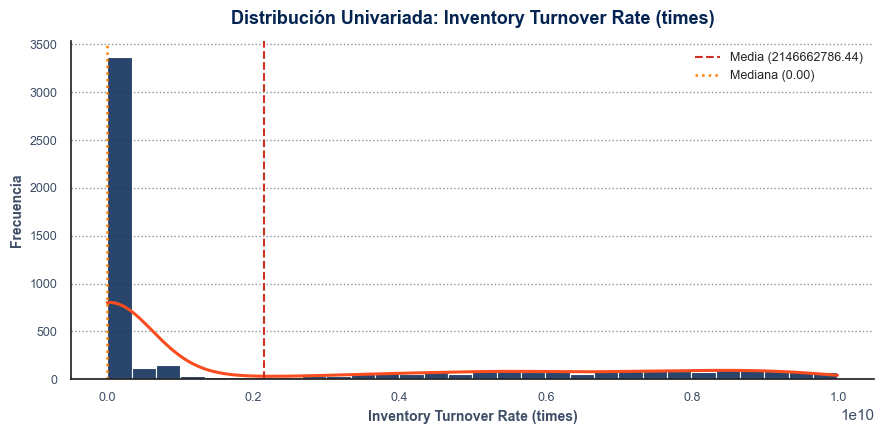

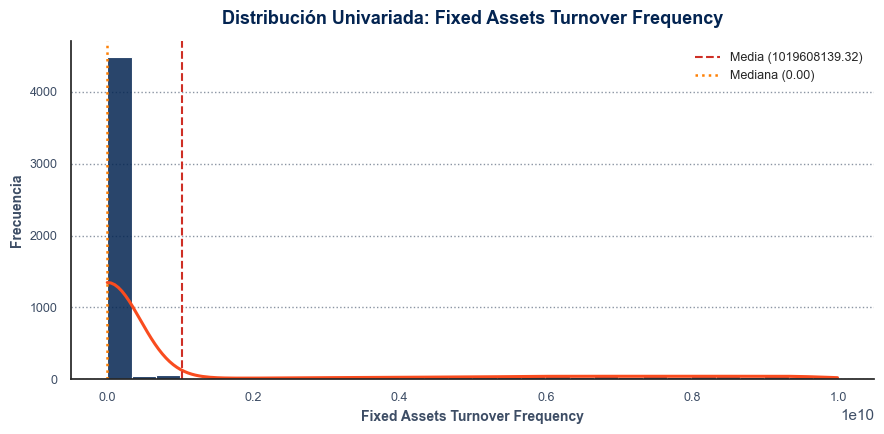

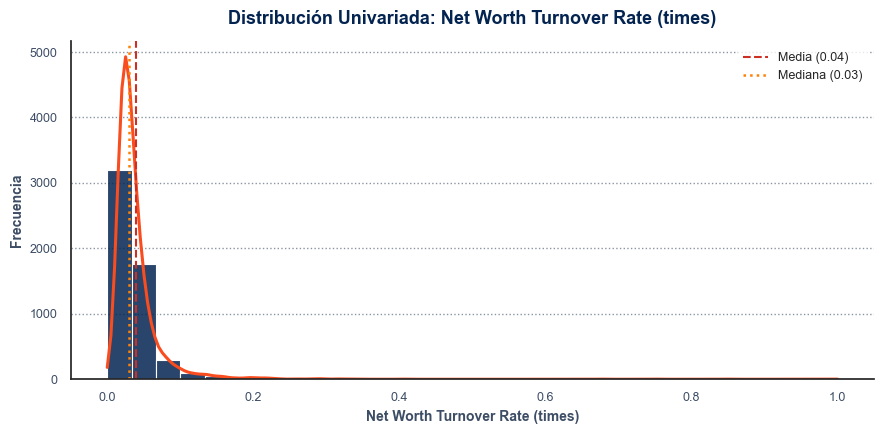

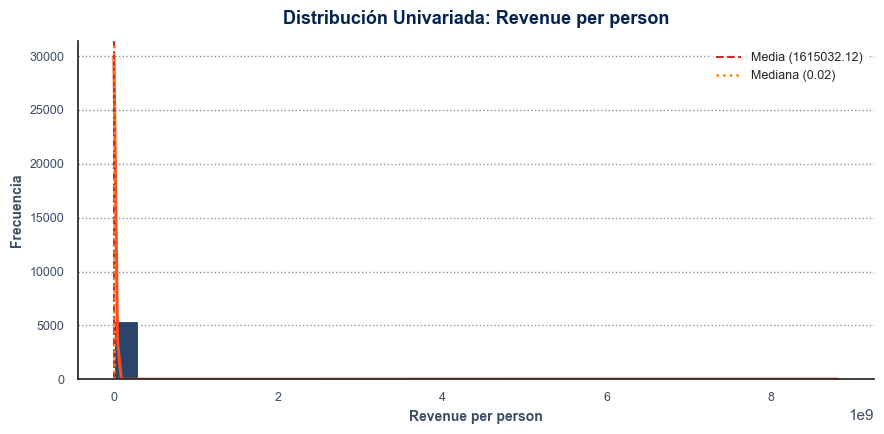

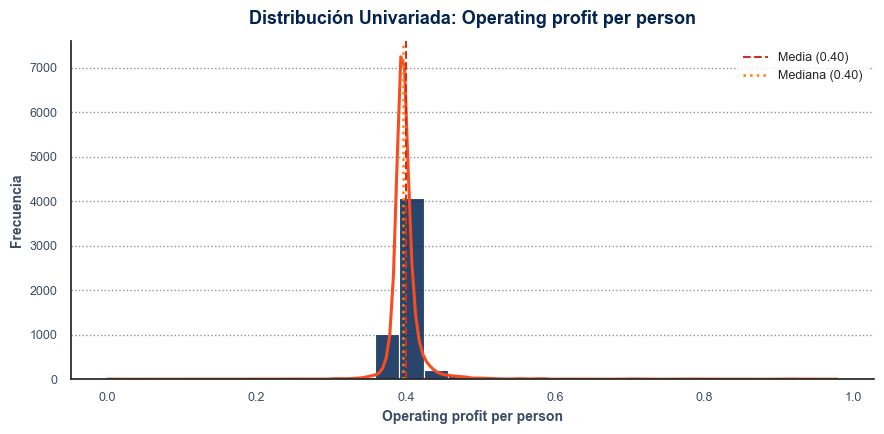

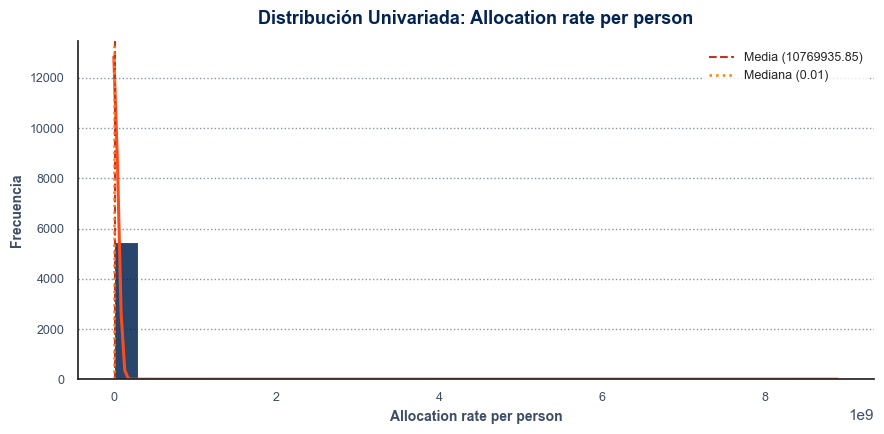

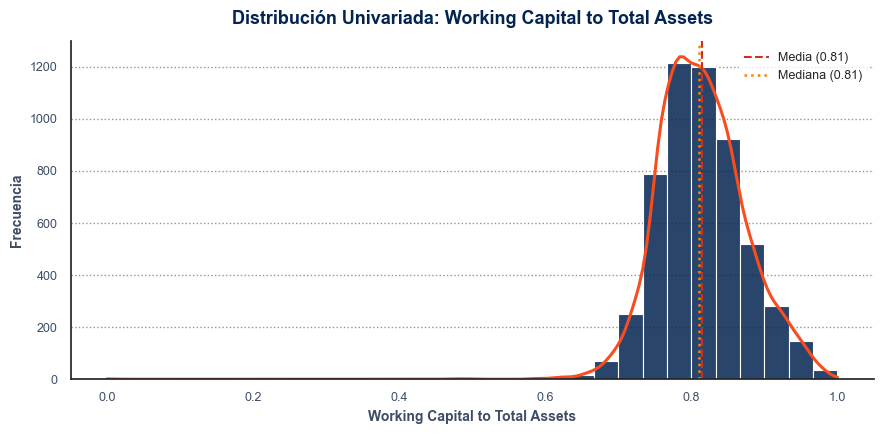

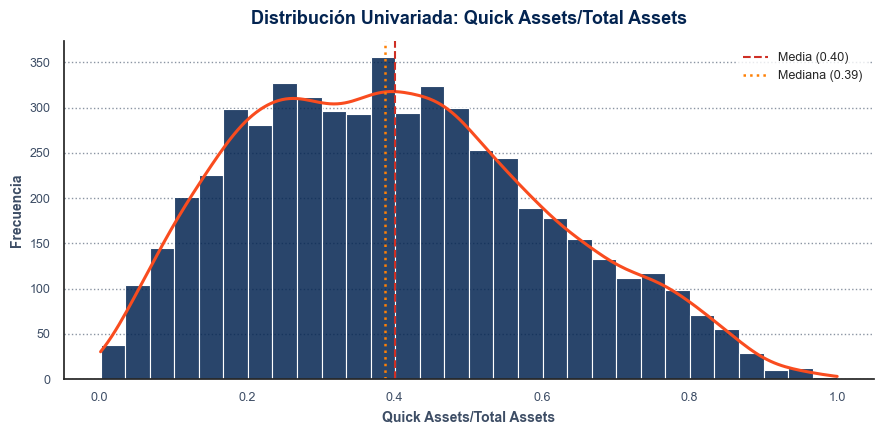

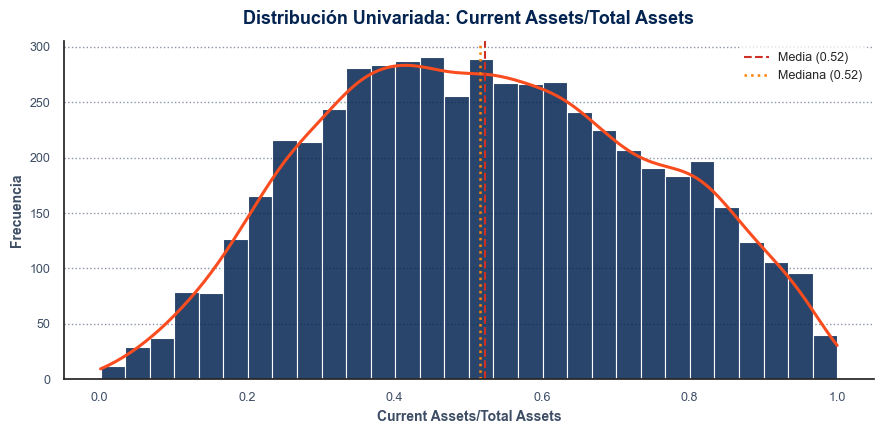

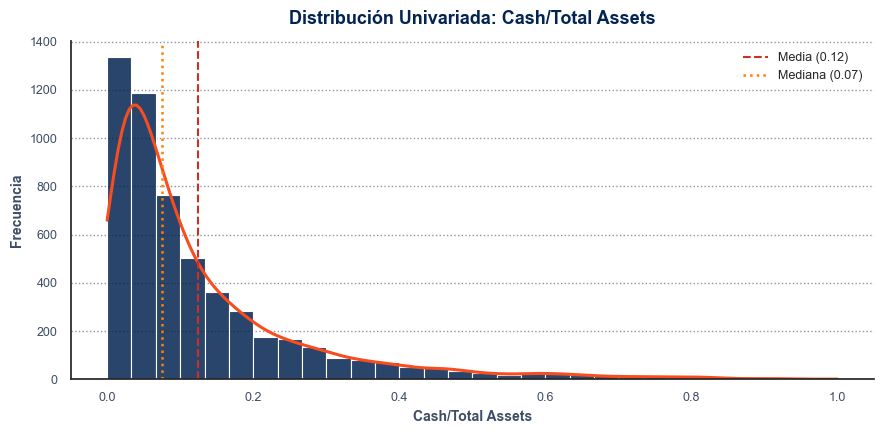

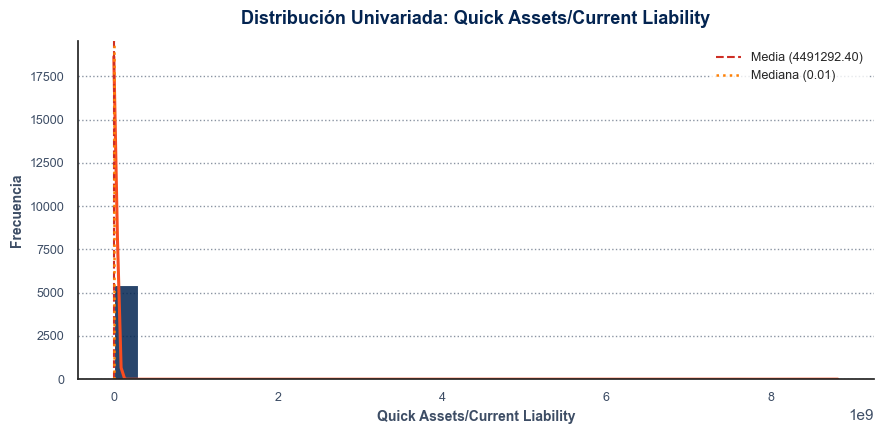

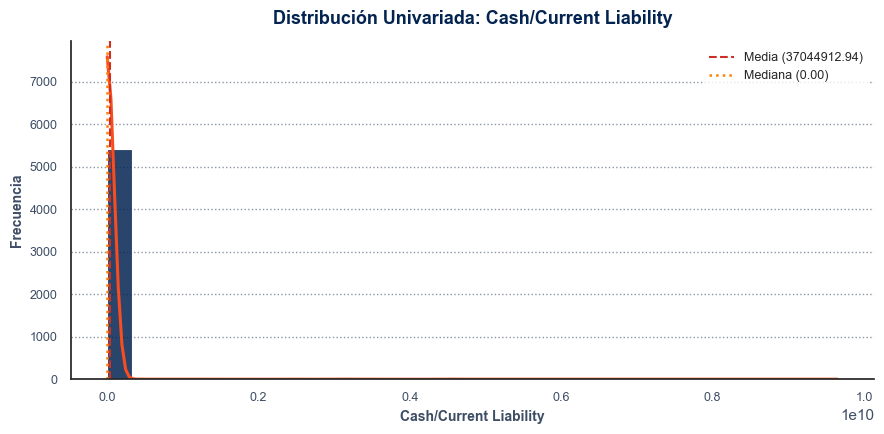

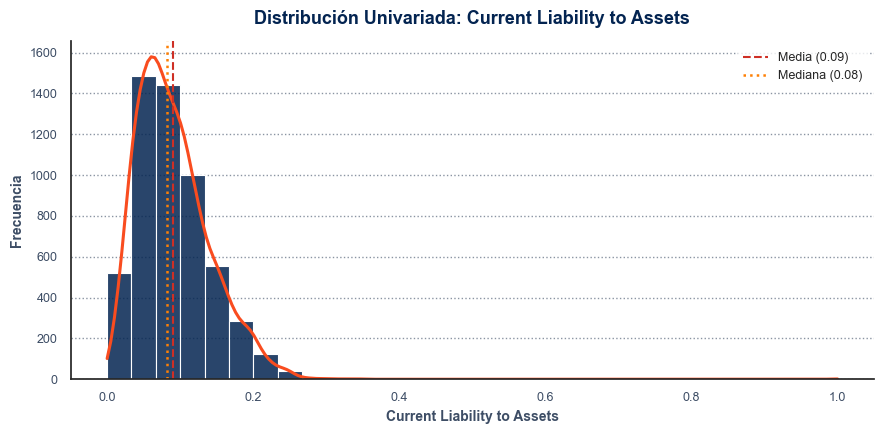

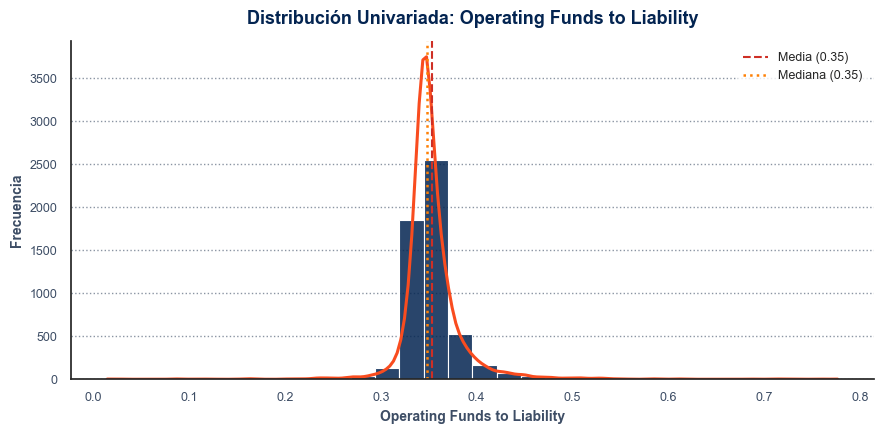

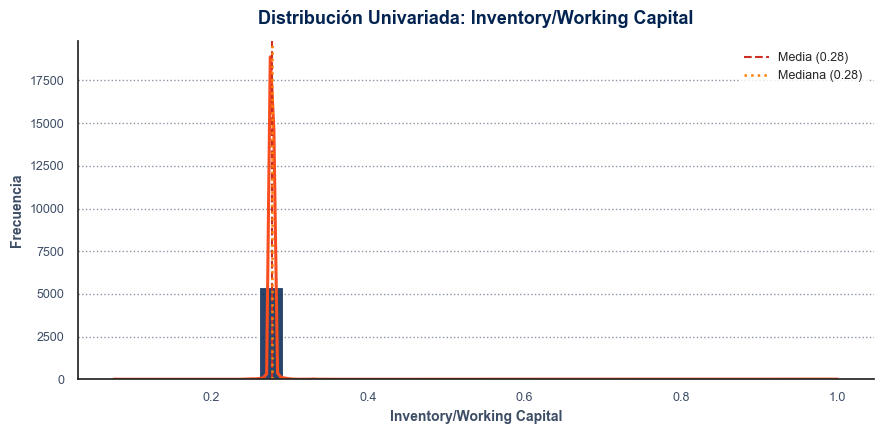

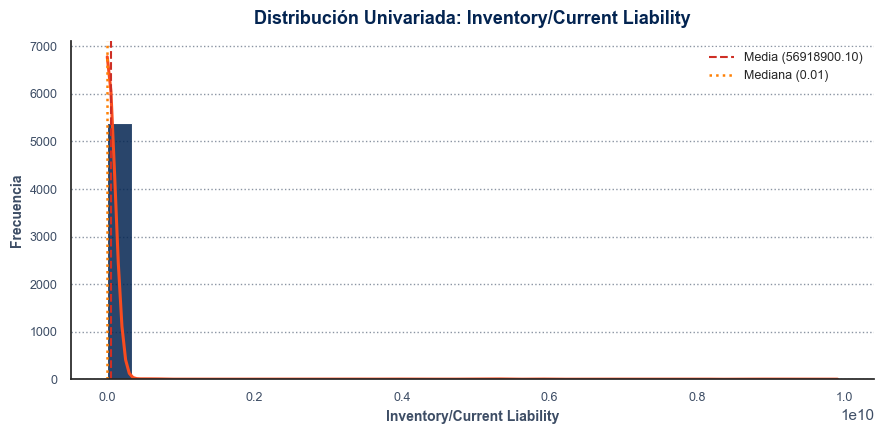

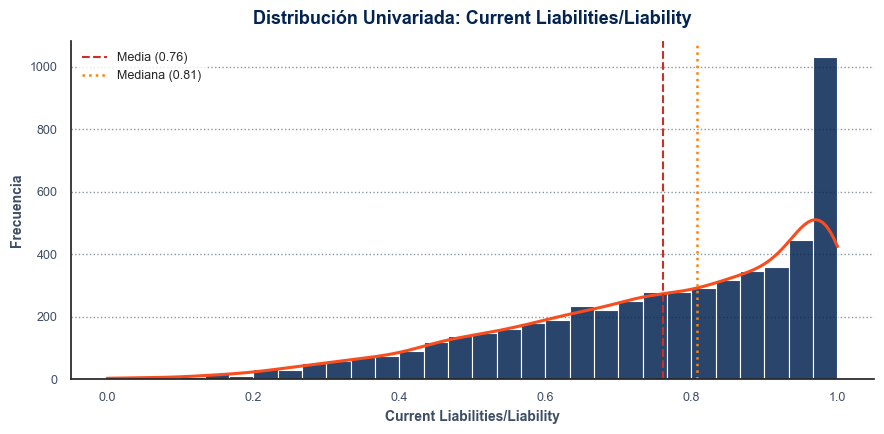

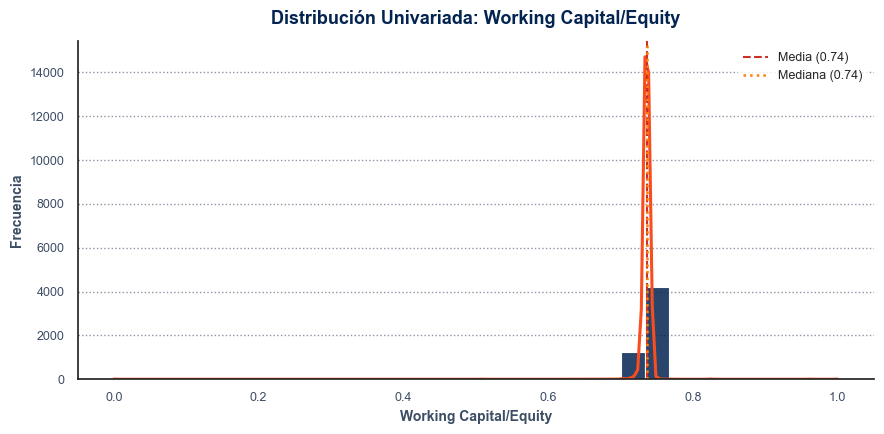

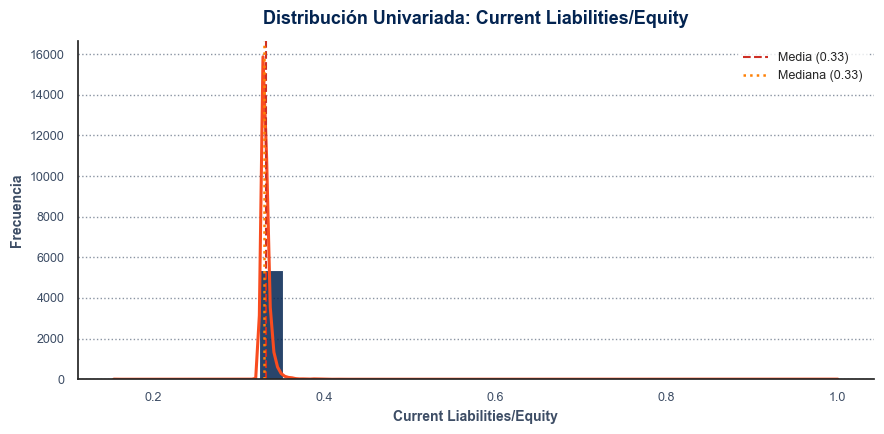

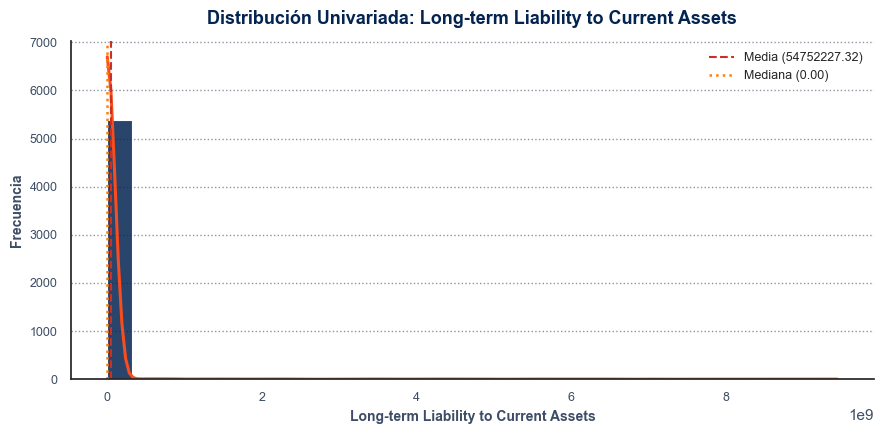

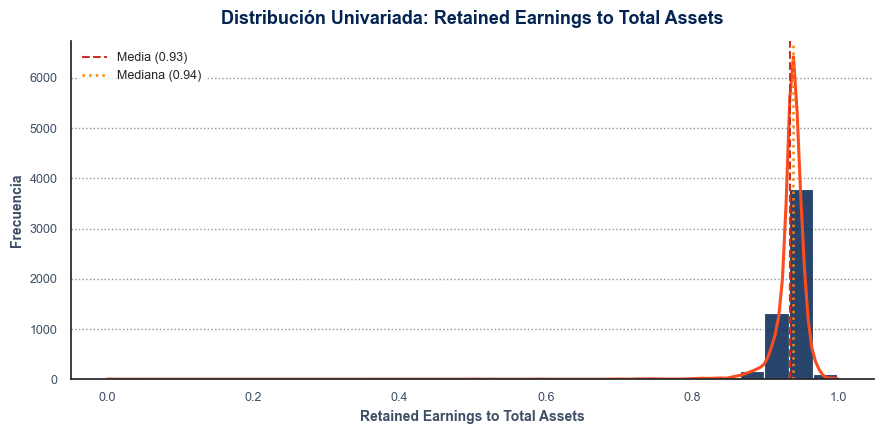

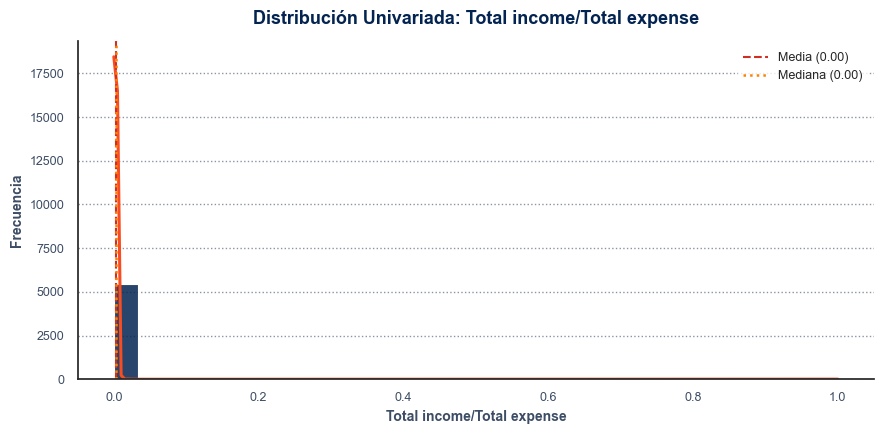

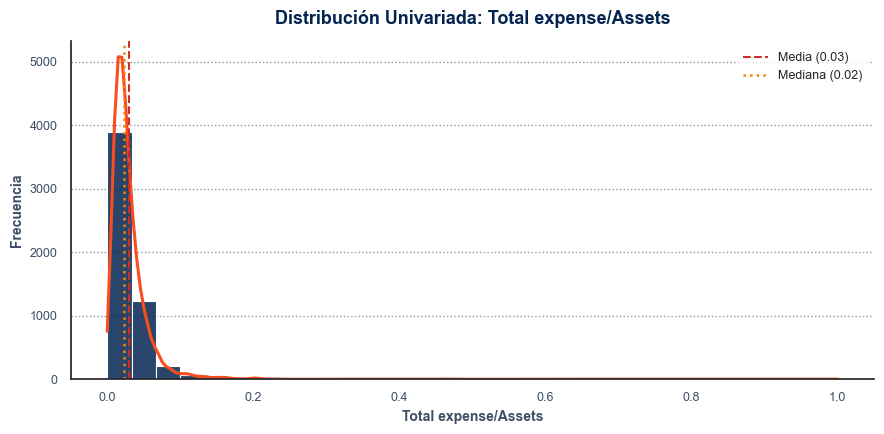

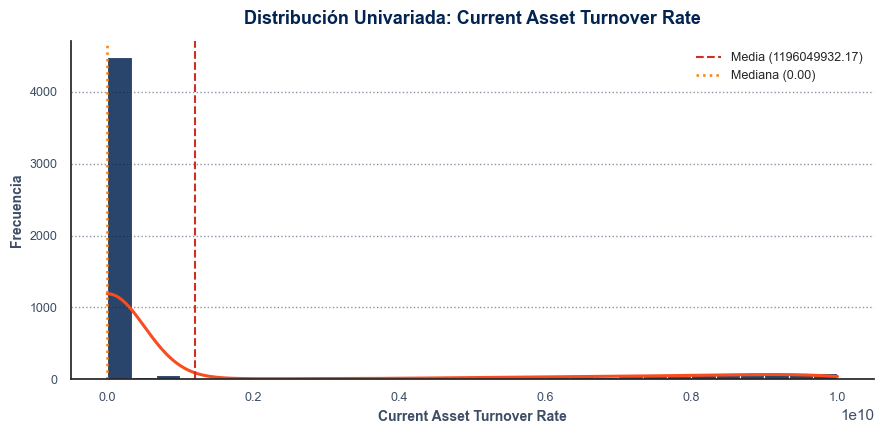

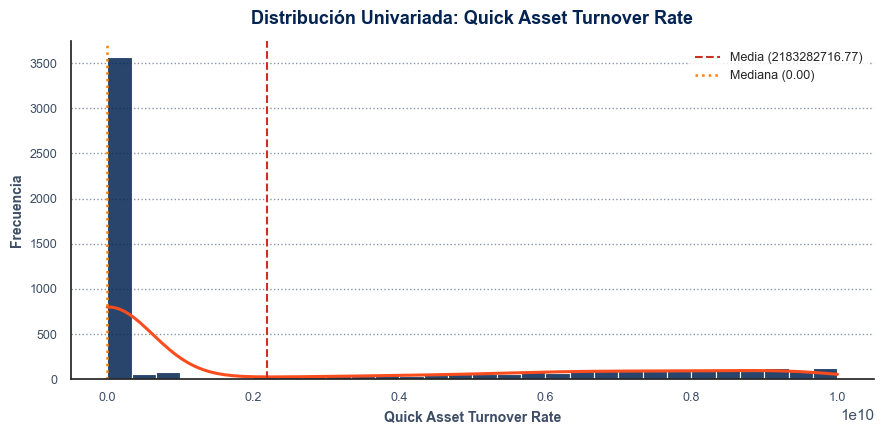

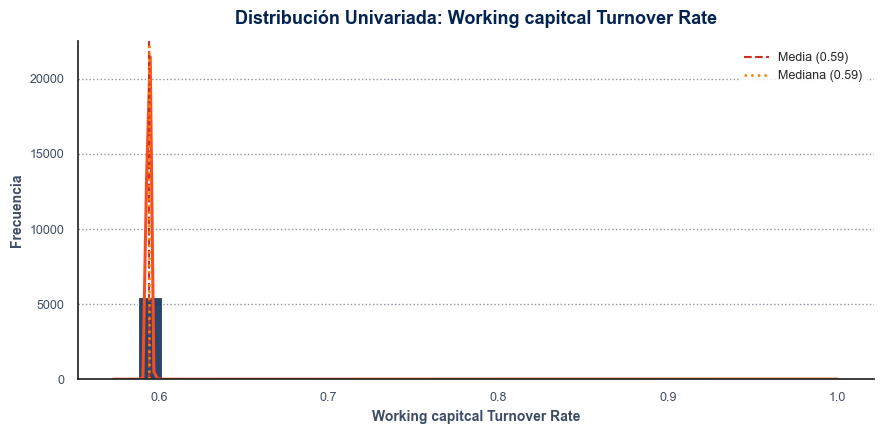

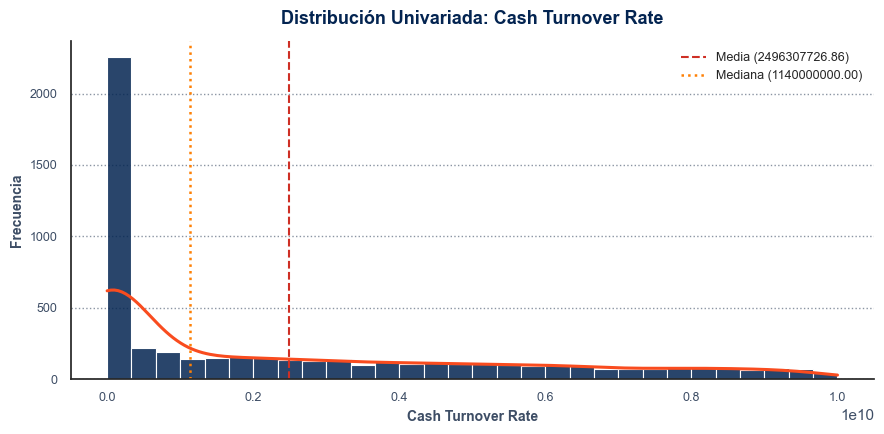

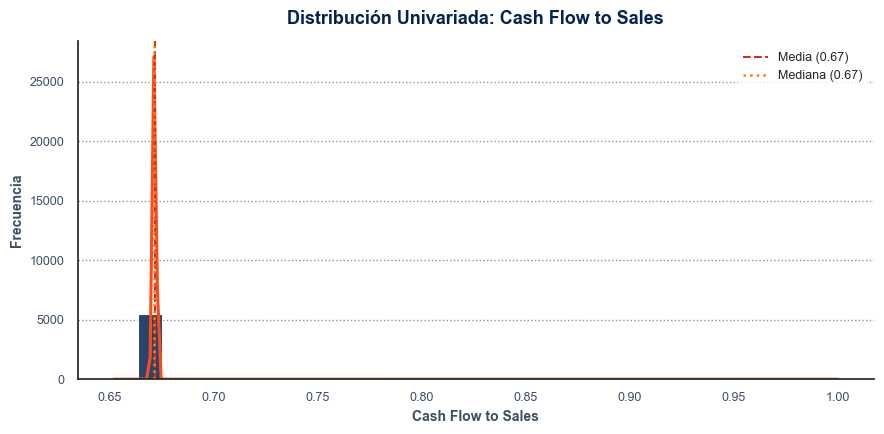

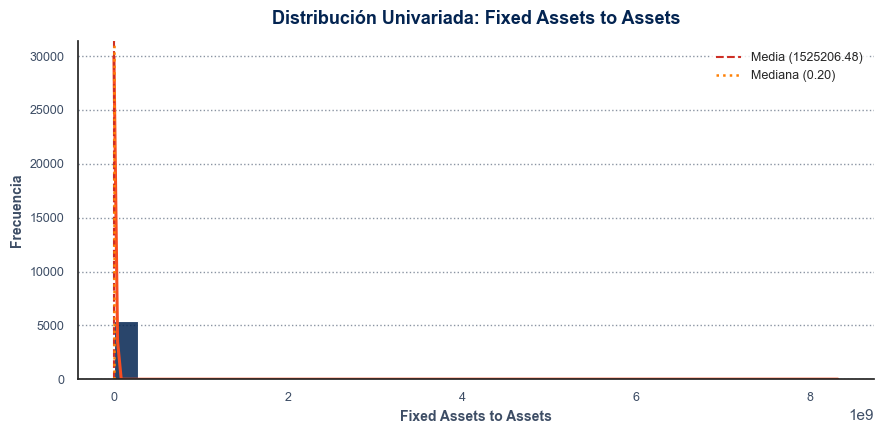

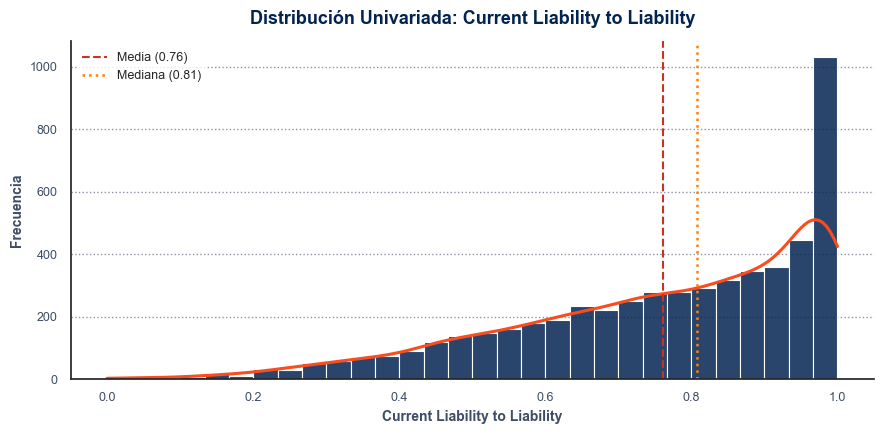

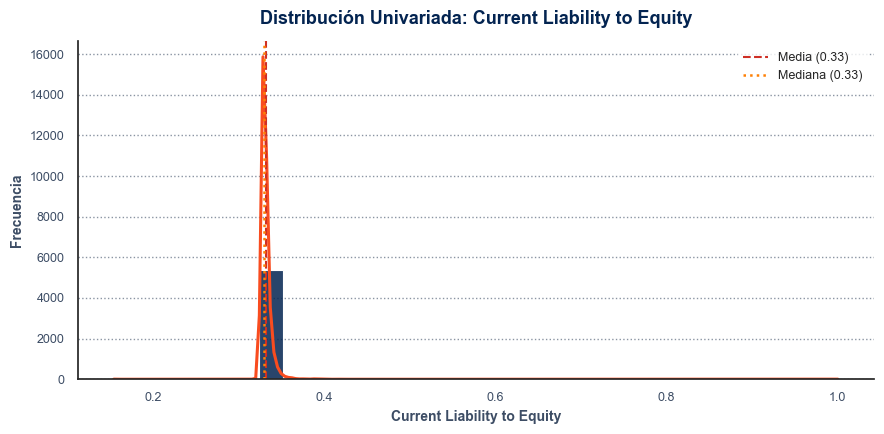

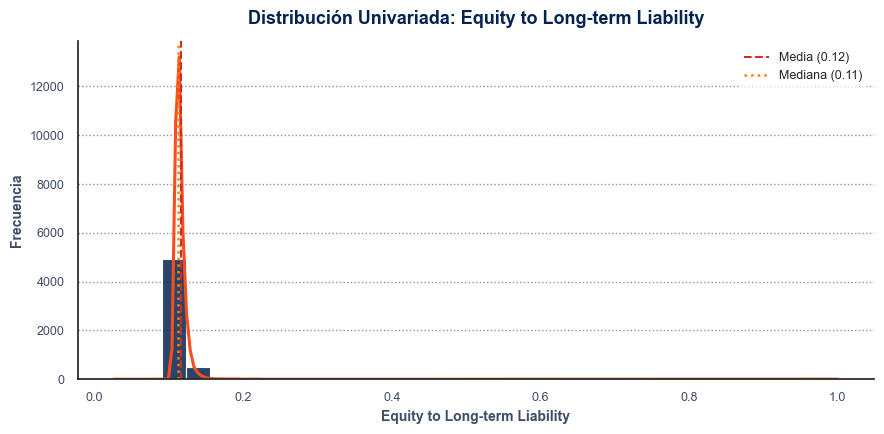

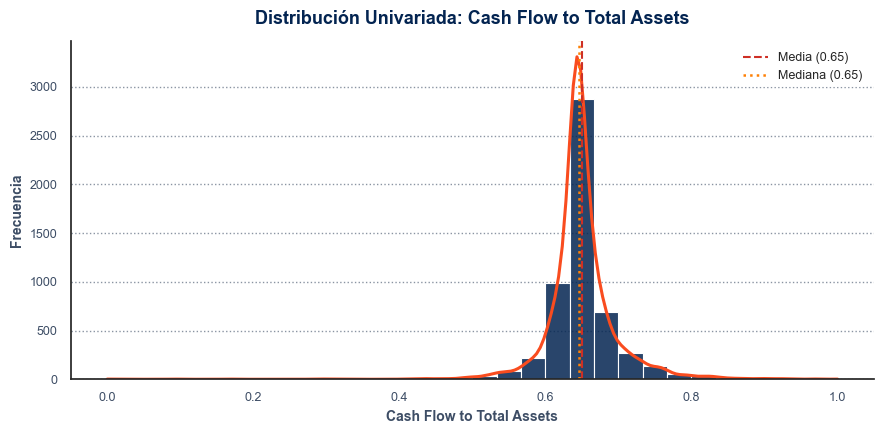

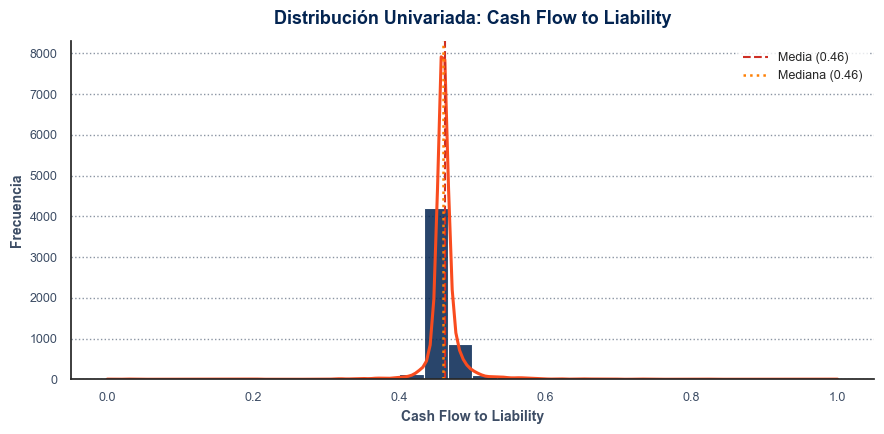

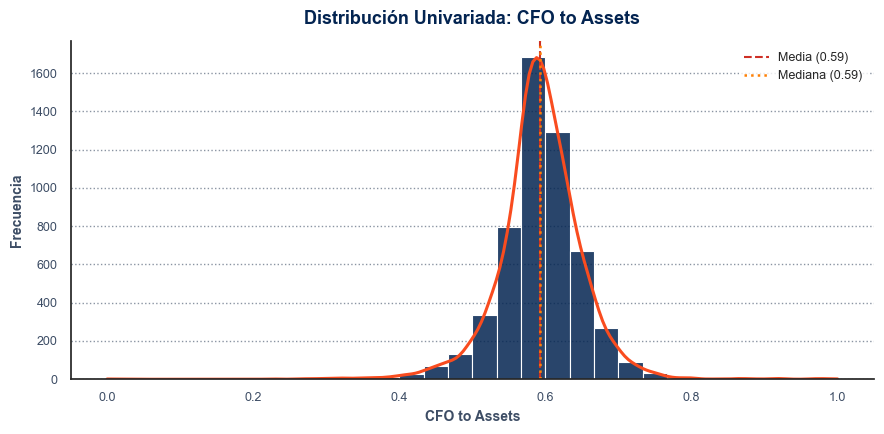

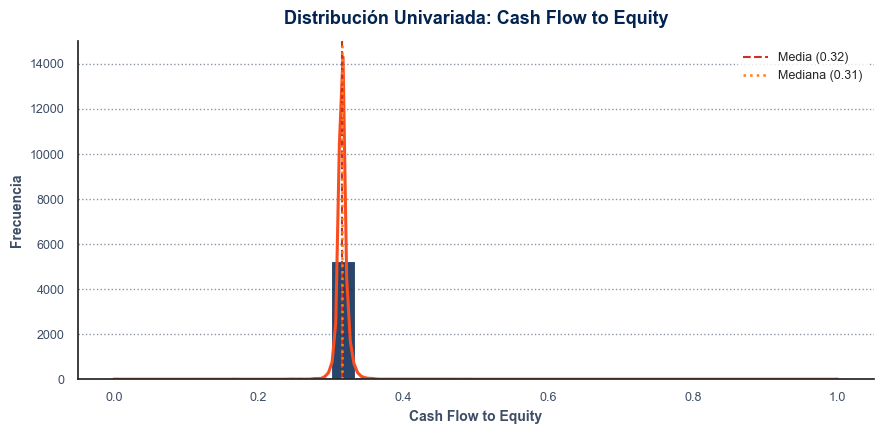

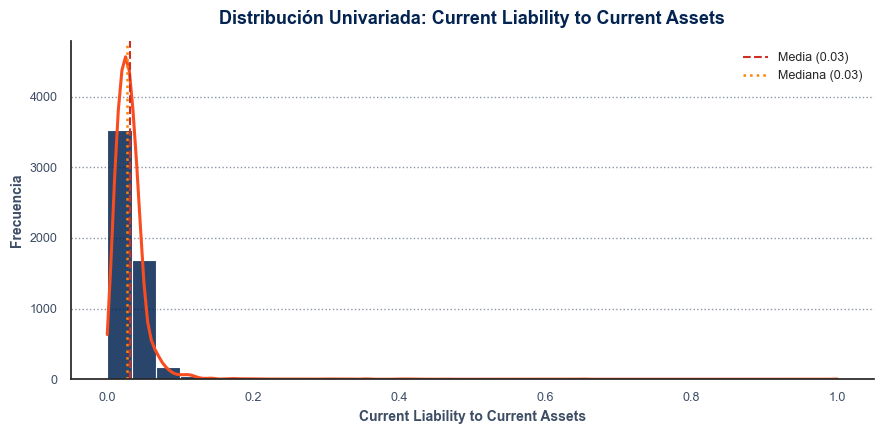

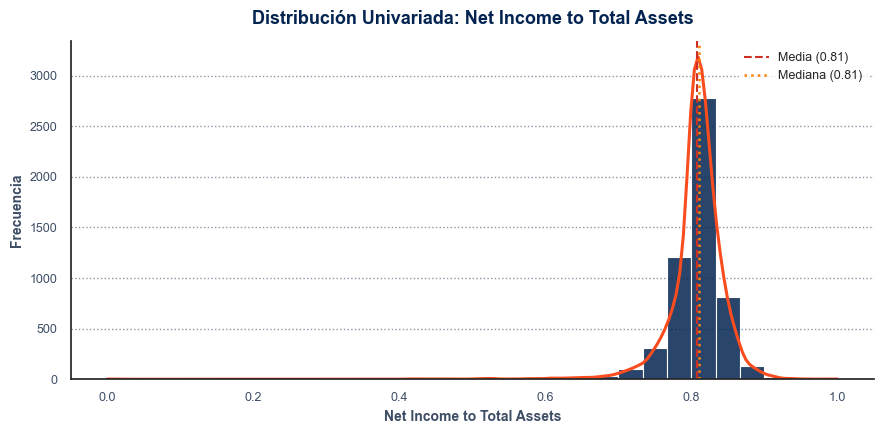

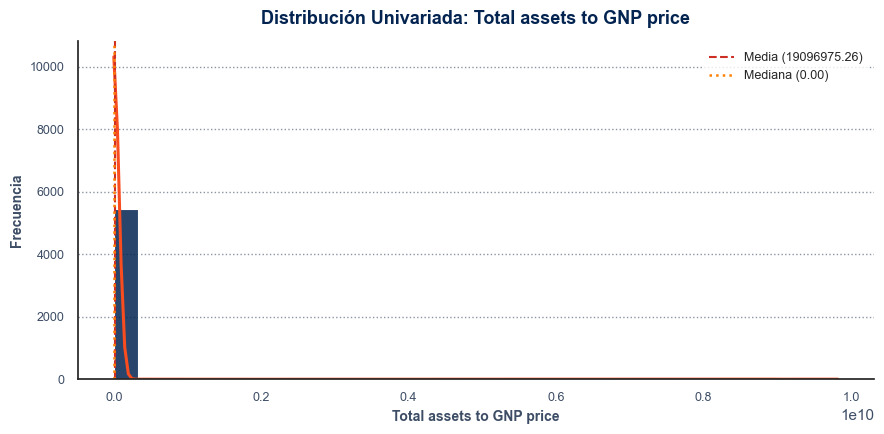

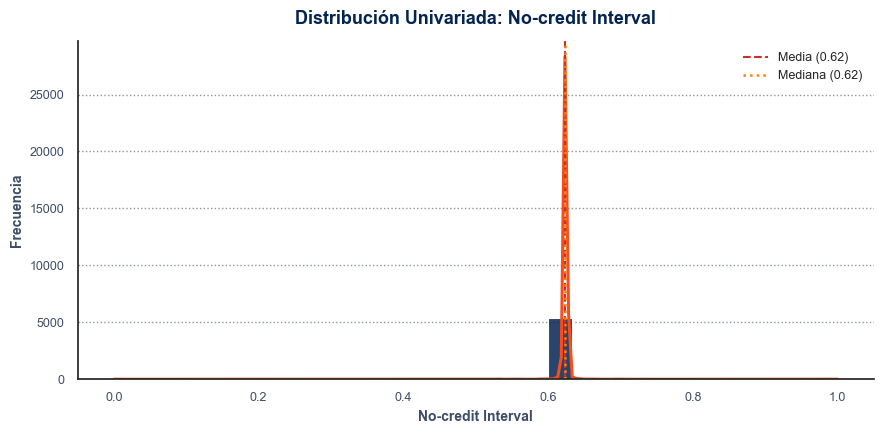

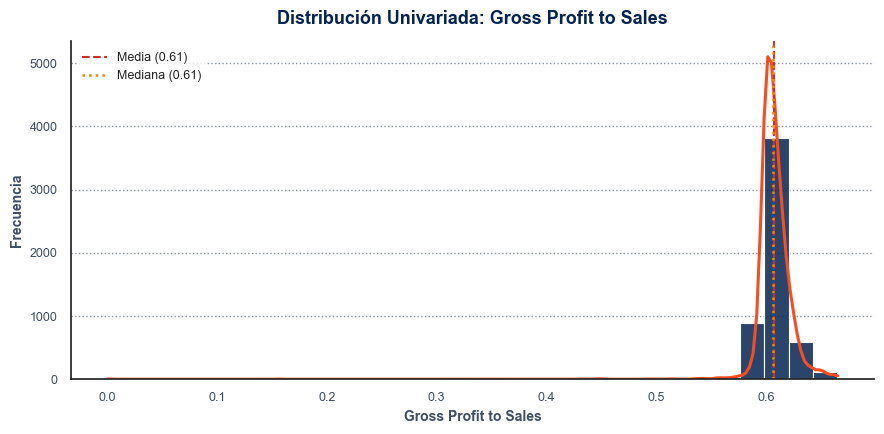

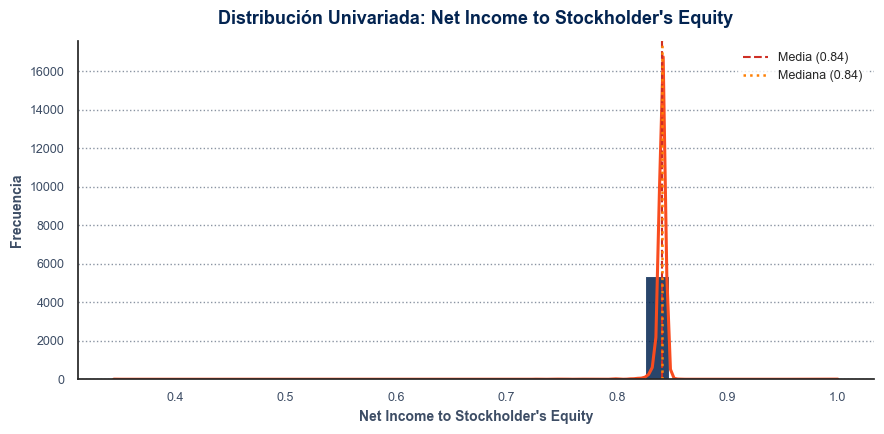

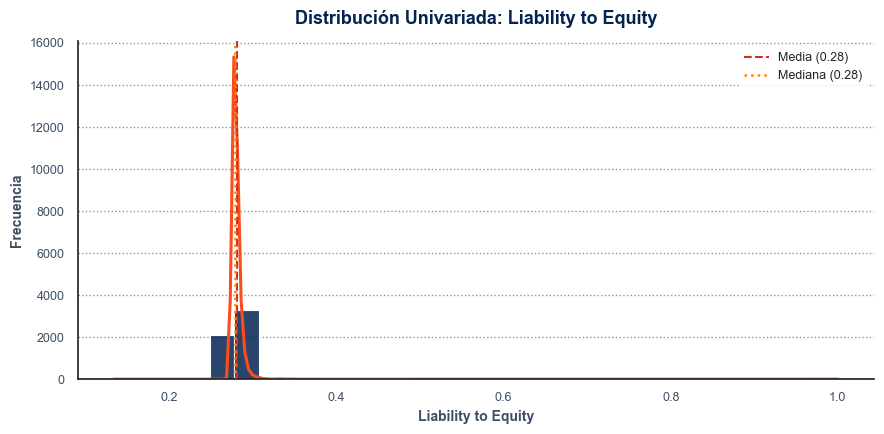

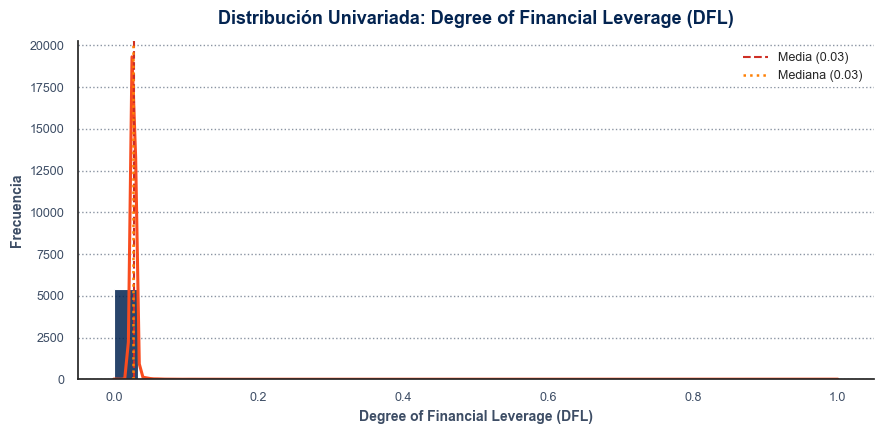

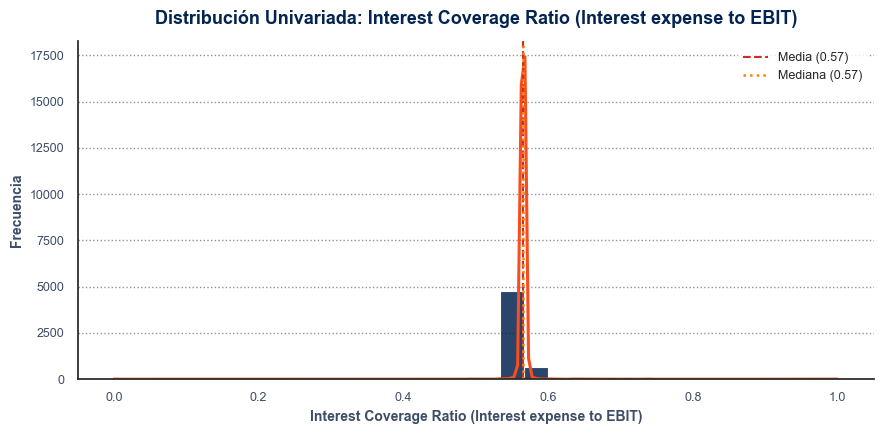

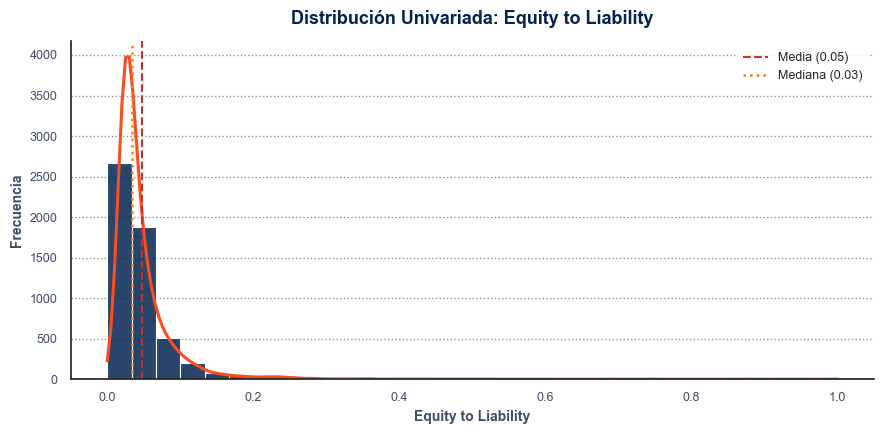

In [16]:
# Configuración base del tema visual
sns.set_theme(style='white', font='sans-serif')

for var in num_vars:
    # 1. Crear figura con estilo limpio y ejecutivo
    fig, ax = plt.subplots(figsize=(9, 4.5), dpi=100)
    
    # 2. Histograma principal
    sns.histplot(
        data=train_df, 
        x=var, 
        bins=30, 
        kde=True, 
        color=PALETTE['downriver'], 
        edgecolor='#FFFFFF',
        linewidth=0.8,
        alpha=0.85,
        ax=ax
    )
    
    # Personalización del gráfico de densidad (KDE)
    if ax.lines:
        ax.lines[0].set_color(PALETTE['flame'])
        ax.lines[0].set_linewidth(2.2)
    
    # Extraer métricas estadísticas
    serie = train_df[var].dropna()
    media_v = serie.mean()
    mediana_v = serie.median()
    kurt_v = serie.kurtosis()
    skew_v = serie.skew()
    
    # Añadir líneas indicadoras para Media y Mediana en el gráfico

    # Líneas corregidas:
    ax.axvline(media_v, color=PALETTE['poinciana'], linestyle='--', linewidth=1.5, label=f'Media ({media_v:.2f})')
    ax.axvline(mediana_v, color=PALETTE['tangerine'], linestyle=':', linewidth=1.8, label=f'Mediana ({mediana_v:.2f})')


    
    # Estilizado de títulos y ejes
    ax.set_title(f'Distribución Univariada: {var}', fontsize=13, fontweight='bold', color=PALETTE['downriver'], pad=12)
    ax.set_xlabel(var, fontsize=10, fontweight='semibold', color=PALETTE['stone_blue'])
    ax.set_ylabel('Frecuencia', fontsize=10, fontweight='semibold', color=PALETTE['stone_blue'])
    
    # Limpieza de bordes (Spines) estilo consultoría
    sns.despine(top=True, right=True, left=False, bottom=False)
    ax.grid(axis='y', linestyle=':', alpha=0.6, color=PALETTE['stone_blue'])
    ax.tick_params(colors=PALETTE['stone_blue'], labelsize=9)
    ax.legend(frameon=True, facecolor='#FFFFFF', edgecolor='none', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    # 3. Liberar explícitamente la memoria
    plt.close(fig)
    
    # Determinar asimetría para el texto dinámico
    if abs(skew_v) < 0.5:
        asimetria_desc = "una distribución relativamente simétrica"
    elif skew_v >= 0.5:
        asimetria_desc = "un marcado sesgo a la derecha (asimetría positiva)"
    else:
        asimetria_desc = "un marcado sesgo a la izquierda (asimetría negativa)"
        
    # 4. Renderizar interpretación HTML con los colores de la paleta
    html_interpretacion = f"""
    <div style="
        background-color: {PALETTE['bg_card']}; 
        border-left: 5px solid {PALETTE['poinciana']}; 
        border-radius: 6px;
        padding: 14px 18px; 
        margin-top: 10px;
        margin-bottom: 30px;
        box-shadow: 0 2px 8px rgba(3, 36, 81, 0.05);
        font-family: 'Segoe UI', -apple-system, BlinkMacSystemFont, Roboto, sans-serif;
    ">
        <h4 style="color: {PALETTE['downriver']}; margin: 0 0 8px 0; font-size: 14px; font-weight: 700; text-transform: uppercase; letter-spacing: 0.5px;">
             Interpretación de {var}
        </h4>
        <p style="margin: 0; color: {PALETTE['stone_blue']}; font-size: 13.5px; line-height: 1.6;">
            El histograma de <b style="color: {PALETTE['downriver']};">{var}</b> muestra {asimetria_desc}, 
            con una media de <b style="color: {PALETTE['poinciana']};">{media_v:.4f}</b> 
            y una mediana de <b style="color: {PALETTE['tangerine']};">{mediana_v:.4f}</b>. 
            La curtosis observada de <b style="color: {PALETTE['downriver']};">{kurt_v:.2f}</b> indica una concentración notable 
            de observaciones alrededor de la zona central, acompañada por la presencia de valores atípicos en las colas. 
            Esta morfología sugiere una alta homogeneidad en el grueso de las empresas analizadas, pero con comportamientos 
            extremos puntuales a monitorear en la etapa de preprocesamiento.
        </p>
    </div>
    """
    display(HTML(html_interpretacion))

#### Varianza cercana a cero

In [17]:
varianzas = train_df[num_vars].var()
vars_bajas = varianzas[varianzas < 1e-6]

print(f"Variables con varianza baja: {len(vars_bajas)}")
if len(vars_bajas) > 0:
    display(vars_bajas)
else:
    print("Ninguna variable numérica tiene varianza cercana a cero en train.")


Variables con varianza baja: 0
Ninguna variable numérica tiene varianza cercana a cero en train.


Con este resultado confirmamos que, entre las 93 variables numéricas, ninguna es prácticamente constante en `train`. Todas tienen variabilidad real y suficiente entre empresas.


### 4.3 Variables categóricas

#### Tabla de frecuencias y gráficos

Categoría,N,Porcentaje (%)
0,"5,450",99.91%
1,5,0.09%


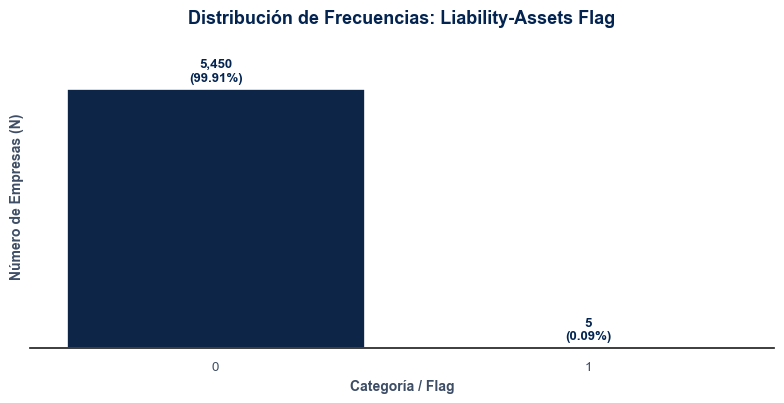

Categoría,N,Porcentaje (%)
1,"5,455",100.00%


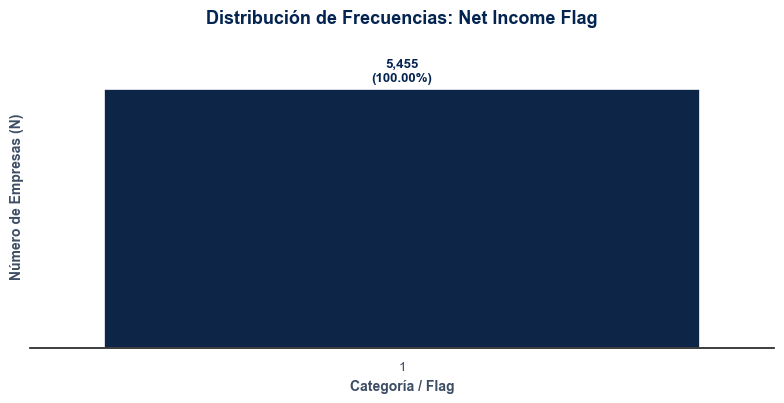

In [18]:
for var in cat_vars:
    # 1. Cálculo de Frecuencias Absolutas (N) y Relativas (%)
    conteo = train_df[var].value_counts(dropna=False).reset_index()
    conteo.columns = ['Categoría', 'N']
    conteo['Porcentaje (%)'] = (conteo['N'] / len(train_df)) * 100

    tabla_estilo(conteo, formatos={'N': '{:,.0f}', 'Porcentaje (%)': '{:.2f}%'},
                 titulo=f"Tabla de Frecuencias: {var}")

    # 2. Generación del Gráfico de Barras
    fig, ax = plt.subplots(figsize=(8, 4.2), dpi=100)

    colores_barras = [PALETTE['downriver'], PALETTE['poinciana'], PALETTE['flame'],
                       PALETTE['tangerine'], PALETTE['tagao']]
    palette_var = colores_barras[:len(conteo)] if len(conteo) > 1 else [PALETTE['downriver']]

    sns.barplot(
        data=conteo, x='Categoría', y='N', hue='Categoría',
        palette=palette_var, edgecolor='#FFFFFF', linewidth=1.2, ax=ax, legend=False
    )

    total = len(train_df)
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            pct = (height / total) * 100
            ax.annotate(
                f'{int(height):,}\n({pct:.2f}%)',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                fontsize=9.5, fontweight='bold', color=PALETTE['downriver'],
                xytext=(0, 4), textcoords='offset points'
            )

    ax.set_title(f'Distribución de Frecuencias: {var}', fontsize=13, fontweight='bold', color=PALETTE['downriver'], pad=14)
    ax.set_xlabel('Categoría / Flag', fontsize=10, fontweight='semibold', color=PALETTE['stone_blue'])
    ax.set_ylabel('Número de Empresas (N)', fontsize=10, fontweight='semibold', color=PALETTE['stone_blue'])
    ax.set_ylim(0, max(conteo['N']) * 1.18)

    sns.despine(top=True, right=True, left=True, bottom=False)
    ax.tick_params(left=False, labelleft=False)
    ax.tick_params(axis='x', colors=PALETTE['stone_blue'], labelsize=9.5)

    plt.tight_layout()
    plt.show()
    plt.close(fig)

    # 3. Interpretación Dinámica
    num_cats = conteo['Categoría'].nunique()
    cat_dominante = conteo.iloc[0]['Categoría']
    pct_dominante = conteo.iloc[0]['Porcentaje (%)']
    n_dominante = conteo.iloc[0]['N']

    if num_cats == 1:
        detalles_interp = (
            f"La variable <b style='color:{PALETTE['downriver']};'>{var}</b> presenta una varianza nula dentro del "
            f"conjunto de entrenamiento (<code>train_df</code>), constituida al 100% por la categoría "
            f"<b style='color:{PALETTE['downriver']};'>{cat_dominante}</b> (<i>N</i> = {n_dominante:,}). "
            f"Al no contar con variabilidad entre las observaciones, esta variable no aporta poder discriminante ni "
            f"información predictiva para los modelos de Machine Learning, por lo que se sugiere su exclusión en el "
            f"preprocesamiento."
        )
    else:
        cat_minoritaria = conteo.iloc[1]['Categoría']
        pct_minoritaria = conteo.iloc[1]['Porcentaje (%)']
        n_minoritaria = conteo.iloc[1]['N']

        detalles_interp = (
            f"El análisis de la variable <b style='color:{PALETTE['downriver']};'>{var}</b> revela una marcada "
            f"asimetría en la distribución de sus categorías. La categoría dominante "
            f"<b style='color:{PALETTE['downriver']};'>{cat_dominante}</b> representa el "
            f"<b style='color:{PALETTE['downriver']};'>{pct_dominante:.2f}%</b> de la muestra (<i>N</i> = {n_dominante:,}), "
            f"mientras que la categoría <b style='color:{PALETTE['poinciana']};'>{cat_minoritaria}</b> concentra "
            f"únicamente el <b style='color:{PALETTE['poinciana']};'>{pct_minoritaria:.2f}%</b> de los registros "
            f"(<i>N</i> = {n_minoritaria:,}). Esta desproporción evidencia un comportamiento altamente desbalanceado "
            f"en este indicador financiero dentro de las empresas evaluadas."
        )

    tarjeta_interpretacion(f"Interpretación de {var}", detalles_interp)


### 4.4 Análisis de outliers y sesgos

Antes de pasar al análisis bivariado, es importante identificar qué variables tienen
distribuciones muy sesgadas y/o outliers extremos, ya que esto afecta tanto la
interpretación visual como la elección de modelos y transformaciones en la fase de
Machine Learning.


#### TOP 10 variables con mayor sesgo, en valor absoluto

In [19]:
# 1. Cálculo de Asimetría (Skewness)
skew_vals = train_df[num_vars].skew().sort_values(key=lambda s: s.abs(), ascending=False)
top_skew_vars = skew_vals.head(6).index.tolist()

# 2. Tabla Ejecutiva del Top 10 con mayor asimetría absoluta
df_skew_top10 = skew_vals.head(10).reset_index()
df_skew_top10.columns = ['Variable', 'Coeficiente de Asimetría (Skewness)']


def clasificar_sesgo(val):
    if val >= 1.0:
        return 'Sesgo Positivo Severo (Derecha)'
    elif val <= -1.0:
        return 'Sesgo Negativo Severo (Izquierda)'
    elif abs(val) >= 0.5:
        return 'Sesgo Moderado'
    else:
        return 'Relativamente Simétrica'


df_skew_top10['Diagnóstico de Morfología'] = df_skew_top10['Coeficiente de Asimetría (Skewness)'].apply(clasificar_sesgo)

tabla_estilo(
    df_skew_top10,
    formatos={'Coeficiente de Asimetría (Skewness)': '{:+.4f}'},
    titulo='Top 10 Variables Numéricas con Mayor Asimetría (Skewness)'
)


Variable,Coeficiente de Asimetría (Skewness),Diagnóstico de Morfología
Fixed Assets to Assets,+73.8580,Sesgo Positivo Severo (Derecha)
Revenue per person,+73.8580,Sesgo Positivo Severo (Derecha)
Net Value Growth Rate,+73.8580,Sesgo Positivo Severo (Derecha)
Total income/Total expense,+73.6964,Sesgo Positivo Severo (Derecha)
Operating Profit Rate,-73.3637,Sesgo Negativo Severo (Izquierda)
Contingent liabilities/Net worth,+71.8510,Sesgo Positivo Severo (Derecha)
Operating Profit Growth Rate,-69.0960,Sesgo Negativo Severo (Izquierda)
Working capitcal Turnover Rate,+67.0864,Sesgo Positivo Severo (Derecha)
Total Asset Return Growth Rate Ratio,-63.8841,Sesgo Negativo Severo (Izquierda)
Continuous interest rate (after tax),-62.7934,Sesgo Negativo Severo (Izquierda)


Las variables presentan valores de sesgo muy altos, tanto positivos como negativos. Esto indica que varias distribuciones están alejadas de una distribución simétrica y pueden presentar valores extremos.

**Fixed Assets to Assets, Revenue per person** y **Net Value Growth Rate** presenta el mayor sesgo positivo, con valores cercanos a 73,86. Esto indica una fuerte concentración de los datos en ciertos valores y la presencia de observaciones extremas hacia la derecha.
**Operating Profit Rate** presenta un sesgo negativo de aproximadamente -73,36, lo que indica una distribución con una cola pronunciada hacia la izquierda.
Las demás variables también presentan valores de sesgo elevados, como **Contingent liabilities/Net worth** (71,85) y **Working capital Turnover Rate** (67,09).

**Conclusión:** Varias variables presentan un sesgo elevado, lo que sugiere la presencia de distribuciones muy asimétricas y posibles valores extremos. Estas variables deberán revisarse durante el preprocesamiento para determinar si requieren alguna transformación, especialmente si se utilizan modelos sensibles a la escala o a la distribución de los datos.


#### Boxplots de las variables más sesgadas

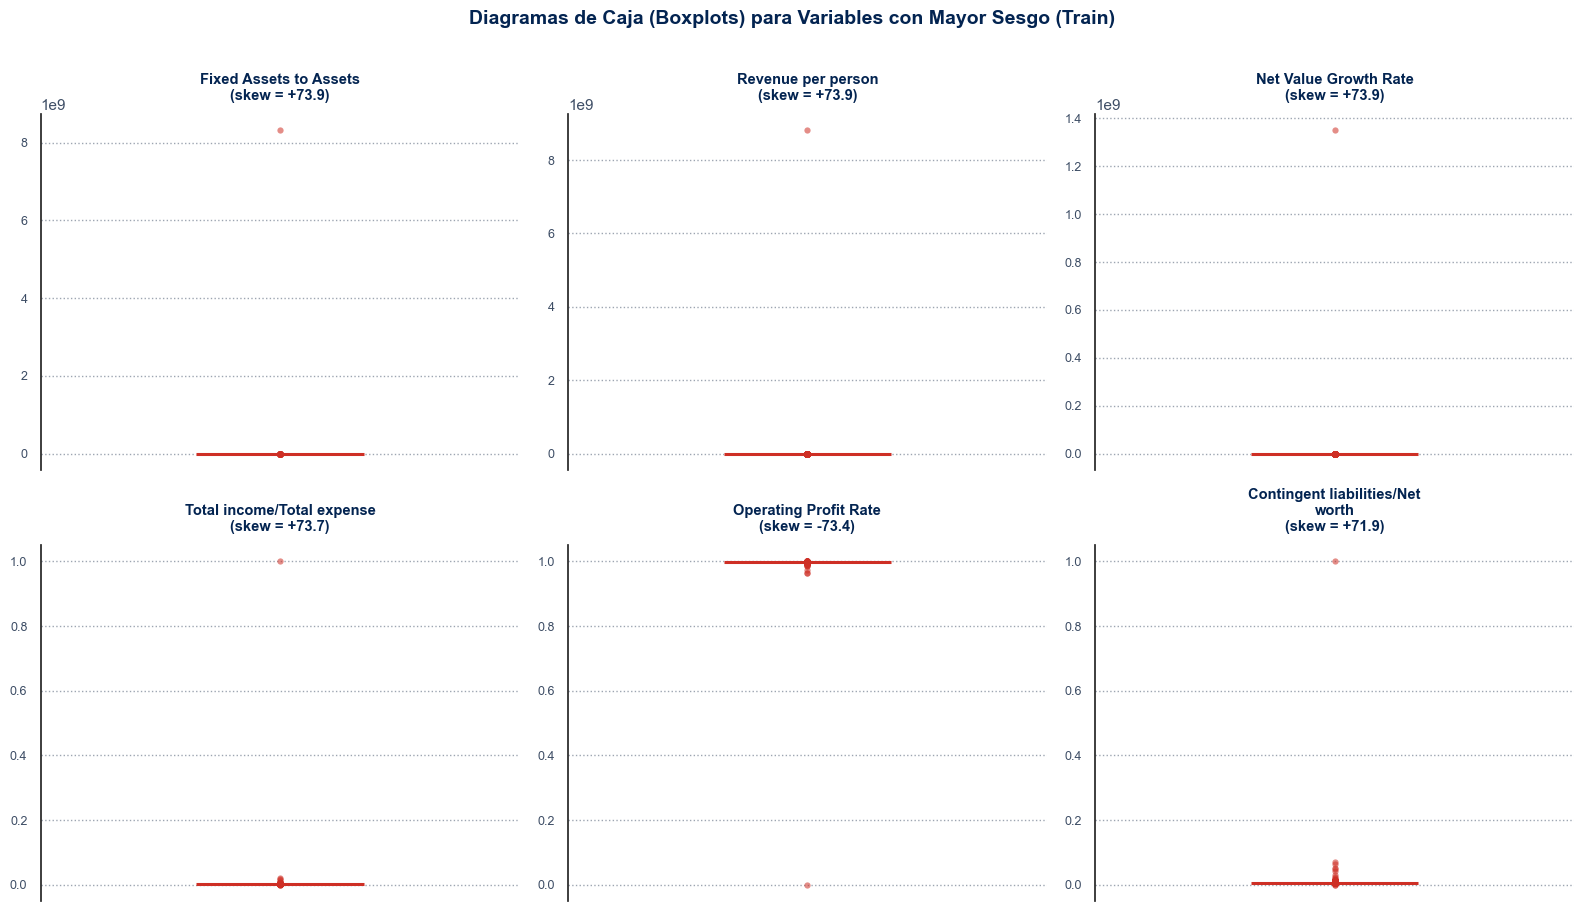

In [20]:
# Boxplots de las 6 variables con mayor sesgo absoluto
fig, axes = plt.subplots(2, 3, figsize=(16, 9), dpi=100)
axes = axes.flatten()
fig.patch.set_facecolor('#FFFFFF')

for i, var in enumerate(top_skew_vars):
    ax = axes[i]

    sns.boxplot(
        data=train_df, y=var, ax=ax,
        color=PALETTE['downriver'], width=0.35,
        boxprops=dict(edgecolor='#FFFFFF', linewidth=1.2, alpha=0.9),
        medianprops=dict(color=PALETTE['poinciana'], linewidth=2.2),
        whiskerprops=dict(color=PALETTE['downriver'], linewidth=1.4),
        capprops=dict(color=PALETTE['downriver'], linewidth=1.4),
        flierprops=dict(marker='o', markerfacecolor=PALETTE['poinciana'], markeredgecolor='none',
                         markersize=4.5, alpha=0.55)
    )

    titulo = "\n".join(textwrap.wrap(var, width=26))
    val_skew = skew_vals[var]

    ax.set_title(f'{titulo}\n(skew = {val_skew:+.1f})', fontsize=10.5, fontweight='bold',
                 color=PALETTE['downriver'], pad=10)
    ax.set_ylabel('', fontsize=9)
    ax.tick_params(axis='y', colors=PALETTE['stone_blue'], labelsize=9)
    ax.tick_params(axis='x', bottom=False, labelbottom=False)

    sns.despine(ax=ax, top=True, right=True, bottom=True)
    ax.grid(axis='y', linestyle=':', alpha=0.5, color=PALETTE['stone_blue'])

plt.suptitle('Diagramas de Caja (Boxplots) para Variables con Mayor Sesgo (Train)',
             fontsize=14, fontweight='bold', color=PALETTE['downriver'], y=1.01)

plt.tight_layout()
plt.show()
plt.close(fig)


- **Fixed Assets to Assets:** La mayoría de los valores se concentra cerca de cero, pero aparece un valor extremadamente alto. Esto explica el fuerte sesgo positivo y muestra la presencia de un valor atípico muy marcado.
- **Revenue per person:** Presenta un comportamiento similar. La mayoría de las observaciones está concentrada en valores bajos, mientras que existe un valor extremadamente alto que distorsiona la distribución.
- **Net Value Growth Rate:** Casi todos los valores se encuentran cerca de cero, pero se observa un valor muy alejado del resto. Este valor extremo explica gran parte del sesgo positivo de la variable.
- **Total income/Total expense:** La mayoría de las observaciones se concentra cerca de valores bajos, mientras que aparece un valor cercano a 1 claramente separado del resto. Esto indica una distribución muy asimétrica y la presencia de un posible valor atípico.
- **Operating Profit Rate:** Los valores están muy concentrados cerca de 1, aunque aparecen algunas observaciones alejadas, principalmente hacia valores inferiores. Esto genera el fuerte sesgo negativo observado anteriormente.
- **Contingent liabilities/Net worth:** La mayoría de los datos se encuentra cerca de cero, pero aparecen varios valores alejados y uno cercano a 1. Estos valores extremos contribuyen al elevado sesgo positivo.
Conclusión

Los boxplots muestran que las variables con mayor sesgo presentan valores atípicos muy alejados de la mayoría de las observaciones. En varias de ellas, estos valores extremos explican gran parte del sesgo observado. Por ahora no se deberían eliminar automáticamente, ya que primero es necesario determinar si representan errores o situaciones reales de las empresas.

#### TOP 15 variables con más outliers (regla IQR)

Variable,% Outliers (IQR)
Degree of Financial Leverage (DFL),21.87%
Fixed Assets Turnover Frequency,20.86%
Interest Coverage Ratio (Interest expense to EBIT),20.86%
Current Asset Turnover Rate,20.46%
Total Asset Growth Rate,20.11%
Interest Expense Ratio,20.11%
Cash Flow to Liability,18.09%
No-credit Interval,16.74%
Non-industry income and expenditure/revenue,16.52%
Continuous Net Profit Growth Rate,15.38%


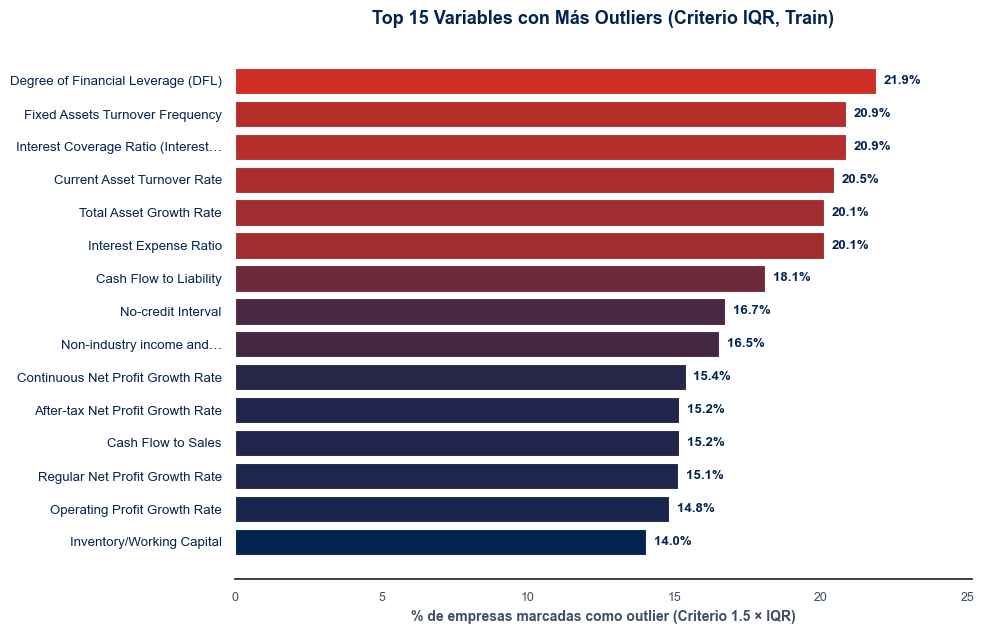

In [21]:
# 1. Función para calcular el porcentaje de outliers mediante IQR
def pct_outliers_iqr(serie):
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((serie < lower) | (serie > upper)).mean() * 100

outlier_pct = train_df[num_vars].apply(pct_outliers_iqr).sort_values(ascending=False)
top15 = outlier_pct.head(15)

df_top15_tabla = top15.reset_index()
df_top15_tabla.columns = ['Variable', '% Outliers (IQR)']

tabla_estilo(
    df_top15_tabla,
    formatos={'% Outliers (IQR)': '{:.2f}%'},
    titulo='Top 15 Variables con Mayor Proporción de Valores Atípicos'
)

# 2. Gráfico horizontal con degradado por severidad
fig, ax = plt.subplots(figsize=(10, 6.5), dpi=100)
fig.patch.set_facecolor('#FFFFFF')

cmap_custom = mcolors.LinearSegmentedColormap.from_list(
    'outlier_severity', [PALETTE['downriver'], PALETTE['poinciana']]
)
norm = plt.Normalize(top15.min(), top15.max())
colores = [cmap_custom(norm(v)) for v in top15.values]

bars = ax.barh(
    [textwrap.shorten(v, width=38, placeholder='…') for v in top15.index],
    top15.values, color=colores, edgecolor='#FFFFFF', linewidth=0.8
)
ax.invert_yaxis()

for bar, val in zip(bars, top15.values):
    ax.text(
        bar.get_width() + top15.max() * 0.012,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.1f}%', va='center', fontsize=9.5, fontweight='bold', color=PALETTE['downriver']
    )

ax.set_xlabel('% de empresas marcadas como outlier (Criterio 1.5 × IQR)', fontsize=10,
              fontweight='semibold', color=PALETTE['stone_blue'])
ax.set_title('Top 15 Variables con Más Outliers (Criterio IQR, Train)', fontsize=13,
             fontweight='bold', color=PALETTE['downriver'], pad=14)
ax.set_xlim(0, top15.max() * 1.15)
ax.tick_params(axis='x', colors=PALETTE['stone_blue'], labelsize=9)
ax.tick_params(axis='y', colors=PALETTE['downriver'], labelsize=9.5)

sns.despine(ax=ax, top=True, right=True, left=True, bottom=False)

plt.tight_layout()
plt.show()
plt.close(fig)


Las variables con mayor proporción de valores atípicos son **Degree of Financial Leverage (DFL)**, **Fixed Assets Turnover Frequency** e **Interest Coverage Ratio**, con aproximadamente 21,9 %, 20,9 % y 20,9 % de empresas marcadas como outliers, respectivamente.

También destacan **Current Asset Turnover Rate**, **Total Asset Growth Rate** e **Interest Expense Ratio**, con alrededor del 20 % de sus observaciones identificadas como valores atípicos. Las demás variables del top 15 presentan entre aproximadamente 14 % y 18 % de observaciones marcadas como outliers.

En general, varias variables presentan una proporción considerable de valores atípicos. Sin embargo, esto no significa que deban eliminarse automáticamente, ya que pueden representar situaciones financieras reales de algunas empresas. Estos resultados deberán considerarse posteriormente al definir el preprocesamiento de los datos.


## 5. ANÁLISIS BIVARIADO

#### 5.1 variables numéricas vs objetivo

##### Estadísticas descriptivas

In [22]:
# 1. TABLA CONSOLIDADA: las 93 variables en una sola tabla (en vez de 93 tablas
# individuales, una detrás de otra). Se ordena por correlación de Spearman
# absoluta con el target, para que las variables más relevantes aparezcan
# primero (ver justificación de Spearman al inicio de la sección 6).
corr_spearman_objetivo = train_df[num_vars + [TARGET]].corr(method='spearman')[TARGET].drop(TARGET)

filas_biv = []
for var in num_vars:
    grupo_0 = train_df.loc[train_df[TARGET] == 0, var].dropna()
    grupo_1 = train_df.loc[train_df[TARGET] == 1, var].dropna()
    filas_biv.append({
        'Variable': var,
        'Correlación Spearman (r)': corr_spearman_objetivo[var],
        'Media (No quiebra)': grupo_0.mean(),
        'Media (Quiebra)': grupo_1.mean(),
        'Mediana (No quiebra)': grupo_0.median(),
        'Mediana (Quiebra)': grupo_1.median(),
    })

df_bivariado_todas = pd.DataFrame(filas_biv)
df_bivariado_todas['abs_r'] = df_bivariado_todas['Correlación Spearman (r)'].abs()
df_bivariado_todas = df_bivariado_todas.sort_values('abs_r', ascending=False).drop(columns='abs_r')

tabla_estilo_scroll(df_bivariado_todas, formatos={
    'Correlación Spearman (r)': '{:+.3f}',
    'Media (No quiebra)': '{:.4f}',
    'Media (Quiebra)': '{:.4f}',
    'Mediana (No quiebra)': '{:.4f}',
    'Mediana (Quiebra)': '{:.4f}',
}, titulo='Comparación Bivariada de las 93 Variables vs. Bankrupt? (ordenadas por relevancia)', alto_px=420)

# 2. DEEP DIVE: tabla + interpretación completa solo para las variables clave
display(HTML(f"<h4 style='color:{PALETTE['downriver']}; font-family:Segoe UI, sans-serif; "
             f"margin-top:20px;'>Análisis bivariado detallado de variables clave</h4>"))

for var in variables_key:
    stats_list = []
    for val in sorted(train_df[TARGET].unique()):
        grupo = train_df[train_df[TARGET] == val][var].dropna()
        stats_list.append({
            'Estado Financiero': f'Clase {val} ({"Solvente" if val == 0 else "Quiebra"})',
            'N': len(grupo),
            'Media': grupo.mean(),
            'DS': grupo.std(),
            'Mediana': grupo.median(),
            'Mínimo': grupo.min(),
            'Máximo': grupo.max(),
            'Q1': grupo.quantile(0.25),
            'Q3': grupo.quantile(0.75),
            'IQR': grupo.quantile(0.75) - grupo.quantile(0.25),
        })

    df_bivariado = pd.DataFrame(stats_list)

    tabla_estilo(df_bivariado, formatos={
        'N': '{:,.0f}', 'Media': '{:.4f}', 'DS': '{:.4f}', 'Mediana': '{:.4f}',
        'Mínimo': '{:.4f}', 'Máximo': '{:.4f}', 'Q1': '{:.4f}', 'Q3': '{:.4f}', 'IQR': '{:.4f}',
    }, titulo=f"Tabla Descriptiva Bivariada: {var} vs {TARGET}")

    row_0, row_1 = df_bivariado.iloc[0], df_bivariado.iloc[1]
    m_0, m_1 = row_0['Media'], row_1['Media']
    med_0, med_1 = row_0['Mediana'], row_1['Mediana']
    diff_media = m_1 - m_0

    if abs(diff_media) < 1e-4:
        tendencia = "no presenta diferencias sustanciales entre ambos grupos, sugiriendo un poder discriminante limitado de forma univariada."
        color_borde = PALETTE['stone_blue']
    elif diff_media < 0:
        tendencia = (f"muestra una tendencia a registrar <b style='color:{PALETTE['poinciana']};'>valores inferiores "
                     f"en empresas en quiebra</b> (Media = {m_1:.4f}, Mediana = {med_1:.4f}) frente a empresas "
                     f"solventes (Media = {m_0:.4f}, Mediana = {med_0:.4f}).")
        color_borde = PALETTE['poinciana']
    else:
        tendencia = (f"muestra una tendencia a registrar <b style='color:{PALETTE['flame']};'>valores superiores "
                     f"en empresas en quiebra</b> (Media = {m_1:.4f}, Mediana = {med_1:.4f}) frente a empresas "
                     f"solventes (Media = {m_0:.4f}, Mediana = {med_0:.4f}).")
        color_borde = PALETTE['flame']

    tarjeta_interpretacion(
        f"Interpretación Bivariada: {var}",
        f"Al segmentar la variable <b style='color:{PALETTE['downriver']};'>{var}</b> según la condición de "
        f"insolvencia (<code>{TARGET}</code>), se observa que la distribución {tendencia} Esta diferencia entre "
        f"los centros de tendencia central es un indicador clave para anticipar la importancia de esta variable "
        f"dentro de los modelos de clasificación.",
        color_borde=color_borde
    )


Variable,Correlación Spearman (r),Media (No quiebra),Media (Quiebra),Mediana (No quiebra),Mediana (Quiebra)
Persistent EPS in the Last Four Seasons,-0.236,0.2296,0.1897,0.2249,0.1967
Net Income to Total Assets,-0.232,0.8097,0.7382,0.8112,0.7664
Net profit before tax/Paid-in capital,-0.230,0.1834,0.1486,0.1787,0.1540
Per Share Net profit before tax (Yuan ¥),-0.229,0.1849,0.1486,0.1799,0.1553
Continuous interest rate (after tax),-0.228,0.7815,0.7809,0.7816,0.7814
Retained Earnings to Total Assets,-0.227,0.9355,0.9039,0.9379,0.9137
Total debt/Total net worth,+0.223,1713392.6952,19715909.1200,0.0054,0.0158
Net Income to Stockholder's Equity,-0.223,0.8409,0.8282,0.8412,0.8367
Total income/Total expense,-0.222,0.0026,0.0021,0.0023,0.0021
Borrowing dependency,+0.222,0.3742,0.3901,0.3725,0.3828


Estado Financiero,N,Media,DS,Mediana,Mínimo,Máximo,Q1,Q3,IQR
Clase 0 (Solvente),"5,279",0.5073,0.0571,0.5038,0.0828,1.0000,0.4786,0.5359,0.0573
Clase 1 (Quiebra),176,0.4176,0.0852,0.4413,0.0243,0.5770,0.3928,0.4699,0.0771


Estado Financiero,N,Media,DS,Mediana,Mínimo,Máximo,Q1,Q3,IQR
Clase 0 (Solvente),"5,279",0.1910,0.0311,0.1847,0.0000,0.5492,0.1742,0.1995,0.0254
Clase 1 (Quiebra),176,0.1605,0.0193,0.1583,0.0697,0.2176,0.1484,0.1748,0.0264


Estado Financiero,N,Media,DS,Mediana,Mínimo,Máximo,Q1,Q3,IQR
Clase 0 (Solvente),"5,279",0.0153,0.0235,0.0108,0.0000,1.0000,0.0076,0.0167,0.0090
Clase 1 (Quiebra),176,0.0074,0.0099,0.0061,0.0004,0.1078,0.0041,0.0080,0.0040


Estado Financiero,N,Media,DS,Mediana,Mínimo,Máximo,Q1,Q3,IQR
Clase 0 (Solvente),"5,279",0.1108,0.0525,0.1095,0.0000,1.0000,0.0716,0.1458,0.0743
Clase 1 (Quiebra),176,0.1868,0.0546,0.1875,0.0011,0.5254,0.1620,0.2143,0.0523


Estado Financiero,N,Media,DS,Mediana,Mínimo,Máximo,Q1,Q3,IQR
Clase 0 (Solvente),"5,279",0.1426,0.0995,0.1214,0.0000,1.0000,0.0780,0.1784,0.1004
Clase 1 (Quiebra),176,0.1063,0.0864,0.0840,0.0015,0.6297,0.0521,0.1323,0.0802


Estado Financiero,N,Media,DS,Mediana,Mínimo,Máximo,Q1,Q3,IQR
Clase 0 (Solvente),"5,279",0.3742,0.0102,0.3725,0.1871,0.8874,0.3701,0.3759,0.0058
Clase 1 (Quiebra),176,0.3901,0.0548,0.3828,0.2620,0.9548,0.3787,0.3892,0.0105


##### Gráficas

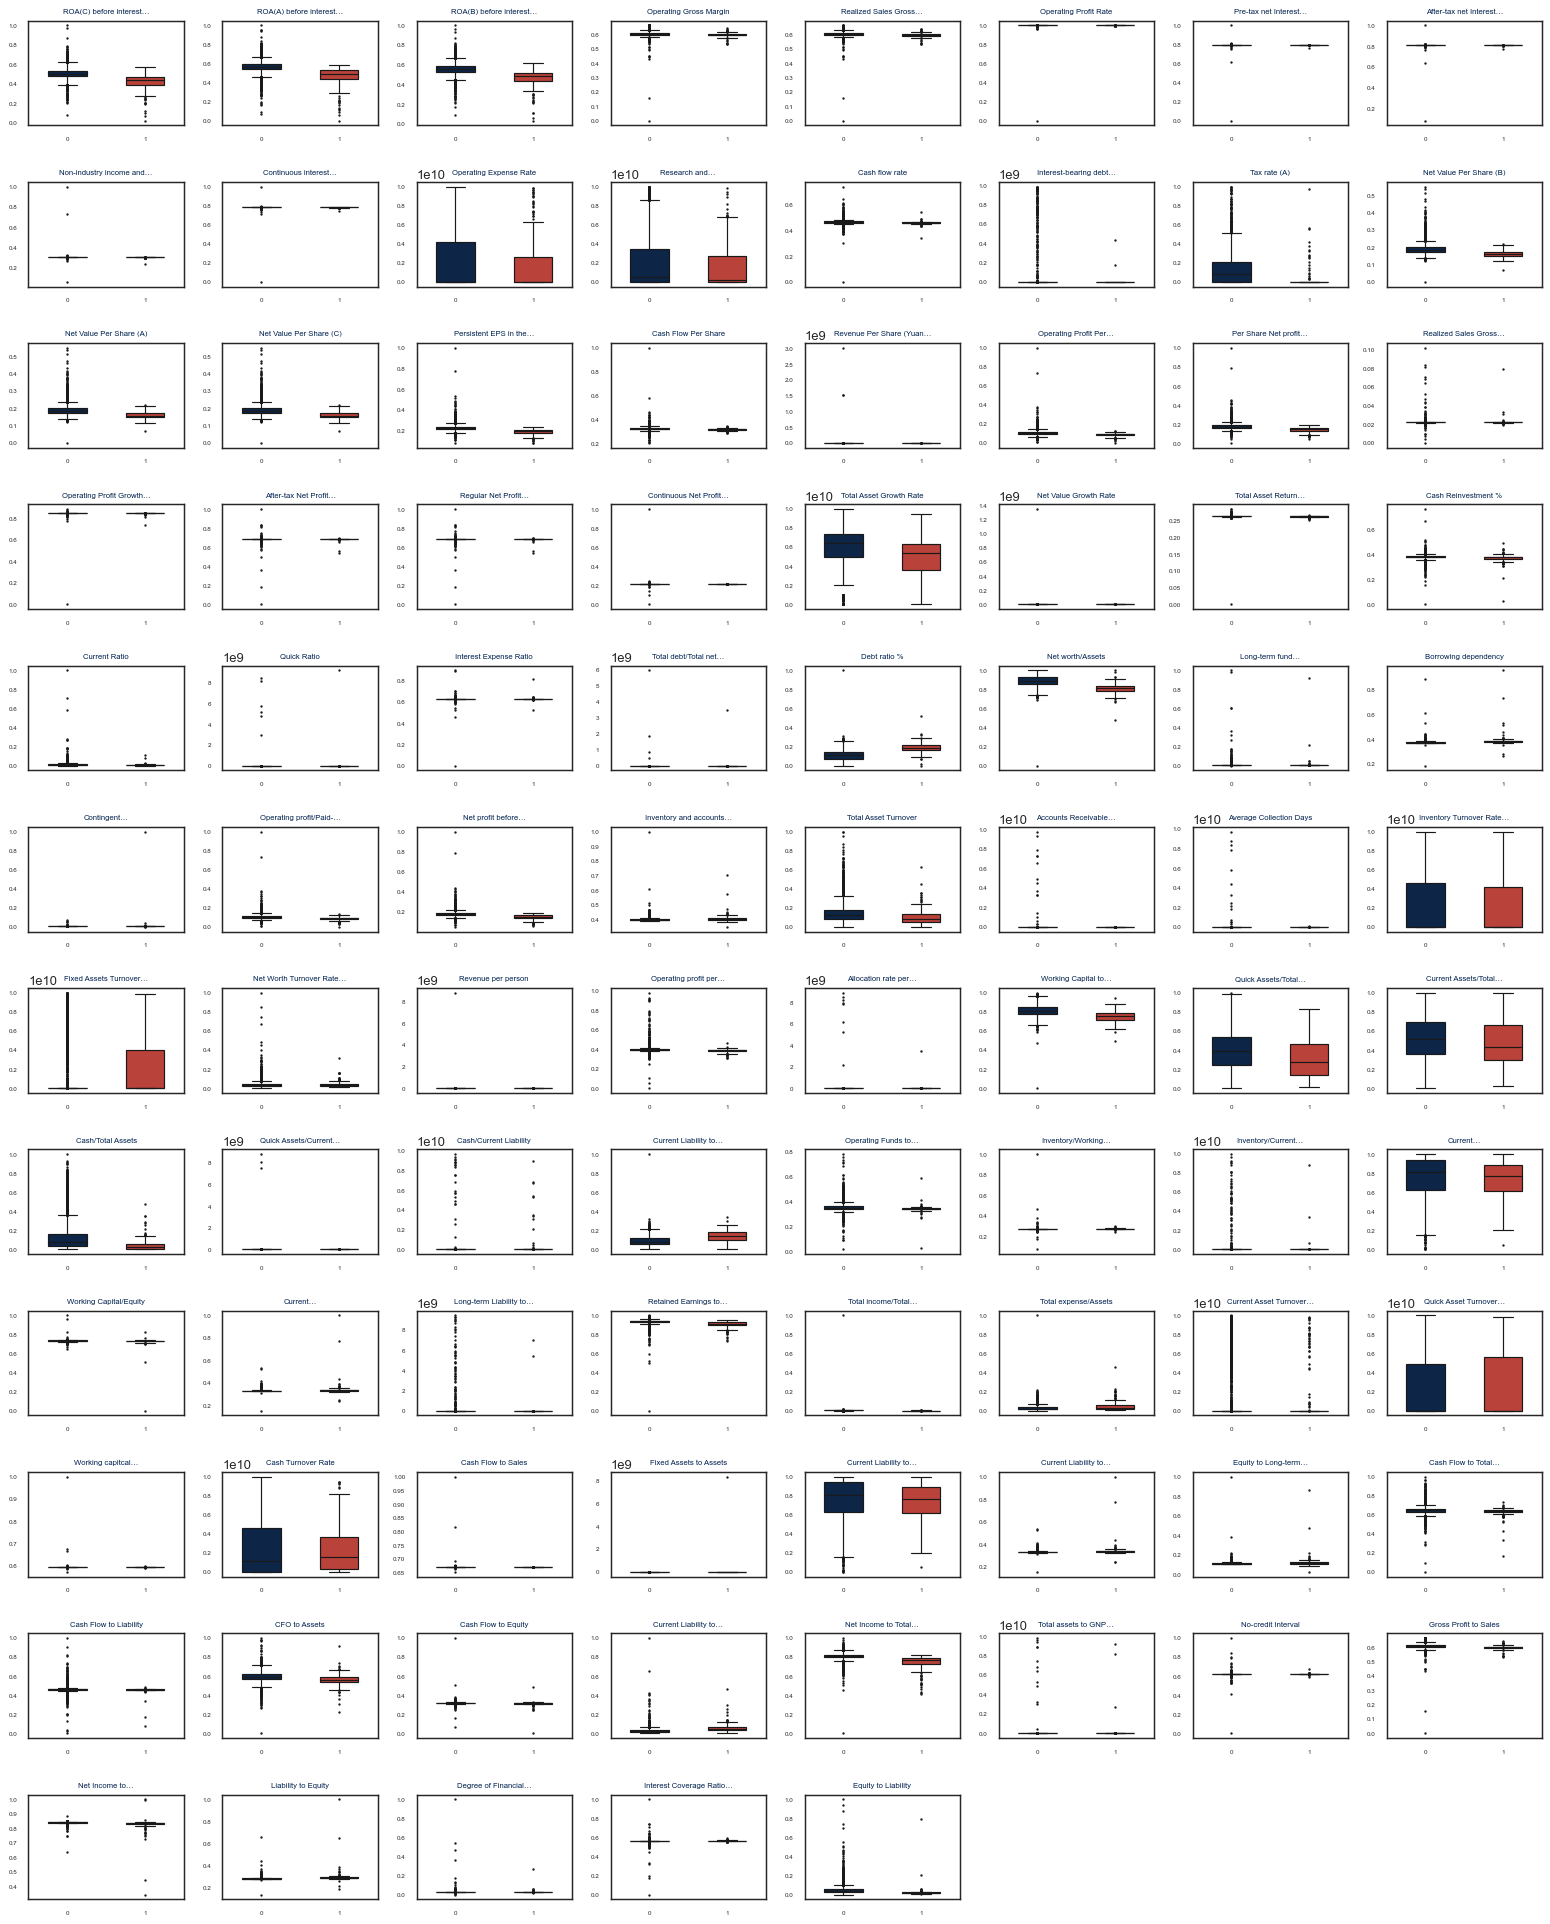

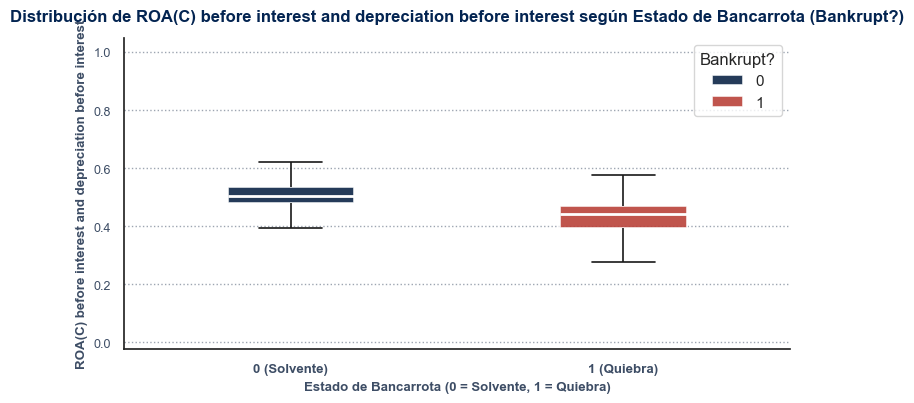

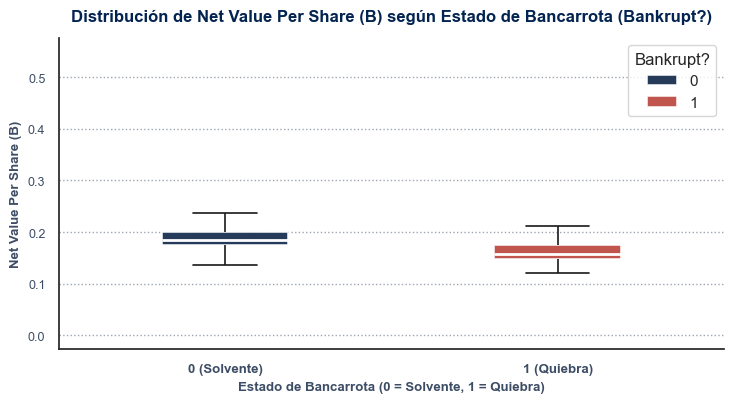

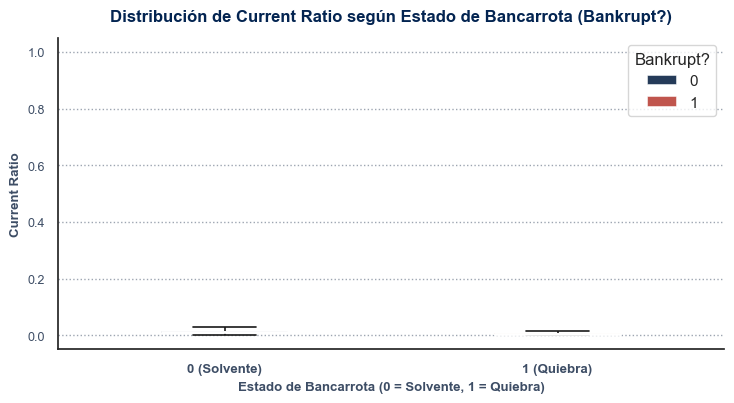

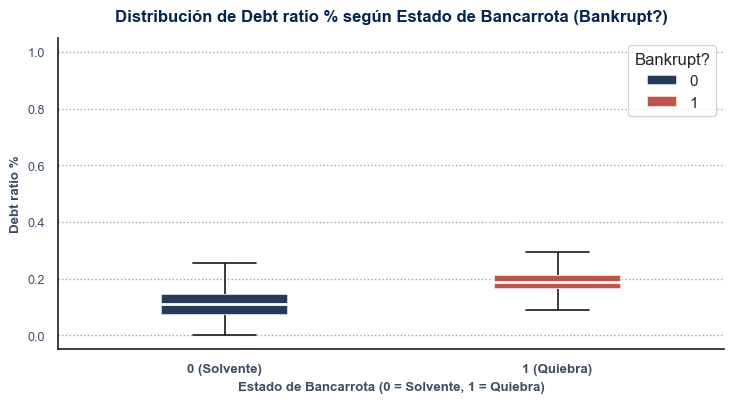

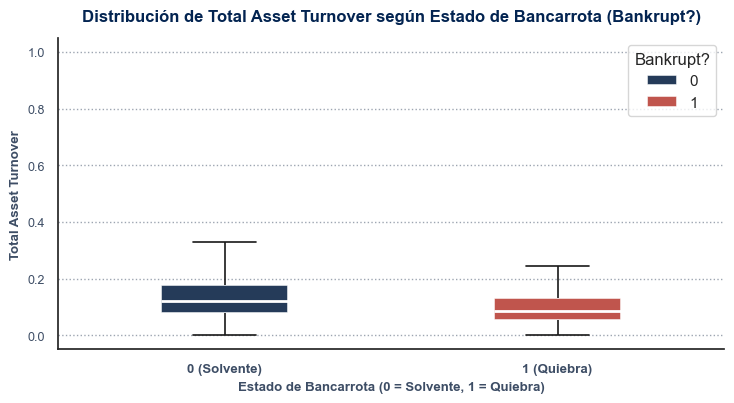

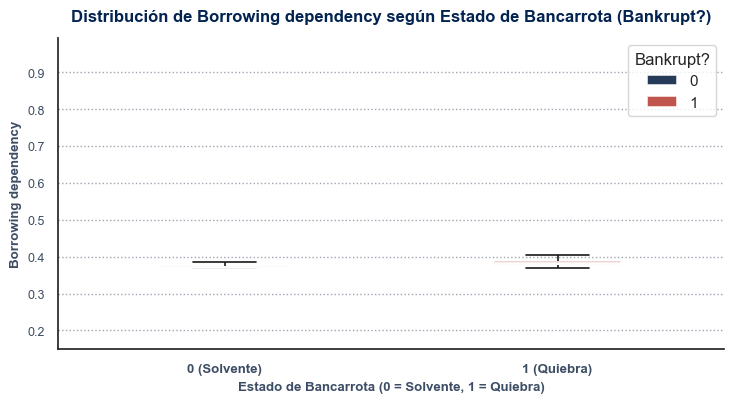

In [23]:
# 1. PANORAMA: boxplot de las 93 variables vs. el target, de un vistazo.
display(HTML(f"<h4 style='color:{PALETTE['downriver']}; font-family:Segoe UI, sans-serif;'>"
             f"Panorama: las 93 variables numéricas vs. {TARGET}</h4>"))
grid_variables(num_vars, tipo='box', target=TARGET)

# 2. DEEP DIVE: boxplot completo + interpretación solo para variables clave
display(HTML(f"<h4 style='color:{PALETTE['downriver']}; font-family:Segoe UI, sans-serif; "
             f"margin-top:20px;'>Boxplots detallados de variables clave</h4>"))

TARGET_COLORS_LIST = [PALETTE['downriver'], PALETTE['poinciana']]

for var in variables_key:
    fig, ax = plt.subplots(figsize=(7.5, 4.2), dpi=100)
    fig.patch.set_facecolor('#FFFFFF')

    sns.boxplot(
        data=train_df, x=TARGET, y=var, hue=TARGET, palette=TARGET_COLORS_LIST, ax=ax, width=0.38,
        boxprops=dict(edgecolor='#FFFFFF', linewidth=1.2, alpha=0.9),
        medianprops=dict(color='#FFFFFF', linewidth=2.0),
        whiskerprops=dict(linewidth=1.2), capprops=dict(linewidth=1.2),
        flierprops=dict(marker='o', markersize=3.5, alpha=0.5, markeredgecolor='none')
    )

    ax.set_title(f'Distribución de {var} según Estado de Bancarrota ({TARGET})', fontsize=12,
                 fontweight='bold', color=PALETTE['downriver'], pad=12)
    ax.set_xlabel('Estado de Bancarrota (0 = Solvente, 1 = Quiebra)', fontsize=9.5,
                  fontweight='semibold', color=PALETTE['stone_blue'])
    ax.set_ylabel(var, fontsize=9.5, fontweight='semibold', color=PALETTE['stone_blue'])
    ax.tick_params(colors=PALETTE['stone_blue'], labelsize=9)
    ax.set_xticklabels(['0 (Solvente)', '1 (Quiebra)'], fontsize=9.5, fontweight='bold')

    sns.despine(top=True, right=True, left=False, bottom=False)
    ax.grid(axis='y', linestyle=':', alpha=0.5, color=PALETTE['stone_blue'])

    plt.tight_layout()
    plt.show()
    plt.close(fig)

    grupo_0 = train_df[train_df[TARGET] == 0][var].dropna()
    grupo_1 = train_df[train_df[TARGET] == 1][var].dropna()
    med_0, med_1 = grupo_0.median(), grupo_1.median()
    diff_mediana = med_1 - med_0

    if abs(diff_mediana) < 0.01:
        comparacion_mediana = "medianas visualmente alineadas y un solapamiento alto en sus rangos intercuartílicos"
        conclusion = f"la variable <b style='color:{PALETTE['downriver']};'>{var}</b> muestra un comportamiento similar entre ambos grupos sin una separación clara a simple vista."
        color_borde = PALETTE['stone_blue']
    elif diff_mediana < 0:
        comparacion_mediana = (f"que el 50% de las empresas en quiebra se ubica en niveles inferiores de "
                                f"<b style='color:{PALETTE['poinciana']};'>{var}</b> (mediana cercana a {med_1:.4f}) "
                                f"en comparación con el grupo solvente (mediana cercana a {med_0:.4f})")
        conclusion = f"los valores más bajos de <b style='color:{PALETTE['poinciana']};'>{var}</b> tienden a concentrarse en las empresas con riesgo de quiebra."
        color_borde = PALETTE['poinciana']
    else:
        comparacion_mediana = (f"que el 50% de las empresas en quiebra presenta valores más elevados de "
                                f"<b style='color:{PALETTE['flame']};'>{var}</b> (mediana cercana a {med_1:.4f}) "
                                f"frente al grupo sano (mediana cercana a {med_0:.4f})")
        conclusion = f"los valores más altos de <b style='color:{PALETTE['flame']};'>{var}</b> se aprecian con mayor frecuencia en el grupo con riesgo de quiebra."
        color_borde = PALETTE['flame']

    tarjeta_interpretacion(
        f"Interpretación de {var} vs {TARGET}",
        f"El gráfico compara la distribución de <b style='color:{PALETTE['downriver']};'>{var}</b> entre empresas "
        f"solventes (<b style='color:{PALETTE['downriver']};'>0</b>) y en quiebra "
        f"(<b style='color:{PALETTE['poinciana']};'>1</b>). Se observa {comparacion_mediana}. El rango central de "
        f"los datos (IQR) muestra la dispersión interna de cada segmento, evidenciándose la presencia de valores "
        f"atípicos (<i>outliers</i>) más allá de los bigotes. En resumen, {conclusion}",
        color_borde=color_borde
    )


##### Inferencia estadística: variables numéricas vs. objetivo

El análisis descriptivo y los boxplots anteriores sugieren diferencias entre empresas solventes y quebradas, pero no permiten determinar si esas diferencias son compatibles con la variabilidad muestral. La **inferencia estadística** contrasta dos explicaciones para cada ratio financiero:

- **H₀:** la distribución del ratio es la misma en empresas que no quiebran y en empresas que sí quiebran.
- **H₁:** la distribución del ratio difiere entre ambos estados de bancarrota.

Las hipótesis se particularizan automáticamente para cada variable en la tabla de resultados. Se utiliza $\alpha=0.05$: este umbral representa el riesgo máximo de error tipo I que se admite para una prueba individual. El *p-value* es la probabilidad, suponiendo verdadera H₀, de observar un resultado al menos tan extremo como el obtenido. Si $p<\alpha$, se rechaza H₀; si $p\geq\alpha$, **no se rechaza H₀**. No rechazarla no demuestra igualdad, sino falta de evidencia suficiente.

**Selección de la prueba**

El objetivo `Bankrupt?` es categórico binario e independiente de cada ratio numérico. Por ello se comparan dos grupos independientes (0 = no quiebra; 1 = quiebra). Antes de elegir la prueba se evalúan:

| Condición | Comprobación | Decisión que permite tomar |
|---|---|---|
| Normalidad aproximada | Shapiro–Wilk por grupo, junto con asimetría y outliers | Si ambos grupos fueran razonablemente normales, podría utilizarse una prueba t. Shapiro se limita a 5.000 observaciones en el grupo mayor para respetar su rango recomendado y evitar que el tamaño muestral domine aún más la decisión. |
| Homogeneidad de varianzas | Levene centrada en la mediana | Con normalidad razonable: t de Student si no se rechaza igualdad de varianzas; t de Welch si se rechaza. |
| Distribuciones no normales o con outliers relevantes | Evidencia conjunta de Shapiro, asimetría y regla IQR | Mann–Whitney U bilateral, que trabaja con rangos y es menos sensible a valores extremos. |
| Independencia | Una fila debe representar una empresa distinta | Es un supuesto del diseño; no puede demostrarse con estas pruebas y debe verificarse con la procedencia de los datos. |

En estos datos, las 93 variables incumplen la normalidad razonable en al menos uno de los grupos y el EDA ya documentó asimetrías y outliers importantes. En consecuencia, se selecciona **Mann–Whitney U bilateral** para todas. Esta prueba evalúa igualdad de distribuciones (o dominancia estocástica); solo puede interpretarse estrictamente como diferencia de medianas cuando las distribuciones tienen formas comparables.

Como tamaño de efecto se presenta la **correlación biserial de rangos** $r_{rb}$, entre -1 y 1. Aquí, valores positivos indican que el ratio tiende a ser mayor en empresas sin quiebra y valores negativos, mayor en empresas quebradas. Como guía descriptiva: $|r_{rb}|\approx0.10$ pequeño, $0.30$ moderado y $0.50$ grande. La magnitud debe interpretarse junto con el contexto financiero; significancia estadística no equivale necesariamente a importancia práctica.

In [24]:
# Importaciones nuevas necesarias únicamente para la inferencia
from scipy.stats import shapiro, levene, mannwhitneyu

ALPHA = 0.05
resultados_inferencia_num = []

for var in num_vars:
    grupo_0 = train_df.loc[train_df[TARGET] == 0, var].dropna()
    grupo_1 = train_df.loc[train_df[TARGET] == 1, var].dropna()

    # Shapiro–Wilk: máximo 5.000 datos en el grupo mayor, con muestra reproducible.
    muestra_0 = grupo_0.sample(min(len(grupo_0), 5000), random_state=RANDOM_STATE)
    p_shapiro_0 = shapiro(muestra_0).pvalue
    p_shapiro_1 = shapiro(grupo_1).pvalue

    # Levene se informa como diagnóstico; solo decidiría entre Student y Welch
    # si hubiera normalidad razonable en ambos grupos.
    p_levene = levene(grupo_0, grupo_1, center='median').pvalue

    # La decisión no depende únicamente de Shapiro: incorpora forma y outliers.
    sesgo_0, sesgo_1 = grupo_0.skew(), grupo_1.skew()
    pct_out_0 = pct_outliers_iqr(grupo_0)
    pct_out_1 = pct_outliers_iqr(grupo_1)
    normalidad_razonable = (
        p_shapiro_0 >= ALPHA and p_shapiro_1 >= ALPHA
        and abs(sesgo_0) <= 1 and abs(sesgo_1) <= 1
        and max(pct_out_0, pct_out_1) <= 5
    )

    # En los datos reales todas las variables incumplen el criterio anterior.
    prueba = mannwhitneyu(grupo_0, grupo_1, alternative='two-sided', method='asymptotic')
    r_biserial = 2 * prueba.statistic / (len(grupo_0) * len(grupo_1)) - 1

    resultados_inferencia_num.append({
        'Variable': var,
        'H₀': f'La distribución de {var} es igual en empresas sin y con quiebra.',
        'H₁': f'La distribución de {var} difiere entre empresas sin y con quiebra.',
        'Prueba seleccionada': 'Mann–Whitney U',
        'Motivo': 'No normalidad y/o asimetría-outliers en al menos un grupo',
        'N (0)': len(grupo_0),
        'N (1)': len(grupo_1),
        'Mediana (0)': grupo_0.median(),
        'Mediana (1)': grupo_1.median(),
        'p Shapiro (0)': p_shapiro_0,
        'p Shapiro (1)': p_shapiro_1,
        'p Levene': p_levene,
        'Normalidad razonable': normalidad_razonable,
        'U': prueba.statistic,
        'p-value': prueba.pvalue,
        'r biserial': r_biserial
    })

resultados_inferencia_num = pd.DataFrame(resultados_inferencia_num)

# Holm controla el error familiar entre las 93 pruebas y es menos conservadora
# que Bonferroni sin perder dicho control.
# Implementación directa de Holm para no añadir una dependencia de statsmodels.
p_values = resultados_inferencia_num['p-value'].to_numpy()
orden = np.argsort(p_values)
m = len(p_values)

# En el orden ascendente, Holm multiplica cada p-value por el número de
# hipótesis que todavía quedan y fuerza que los valores ajustados no disminuyan.
p_ordenados_ajustados = np.maximum.accumulate(
    (m - np.arange(m)) * p_values[orden]
)
p_ordenados_ajustados = np.minimum(p_ordenados_ajustados, 1.0)

p_ajustados_holm = np.empty(m)
p_ajustados_holm[orden] = p_ordenados_ajustados
resultados_inferencia_num['p ajustado (Holm)'] = p_ajustados_holm
resultados_inferencia_num['Decisión'] = np.where(
    resultados_inferencia_num['p ajustado (Holm)'] < ALPHA,
    'Se rechaza H₀',
    'No se rechaza H₀'
)

display(resultados_inferencia_num[[
    'Variable', 'Prueba seleccionada', 'N (0)', 'N (1)',
    'Mediana (0)', 'Mediana (1)', 'U', 'p-value',
    'p ajustado (Holm)', 'r biserial', 'Decisión'
]].sort_values('p ajustado (Holm)').style.format({
    'Mediana (0)': '{:.6g}', 'Mediana (1)': '{:.6g}', 'U': '{:,.1f}',
    'p-value': '{:.3e}', 'p ajustado (Holm)': '{:.3e}', 'r biserial': '{:.3f}'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#1B4F72'),
                                  ('color', 'white'), ('font-weight', 'bold')]}
]))

print(f"Variables evaluadas: {len(resultados_inferencia_num)}")
print(f"Con evidencia después de Holm: {(resultados_inferencia_num['Decisión'] == 'Se rechaza H₀').sum()}")
print(f"Sin evidencia suficiente después de Holm: {(resultados_inferencia_num['Decisión'] == 'No se rechaza H₀').sum()}")

,Variable,Prueba seleccionada,N (0),N (1),Mediana (0),Mediana (1),U,p-value,p ajustado (Holm),r biserial,Decisión
18,Persistent EPS in the Last Four Seasons,Mann–Whitney U,5279,176,0.224922,0.196653,"822,863.0",4.604e-68,4.282e-66,0.771,Se rechaza H₀
84,Net Income to Total Assets,Mann–Whitney U,5279,176,0.811231,0.766434,"816,206.0",1.262e-65,1.161e-63,0.757,Se rechaza H₀
42,Net profit before tax/Paid-in capital,Mann–Whitney U,5279,176,0.178742,0.154012,"813,431.5",1.269e-64,1.155e-62,0.751,Se rechaza H₀
22,Per Share Net profit before tax (Yuan ¥),Mann–Whitney U,5279,176,0.179935,0.155344,"812,791.0",2.156e-64,1.940e-62,0.750,Se rechaza H₀
9,Continuous interest rate (after tax),Mann–Whitney U,5279,176,0.781638,0.781351,"810,308.5",1.669e-63,1.485e-61,0.744,Se rechaza H₀
67,Retained Earnings to Total Assets,Mann–Whitney U,5279,176,0.937904,0.913652,"809,723.0",2.699e-63,2.375e-61,0.743,Se rechaza H₀
35,Total debt/Total net worth,Mann–Whitney U,5279,176,0.00537849,0.0158086,"125,954.5",5.623e-61,4.892e-59,-0.729,Se rechaza H₀
88,Net Income to Stockholder's Equity,Mann–Whitney U,5279,176,0.841206,0.836695,"802,314.0",1.100e-60,9.462e-59,0.727,Se rechaza H₀
68,Total income/Total expense,Mann–Whitney U,5279,176,0.00234067,0.00205967,"801,870.0",1.571e-60,1.335e-58,0.726,Se rechaza H₀
39,Borrowing dependency,Mann–Whitney U,5279,176,0.372473,0.382765,"128,439.5",2.204e-60,1.851e-58,-0.724,Se rechaza H₀


Variables evaluadas: 93
Con evidencia después de Holm: 81
Sin evidencia suficiente después de Holm: 12


In [25]:
# Interpretación específica y reproducible para cada variable
for _, fila in resultados_inferencia_num.sort_values('p ajustado (Holm)').iterrows():
    direccion = (
        'tiende a presentar valores mayores en las empresas que no quebraron'
        if fila['r biserial'] > 0 else
        'tiende a presentar valores mayores en las empresas que quebraron'
    )
    magnitud_abs = abs(fila['r biserial'])
    magnitud = ('grande' if magnitud_abs >= 0.50 else
                'moderada' if magnitud_abs >= 0.30 else
                'pequeña' if magnitud_abs >= 0.10 else 'muy pequeña')

    if fila['Decisión'] == 'Se rechaza H₀':
        conclusion = (
            f"Se rechaza H₀ después de la corrección de Holm. Hay evidencia estadística "
            f"de que la distribución de <b>{fila['Variable']}</b> difiere según el estado "
            f"de bancarrota; el ratio {direccion}."
        )
    else:
        conclusion = (
            f"No se rechaza H₀ después de la corrección de Holm. La muestra no aporta "
            f"evidencia suficiente de una diferencia en la distribución de "
            f"<b>{fila['Variable']}</b> entre ambos estados. Esto no demuestra igualdad."
        )

    display(HTML(f"""
    <div style="background-color:#f8f9fa; border-left:4px solid #1B4F72;
                padding:10px; margin-bottom:14px;">
      <b>{fila['Variable']}</b><br>
      Se aplicó Mann–Whitney U bilateral (U = {fila['U']:,.1f},
      p = {fila['p-value']:.3e}, p ajustado de Holm = {fila['p ajustado (Holm)']:.3e}).
      Las medianas fueron {fila['Mediana (0)']:.6g} para no quiebra y
      {fila['Mediana (1)']:.6g} para quiebra. {conclusion}
      El tamaño de efecto fue {fila['r biserial']:.3f} (magnitud {magnitud}).
      Este resultado describe asociación, no causalidad, y la relevancia práctica debe
      valorarse junto con el significado financiero y la capacidad predictiva fuera de muestra.
    </div>
    """))

#### 5.2 Variables categóricas vs. objetivo

##### Tabla

In [26]:
for var in cat_vars:
    # 1. Tabla de Frecuencias Absolutas (N)
    tabla_n = pd.crosstab(
        train_df[var], 
        train_df[TARGET], 
        margins=True, 
        margins_name='Total'
    )
    
    # 2. Tabla de Porcentajes sobre el total de cada categoría/fila (%)
    tabla_pct_fila = pd.crosstab(
        train_df[var], 
        train_df[TARGET], 
        normalize='index'
    ) * 100
    
    # Construcción de la tabla combinada N (%)
    tabla_combinada = tabla_n.copy().astype(object)
    
    for row in tabla_pct_fila.index:
        for col in tabla_pct_fila.columns:
            n_val = tabla_n.loc[row, col]
            pct_val = tabla_pct_fila.loc[row, col]
            tabla_combinada.loc[row, col] = f"{n_val:,.0f} ({pct_val:.2f}%)"
            
    # Formatear totales generales
    total_general = len(train_df)
    for row in tabla_n.index:
        n_total_row = tabla_n.loc[row, 'Total']
        pct_total_row = (n_total_row / total_general) * 100
        tabla_combinada.loc[row, 'Total'] = f"{n_total_row:,.0f} ({pct_total_row:.2f}%)"
    
    # Renombrar columnas para claridad visual
    tabla_combinada.columns = ['No Quiebra (0)', 'Sí Quiebra (1)', 'Total Fila']
    tabla_combinada.index.name = f'Categoría: {var}'
    
    print(f"\n TABLA DE CONTINGENCIA: {var} vs {TARGET} ")
    display(tabla_combinada.style.set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#1B4F72'), ('color', 'white'), ('font-weight', 'bold')]}
    ]))


 TABLA DE CONTINGENCIA: Liability-Assets Flag vs Bankrupt? 


,No Quiebra (0),Sí Quiebra (1),Total Fila
Categoría: Liability-Assets Flag,,,
0,"5,277 (96.83%)",173 (3.17%),"5,450 (99.91%)"
1,2 (40.00%),3 (60.00%),5 (0.09%)
Total,5279,176,"5,455 (100.00%)"



 TABLA DE CONTINGENCIA: Net Income Flag vs Bankrupt? 


,No Quiebra (0),Sí Quiebra (1),Total Fila
Categoría: Net Income Flag,,,
1,"5,279 (96.77%)",176 (3.23%),"5,455 (100.00%)"
Total,5279,176,"5,455 (100.00%)"


> `Liability-Assets Flag` vs `Bankrupt?`
> Esta tabla permite analizar la relación entre el indicador de alerta de pasivos y la condición final de quiebra de las empresas:
> - Empresas sin alerta de pasivos (Valor 0): Representan casi la totalidad de la muestra analizada. Dentro de este grupo, el 96.7% de las firmas se mantiene financieramente estable (sin quiebra), mientras que solo un 3.3% llegó a la insolvencia.
> - Empresas con alerta de pasivos superiores a activos (Valor 1): Es un segmento de datos sumamente reducido. La proporción de quiebras en este grupo no muestra un incremento determinante frente a la categoría anterior, lo que indica que esta bandera por sí sola no genera un salto abrupto en el riesgo de bancarrota.
> 
> La gran mayoría de los eventos de quiebra suceden en firmas que no tenían activa esta alerta. Por lo tanto, contar con esta marca activada no constituye un factor discriminante fuerte por sí solo para anticipar la quiebra.

>`Net Income Flag` vs `Bankrupt?` El análisis de esta tabla pone en evidencia una característica estructural del indicador:
> - Uniformidad en los registros (Valor 1): El 100% de las empresas del conjunto de entrenamiento está clasificado dentro de un único valor (1).
> - Sin capacidad de comparación: Al no existir observaciones registradas en la categoría alternativa (0), resulta imposible establecer una comparación entre grupos para evaluar si el indicador influye en la probabilidad de insolvencia.
> 
> Esta variable carece de variabilidad (varianza cero), por lo que no aporta información predictiva ni explicativa para diferenciar empresas sanas de insolventes. Se sugiere descartarla formalmente durante la fase de preprocesamiento.

##### Gráficas

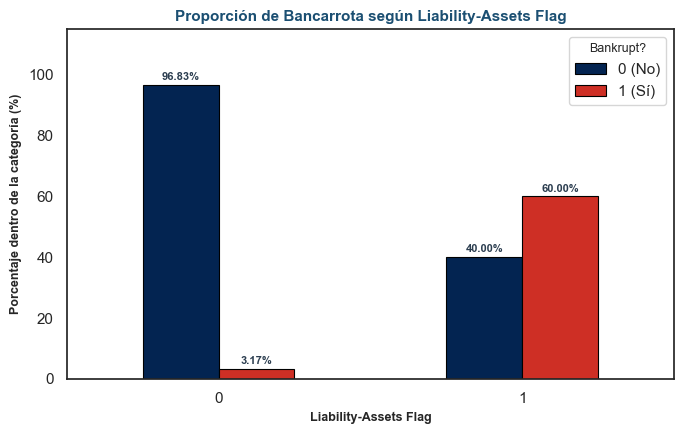

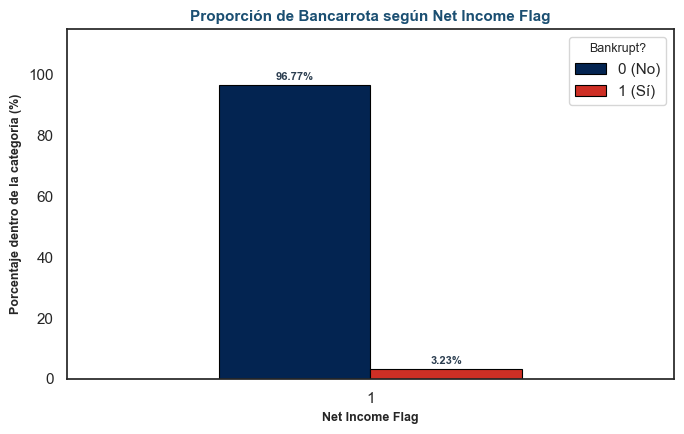

In [27]:
for var in cat_vars:
    # Generar la tabla cruzada en porcentajes relativos por categoría (filas)
    crosstab_pct = pd.crosstab(train_df[var], train_df[TARGET], normalize='index') * 100
    
    # Graficar barras agrupadas
    fig, ax = plt.subplots(figsize=(7, 4.5))
    
    crosstab_pct.plot(
        kind='bar',
        stacked=False,
        color=[TARGET_COLORS[0], TARGET_COLORS[1]],
        ax=ax,
        edgecolor='black',
        linewidth=0.8
    )
    
    ax.set_title(f'Proporción de Bancarrota según {var}', fontsize=11, fontweight='bold', color='#1B4F72')
    ax.set_xlabel(var, fontsize=9, fontweight='bold')
    ax.set_ylabel('Porcentaje dentro de la categoría (%)', fontsize=9, fontweight='bold')
    ax.legend(title='Bankrupt?', labels=['0 (No)', '1 (Sí)'], title_fontsize='9', loc='upper right')
    plt.xticks(rotation=0)
    
    # Etiquetar las barras con el porcentaje exacto
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(
                f'{height:.2f}%',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                fontsize=8, fontweight='bold', color='#2C3E50',
                xytext=(0, 2), textcoords='offset points'
            )
            
    ax.set_ylim(0, 115) # Espacio para las etiquetas
    plt.tight_layout()
    plt.show()
    plt.close(fig)

> **Interpretación de `Liability-Assets Flag` vs `Bankrupt?` :**
El gráfico para Liability-Assets Flag muestra la tasa de bancarrota según si los pasivos de la empresa superan a sus activos (1) o no (0). En ambos casos, la inmensa mayoría de las empresas son solventes (0), lo que refleja el fuerte desbalance de la variable objetivo. Aunque se esperaría lo contrario, tener más pasivos que activos muestra un impacto prácticamente nulo en la tasa de insolvencia de la muestra. Sumado a que muy pocas observaciones presentan este indicador en 1, la variable aporta muy poca capacidad discriminante por sí sola.

> **Interpretación de `Net Income Flag` vs `Bankrupt?` :**
El gráfico para Net Income Flag refleja una distribución idéntica para todas las observaciones del conjunto de datos, ya que el 100% de las empresas se encuentran clasificado bajo el valor único 1. Al no existir variación entre las categorías de esta variable frente al estado de bancarrota (los casos 0 y 1 del target se distribuyen sobre un solo nivel), la variable carece totalmente de poder explicativo o discriminante, confirmando la necesidad de descartarla antes de la fase de modelado predictivo.

##### Inferencia estadística: variables categóricas vs. objetivo

Para cada flag, H₀ plantea independencia respecto de `Bankrupt?`; H₁ plantea asociación. La prueba Chi-cuadrado requiere observaciones independientes y frecuencias esperadas suficientemente grandes (regla habitual: ninguna esperada menor que 1 y no más del 20% menores que 5). No debe aplicarse automáticamente.

`Liability-Assets Flag` forma una tabla 2×2, pero su categoría 1 solo contiene cinco empresas y una celda tiene frecuencia esperada 0,16. Por tanto, Chi-cuadrado incumple sus supuestos y se usa la **prueba exacta bilateral de Fisher**, válida con conteos pequeños. Se informa la *odds ratio* como tamaño de efecto, con intervalo aproximado del 95%; debido a la categoría extremadamente escasa, su estimación es muy imprecisa.

`Net Income Flag` vale 1 en todas las observaciones de `train`; al no tener variabilidad no existe una comparación entre categorías y **no es estadísticamente contrastable**. No corresponde asignarle un *p-value*.

In [28]:
from scipy.stats import chi2_contingency, fisher_exact

resultados_inferencia_cat = []

for var in cat_vars:
    tabla = pd.crosstab(train_df[var], train_df[TARGET])

    if tabla.shape != (2, 2):
        resultados_inferencia_cat.append({
            'Variable': var,
            'H₀': f'{var} y {TARGET} son independientes.',
            'H₁': f'{var} y {TARGET} están asociados.',
            'Prueba seleccionada': 'No contrastable',
            'Motivo': 'La predictora es constante en train',
            'Frecuencia esperada mínima': np.nan,
            'Estadístico / OR': np.nan,
            'IC 95% OR': 'No aplica',
            'p-value': np.nan,
            'Decisión': 'No aplica'
        })
        continue

    _, _, _, esperadas = chi2_contingency(tabla, correction=False)
    minimo_esperado = esperadas.min()
    pct_esperadas_menor_5 = (esperadas < 5).mean() * 100

    if minimo_esperado < 1 or pct_esperadas_menor_5 > 20:
        odds_ratio, p_value = fisher_exact(tabla, alternative='two-sided')
        # IC aproximado de Wald para mostrar la gran incertidumbre del efecto.
        a, b, c, d = tabla.to_numpy().ravel()
        error_log_or = np.sqrt(1/a + 1/b + 1/c + 1/d)
        ic_or = np.exp(np.log(odds_ratio) + np.array([-1, 1]) * 1.96 * error_log_or)
        prueba_seleccionada = 'Exacta de Fisher (bilateral)'
        motivo = 'Chi-cuadrado no válido por frecuencias esperadas pequeñas'
        estadistico = odds_ratio
        ic_texto = f'[{ic_or[0]:.2f}, {ic_or[1]:.2f}]'
    else:
        chi2, p_value, _, _ = chi2_contingency(tabla, correction=False)
        prueba_seleccionada = 'Chi-cuadrado de independencia'
        motivo = 'Frecuencias esperadas adecuadas'
        estadistico = chi2
        ic_texto = 'No aplica'

    resultados_inferencia_cat.append({
        'Variable': var,
        'H₀': f'{var} y {TARGET} son independientes.',
        'H₁': f'{var} y {TARGET} están asociados.',
        'Prueba seleccionada': prueba_seleccionada,
        'Motivo': motivo,
        'Frecuencia esperada mínima': minimo_esperado,
        'Estadístico / OR': estadistico,
        'IC 95% OR': ic_texto,
        'p-value': p_value,
        'Decisión': 'Se rechaza H₀' if p_value < ALPHA else 'No se rechaza H₀'
    })

resultados_inferencia_cat = pd.DataFrame(resultados_inferencia_cat)
display(resultados_inferencia_cat.style.format({
    'Frecuencia esperada mínima': '{:.3f}',
    'Estadístico / OR': '{:.3f}',
    'p-value': '{:.3e}'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#1B4F72'),
                                  ('color', 'white'), ('font-weight', 'bold')]}
]))

,Variable,H₀,H₁,Prueba seleccionada,Motivo,Frecuencia esperada mínima,Estadístico / OR,IC 95% OR,p-value,Decisión
0,Liability-Assets Flag,Liability-Assets Flag y Bankrupt? son independientes.,Liability-Assets Flag y Bankrupt? están asociados.,Exacta de Fisher (bilateral),Chi-cuadrado no válido por frecuencias esperadas pequeñas,0.161,45.754,"[7.60, 275.59]",3.148e-04,Se rechaza H₀
1,Net Income Flag,Net Income Flag y Bankrupt? son independientes.,Net Income Flag y Bankrupt? están asociados.,No contrastable,La predictora es constante en train,nan,nan,No aplica,nan,No aplica


Para `Liability-Assets Flag`, la tabla observada es 5.277/173 (no flag) y 2/3 (flag) para no quiebra/quiebra. La tasa de quiebra es 3,17% sin el flag y 60,0% con él. Fisher bilateral produce *p* = 0,000315, por lo que se rechaza H₀ con $\alpha=0.05$: existe evidencia de asociación entre el flag y la quiebra en `train`. La *odds ratio* es 45,75 (IC 95% aproximado: 7,60–275,59), pero el intervalo extremadamente amplio refleja que solo hay cinco empresas con flag 1; la magnitud no debe generalizarse sin validación adicional.

Para `Net Income Flag` no se formula una decisión inferencial: al ser constante, no permite comparar categorías. Su falta de variabilidad la hace inútil para discriminar la quiebra en esta muestra.

La prueba de Fisher identifica asociación, no causalidad. Además, las observaciones deben corresponder a empresas independientes; si existieran mediciones repetidas por empresa, habría que utilizar un método que modele esa dependencia.

##### Control de comparaciones múltiples

Realizar 93 contrastes numéricos con $\alpha=0.05$ sin ajuste aumenta la probabilidad de falsos positivos: aun si todas las H₀ fueran ciertas, se esperarían aproximadamente $93\times0.05=4.65$ rechazos por azar. Se aplica el método **Holm** a la familia de pruebas numéricas. Holm controla la probabilidad de cometer al menos un error tipo I en el conjunto y es menos conservador que Bonferroni. Se prefiere aquí sobre FDR porque el objetivo es sustentar conclusiones académicas del EDA con control fuerte del error familiar.

La única prueba categórica realizable (`Liability-Assets Flag`) constituye una familia separada y no requiere ajuste adicional. Después de Holm, **81 de las 93 variables numéricas** conservan evidencia de diferencia y **12 no presentan evidencia suficiente**. La significancia abundante es compatible con el tamaño muestral y no implica que todas las variables tengan utilidad práctica o predictiva.

## 6. ANÁLISIS MULTIVARIADO Y MULTICOLINEALIDAD

### 6.1 Correlaciones con la variable objetivo

> **Spearman en vez de Pearson:** con 93 variables no es viable comprobar rigurosamente el supuesto de normalidad de cada una (requeriría 93 pruebas adicionales, con su propio problema de comparaciones múltiples). Además, ya se documentaron sesgos y outliers fuertes en varias variables, algo que distorsiona a Pearson. Por eso se usa la **correlación de Spearman (rho)**: no asume normalidad, es robusta ante outliers y captura relaciones monótonas (no solo lineales) entre cada ratio financiero y la probabilidad de quiebra.


Variable,Correlación (rho)
Persistent EPS in the Last Four Seasons,-0.2361
Net Income to Total Assets,-0.2317
Net profit before tax/Paid-in capital,-0.2298
Per Share Net profit before tax (Yuan ¥),-0.2294
Continuous interest rate (after tax),-0.2278
Retained Earnings to Total Assets,-0.2274
Net Income to Stockholder's Equity,-0.2225
Total income/Total expense,-0.2222
ROA(B) before interest and depreciation after tax,-0.2217
ROA(C) before interest and depreciation before interest,-0.2208


Variable,Correlación (rho)
Total debt/Total net worth,+0.2231
Borrowing dependency,+0.2220
Debt ratio %,+0.2201
Liability to Equity,+0.2099
Current Liability to Equity,+0.1911
Current Liabilities/Equity,+0.1911
Current Liability to Current Assets,+0.1887
Current Liability to Assets,+0.1689
Equity to Long-term Liability,+0.1223
Interest-bearing debt interest rate,+0.1135


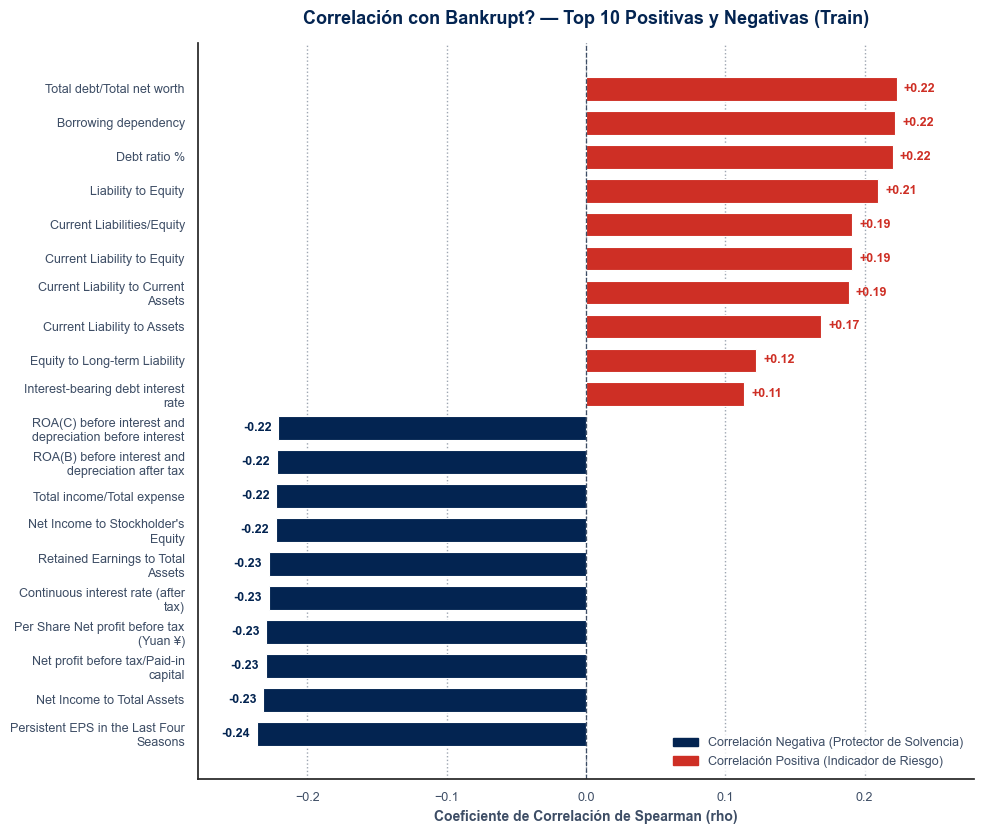

In [29]:
# 1. Cálculo de Correlaciones respecto al Target (Spearman, no Pearson)
# Se usa Spearman porque: (a) no asume normalidad de las variables -algo
# inviable de comprobar rigurosamente en 93 variables-, (b) captura relaciones
# monótonas no necesariamente lineales, y (c) es más robusto ante los outliers
# extremos ya documentados en la sección de sesgo y outliers.
corr_objetivo = (
    train_df[num_vars + [TARGET]]
    .corr(method='spearman')[TARGET]
    .drop(TARGET)
    .sort_values()
)

top_neg = corr_objetivo.head(10).reset_index()
top_neg.columns = ['Variable', 'Correlación (rho)']

top_pos = corr_objetivo.tail(10).sort_values(ascending=False).reset_index()
top_pos.columns = ['Variable', 'Correlación (rho)']

tabla_estilo(top_neg, formatos={'Correlación (rho)': '{:+.4f}'},
             titulo=f"Top 10 Correlaciones Negativas con {TARGET} (Factores Protectores)")
tabla_estilo(top_pos, formatos={'Correlación (rho)': '{:+.4f}'},
             titulo=f"Top 10 Correlaciones Positivas con {TARGET} (Factores de Riesgo)")

# 2. Generación del Gráfico Horizontal
top_corr = pd.concat([corr_objetivo.head(10), corr_objetivo.tail(10)])

etiquetas = [textwrap.fill(v, 32) for v in top_corr.index]
colores_barra = [PALETTE['downriver'] if v < 0 else PALETTE['poinciana'] for v in top_corr]

fig, ax = plt.subplots(figsize=(10, 8.5), dpi=100)
fig.patch.set_facecolor('#FFFFFF')

barras = ax.barh(etiquetas, top_corr.values, color=colores_barra, edgecolor='#FFFFFF', linewidth=0.8, height=0.7)

for barra, valor in zip(barras, top_corr.values):
    desplazamiento = 0.005 if valor >= 0 else -0.005
    ha = 'left' if valor >= 0 else 'right'
    color_texto = PALETTE['poinciana'] if valor >= 0 else PALETTE['downriver']
    ax.text(valor + desplazamiento, barra.get_y() + barra.get_height() / 2, f'{valor:+.2f}',
            va='center', ha=ha, fontsize=9, fontweight='bold', color=color_texto)

ax.axvline(0, color=PALETTE['stone_blue'], linestyle='--', linewidth=0.9)
ax.set_title(f'Correlación con {TARGET} — Top 10 Positivas y Negativas (Train)', fontsize=13,
             fontweight='bold', color=PALETTE['downriver'], pad=14)
ax.set_xlabel('Coeficiente de Correlación de Spearman (rho)', fontsize=10,
              fontweight='semibold', color=PALETTE['stone_blue'])
ax.tick_params(colors=PALETTE['stone_blue'], labelsize=9)

lim_val = max(abs(top_corr.min()), abs(top_corr.max())) * 1.18
ax.set_xlim(-lim_val, lim_val)

sns.despine(ax=ax, top=True, right=True, left=False, bottom=False)
ax.grid(axis='x', linestyle=':', alpha=0.5, color=PALETTE['stone_blue'])

leyenda = [
    mpatches.Patch(color=PALETTE['downriver'], label='Correlación Negativa (Protector de Solvencia)'),
    mpatches.Patch(color=PALETTE['poinciana'], label='Correlación Positiva (Indicador de Riesgo)'),
]
ax.legend(handles=leyenda, loc='lower right', frameon=True, facecolor='#FFFFFF', edgecolor='none',
          fontsize=9, labelcolor=PALETTE['stone_blue'])

plt.tight_layout()
plt.show()
plt.close(fig)

# 3. Variables extremas para referencia en la interpretación
var_max_pos = top_pos.iloc[0]['Variable']
r_max_pos = top_pos.iloc[0]['Correlación (rho)']
var_max_neg = top_neg.iloc[0]['Variable']
r_max_neg = top_neg.iloc[0]['Correlación (rho)']


**En palabras simples:** el gráfico confirma, con números, lo que ya insinuaba el Random Forest: **rentabilidad y endeudamiento son los dos bloques que más se relacionan con la quiebra**, pero en direcciones opuestas.

- **Correlaciones negativas (azul):** dominadas por variables de **rentabilidad** — distintas versiones de ROA, utilidad neta sobre activos/patrimonio, ganancias retenidas. La relación es negativa porque tiene sentido financiero: **a mayor rentabilidad, menor probabilidad de quiebra**. La más fuerte es `Net Income to Total Assets` (-0.32).
- **Correlaciones positivas (naranja):** dominadas por variables de **endeudamiento** — `Debt ratio %`, `Borrowing dependency`, varias razones de pasivos sobre activos o patrimonio. Aquí la relación es positiva porque **a mayor nivel de deuda relativa, mayor probabilidad de quiebra**. La más fuerte es `Debt ratio %` (0.25).

Es importante notar que **ninguna correlación individual supera 0.32 en valor absoluto**: son relaciones reales pero moderadas, no fuertes. Esto refuerza una conclusión que ya se venía formando en el EDA: ninguna variable por sí sola explica bien la quiebra, por lo que un modelo que combine varias señales (como Random Forest) probablemente capture mejor el patrón que basarse en una sola razón financiera.

También vale la pena notar que varias de las variables con correlación negativa más fuerte (las distintas versiones de ROA) son las mismas que ya se identificaron como altamente correlacionadas entre sí en la sección de multicolinealidad — otra razón para tenerlas presentes al momento de seleccionar variables para el modelo.

### 6.2 Matriz de correlación de las variables

findfont: Font family 'Segoe UI, sans-serif' not found.
findfont: Font family 'Segoe UI, sans-serif' not found.
findfont: Font family 'Segoe UI, sans-serif' not found.
findfont: Font family 'Segoe UI, sans-serif' not found.
findfont: Font family 'Segoe UI, sans-serif' not found.
findfont: Font family 'Segoe UI, sans-serif' not found.
findfont: Font family 'Segoe UI, sans-serif' not found.
findfont: Font family 'Segoe UI, sans-serif' not found.
findfont: Font family 'Segoe UI, sans-serif' not found.
findfont: Font family 'Segoe UI, sans-serif' not found.
findfont: Font family 'Segoe UI, sans-serif' not found.
findfont: Font family 'Segoe UI, sans-serif' not found.
findfont: Font family 'Segoe UI, sans-serif' not found.
findfont: Font family 'Segoe UI, sans-serif' not found.
findfont: Font family 'Segoe UI, sans-serif' not found.
findfont: Font family 'Segoe UI, sans-serif' not found.
findfont: Font family 'Segoe UI, sans-serif' not found.
findfont: Font family 'Segoe UI, sans-serif' not

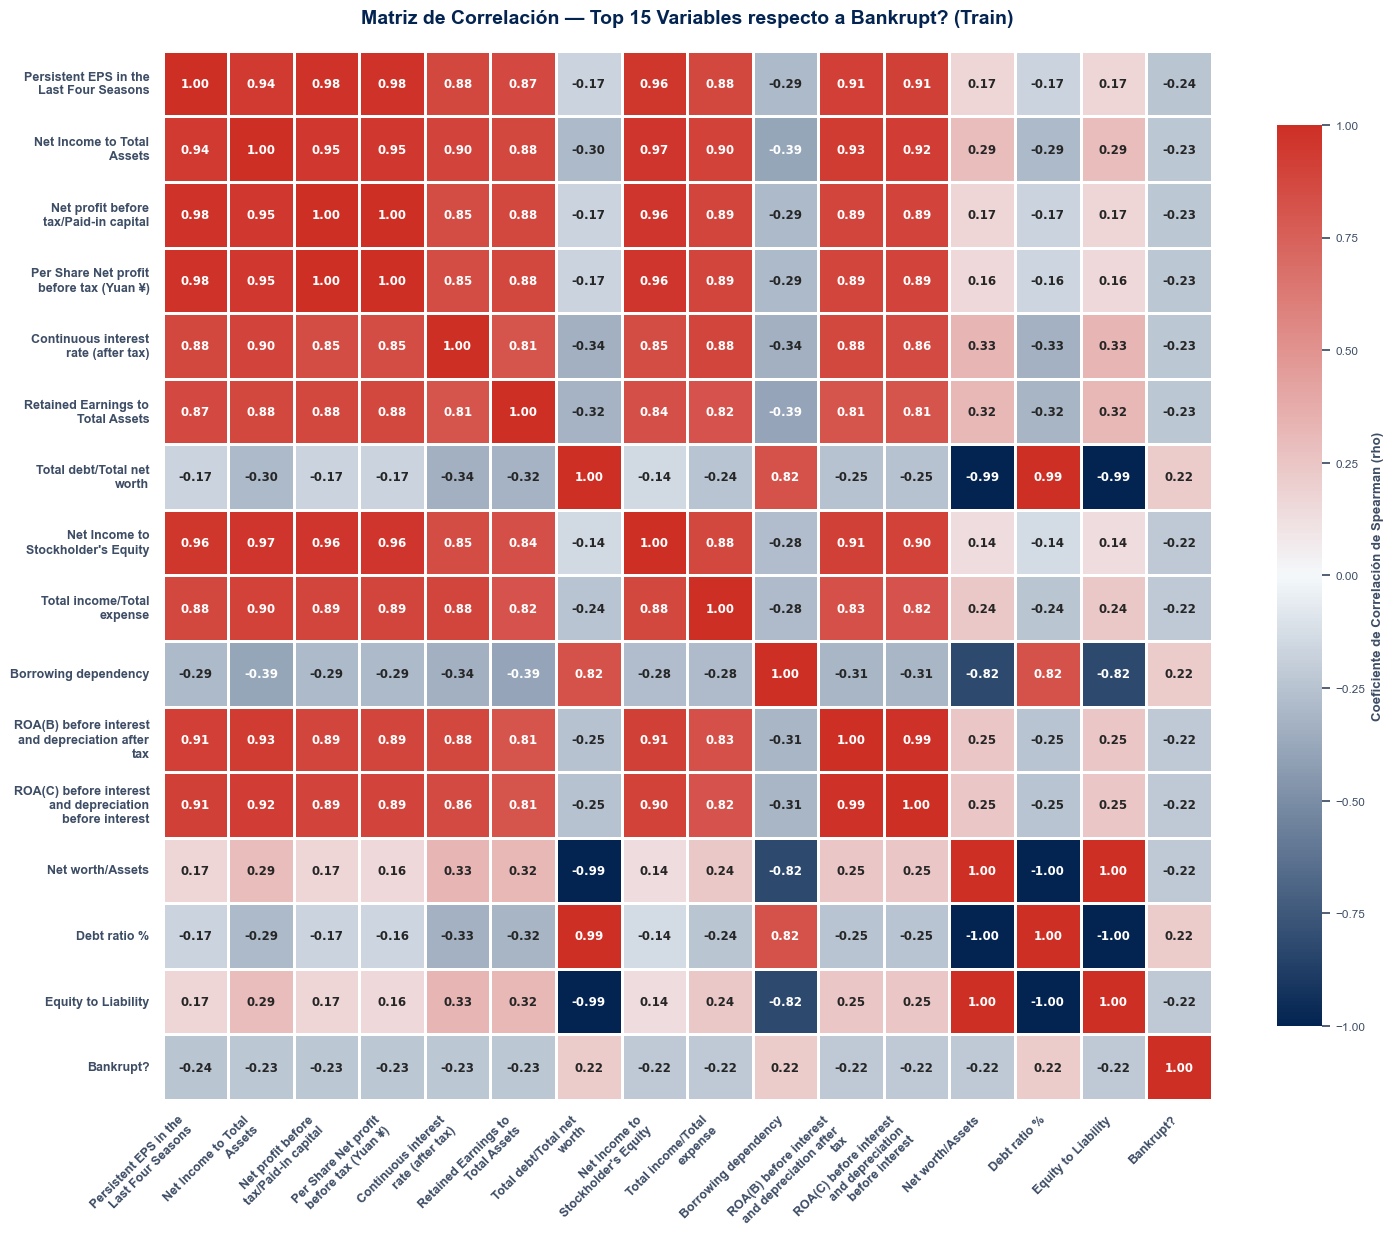

In [30]:
# 1. Seleccionar las 15 variables con mayor correlación absoluta con el objetivo
top_15_features = corr_objetivo.abs().sort_values(ascending=False).head(15).index.tolist()

corr_features = top_15_features + [TARGET]
corr_matrix = train_df[corr_features].corr(method='spearman')  # Spearman, ver justificación en 6.1

etiquetas_wrap = [textwrap.fill(c, 22) for c in corr_matrix.columns]

# 2. Generación del Heatmap
fig, ax = plt.subplots(figsize=(15, 13), dpi=100)
fig.patch.set_facecolor('#FFFFFF')

sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap=CMAP_CORR, center=0, vmin=-1.0, vmax=1.0,
    square=True, linewidths=0.8, linecolor='#FFFFFF',
    annot_kws={'size': 8.5, 'weight': 'semibold', 'fontfamily': 'Segoe UI, sans-serif'},
    cbar_kws={'shrink': 0.78, 'label': 'Coeficiente de Correlación de Spearman (rho)'},
    xticklabels=etiquetas_wrap, yticklabels=etiquetas_wrap, ax=ax,
)

ax.set_title(f'Matriz de Correlación — Top 15 Variables respecto a {TARGET} (Train)', fontsize=14,
             fontweight='bold', color=PALETTE['downriver'], pad=20)

plt.xticks(rotation=45, ha='right', fontsize=9, fontweight='semibold', color=PALETTE['stone_blue'])
plt.yticks(rotation=0, fontsize=9, fontweight='semibold', color=PALETTE['stone_blue'])

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=8.5, colors=PALETTE['stone_blue'])
cbar.set_label('Coeficiente de Correlación de Spearman (rho)', fontsize=9.5,
               fontweight='semibold', color=PALETTE['stone_blue'])

plt.tight_layout()
plt.show()
plt.close(fig)

# 3. Evaluación Dinámica de Multicolinealidad
corr_features_only = corr_matrix.drop(index=TARGET, columns=TARGET)
pairs = []

for i in range(len(corr_features_only.columns)):
    for j in range(i + 1, len(corr_features_only.columns)):
        val = corr_features_only.iloc[i, j]
        if abs(val) >= 0.80:
            pairs.append((corr_features_only.columns[i], corr_features_only.columns[j], val))

num_multicol = len(pairs)

if num_multicol > 0:
    lista_html = ''.join([
        f"<li><b>{p[0]}</b> y <b>{p[1]}</b> (<i>rho</i> = <b style='color:{PALETTE['poinciana']};'>{p[2]:+.2f}</b>)</li>"
        for p in pairs[:5]
    ])
    obs_multicol = f"""
      Se detectaron <b style="color: {PALETTE['poinciana']};">{num_multicol} pares de variables predictoras</b> con
      correlación crítica (<i>|rho| ≥ 0.80</i>). Algunos de los pares más relevantes incluyen:
      <ul style="margin: 6px 0 8px 0; color: {PALETTE['stone_blue']}; font-size: 13px; padding-left: 20px;">
          {lista_html}
      </ul>
      La presencia de alta multicolinealidad entre métricas financieras distorsiona los coeficientes en modelos
      regresivos y amplifica la varianza, por lo que se recomienda aplicar reducción de dimensionalidad (como
      <i>PCA</i>) o eliminar variables redundantes basándose en el Factor de Inflación de la Varianza (<i>VIF</i>).
    """
else:
    obs_multicol = (
        'No se detectaron pares de variables predictoras con multicolinealidad extrema (<i>|rho| ≥ 0.80</i>) '
        'dentro del Top 15 seleccionado.'
    )

tarjeta_interpretacion(
    '🧩 Diagnóstico de Multicolinealidad entre Predictoras',
    obs_multicol,
    color_borde=PALETTE['poinciana'] if num_multicol > 0 else PALETTE['downriver']
)


Esta matriz reúne en un solo lugar las 15 variables más relevantes según Random Forest, junto con `Bankrupt?`, para ver cómo se relacionan entre sí (no solo con la quiebra).

**Última fila/columna (`Bankrupt?`):** muestra correlaciones moderadas con las demás variables, consistentes con lo visto en 6.1 — ninguna supera ~0.3 en valor absoluto, lo que confirma que ninguna variable por sí sola explica la quiebra con fuerza.
**Bloques oscuros entre variables (no con el target):** aquí está lo más llamativo. Varias combinaciones de ROA, utilidad neta y ganancias retenidas muestran correlaciones muy altas entre sí (cercanas a 0.9-1.0). Esto confirma la **multicolinealidad** ya mencionada: son distintas formas de medir prácticamente lo mismo (rentabilidad), calculadas con pequeñas variaciones metodológicas.

Esto no afecta a Random Forest (que ya usamos para identificar estas variables), pero si más adelante se prueba un modelo lineal (como regresión logística), meter varias versiones casi idénticas del mismo ratio no aporta información nueva y puede inflar artificialmente la importancia de esa "familia" de variables o dificultar la interpretación de los coeficientes. Por ahora no se elimina ninguna — esa decisión se deja para la etapa de preprocesamiento, con más contexto sobre qué modelo se va a usar.


## 7. CONCLUSIONES DEL EDA

1. **Estructura del dataset:** `train` tiene 5.455 empresas y 95 variables predictoras (93 numéricas + 2 flags binarios), más el target `Bankrupt?`.

2. **Calidad de los datos:** no hay valores nulos ni filas duplicadas en `train`, lo cual facilita el modelado. `Net Income Flag` es constante (siempre vale 1) y no aporta información — candidata a eliminarse.

3. **Desbalance del target:** el problema es de clasificación binaria con un desbalance fuerte (aproximadamente 20-30 empresas sanas por cada empresa quebrada). Esto obliga a usar métricas distintas al accuracy y a considerar técnicas de balanceo en el modelado, no en el EDA.

4. **Sesgo y outliers:** varias variables financieras tienen sesgo alto y un porcentaje considerable de outliers según IQR. No parecen errores de captura, sino comportamientos extremos reales de algunas empresas, por lo que su tratamiento (transformación, winsorizing, o dejarlos igual) debe decidirse con cuidado más adelante.

5. **Variables relevantes:** según Random Forest y correlación con el target, las variables de **rentabilidad** (ROA, utilidad neta sobre patrimonio) y de **endeudamiento** son las que más distinguen a las empresas que quiebran de las que no.

6. **Multicolinealidad:** existen varias versiones muy parecidas del mismo indicador (por ejemplo, distintas formas de calcular ROA), altamente correlacionadas entre sí. No se eliminó ninguna en esta etapa, pero es algo a tener en cuenta si se usa un modelo lineal.

<!-- 7. **Separabilidad limitada en 2D:** la proyección PCA muestra que las clases no se separan claramente en dos dimensiones, lo que sugiere que un modelo capaz de capturar relaciones más complejas (por ejemplo, basado en árboles) podría funcionar mejor que un modelo lineal simple. -->
7. **`Liability-Assets Flag`:** tiene muy pocos casos con valor 1, pero ese grupo pequeño concentra una proporción de quiebra más alta. Vale la pena conservarla para el modelo pese a su baja cardinalidad.


<!-- ## Problemas identificados para la etapa de preprocesamiento -->

In [31]:
# import pickle

# with open('train_test_split.pkl', 'wb') as f:
#     pickle.dump((X_train, X_test, y_train, y_test), f)

<!-- - **`Net Income Flag`** es constante en todo el dataset: evaluar si eliminarla antes de entrenar el modelo.
- **Escalas muy distintas entre variables:** será necesario estandarizar/normalizar dentro del pipeline (ajustando el escalador solo con `train` y aplicándolo después a `test`).
- **Variables con sesgo alto y muchos outliers:** decidir si se transforman (por ejemplo, con logaritmo), se recortan (winsorizing) o se dejan igual, y documentar la razón.
- **Multicolinealidad entre variantes de ROA y otros indicadores:** considerar selección de variables o técnicas de regularización si se usa un modelo lineal.
- **Desbalance de clases (~3% quebradas):** aplicar técnicas de balanceo (por ejemplo, `class_weight='balanced'`, sobremuestreo o submuestreo) solo sobre `train`, y elegir métricas de evaluación adecuadas para clases desbalanceadas (recall, F1, AUC-PR) en lugar de accuracy.
- **`Liability-Assets Flag` con muy pocos casos positivos:** vigilar que la partición train/test (ya estratificada por el target) no deje casos demasiado escasos de este flag en algún fold si más adelante se usa validación cruzada. -->
